# Notebook 4 – Model 2: Hourly Isolation Forest Analysis

This notebook develops Model 2 using the final hourly BT dataset created in `2_Cleaning_and_Feature_Engineering` (Notebook 2).

The purpose of Model 2 is to analyse the BT data at an hourly level so that unusual network behaviour can be identified at specific times of day.

`2_Cleaning_and_Feature_Engineering` (Notebook 2) has already cleaned the hourly BT files, created the required time and location fields and added the Point of Interest (POI) information. This notebook therefore starts directly from the prepared hourly dataset:

`bt_final_hourly_model_dataset`

A separate Isolation Forest model, `model_hourly`, is trained for the hourly data.

Only suitable original BT network measurements are used to train the model. Location, coordinates, time information and POI fields are not used to decide whether an observation is anomalous. Instead, they are kept so that the anomalies can be interpreted afterwards.

The notebook:

- checks and loads all available prepared hourly data;
- selects the BT measurements used by Model 2;
- trains or reuses the hourly Isolation Forest;
- calculates an anomaly score for every hourly BT observation;
- ranks all observations from most to least anomalous;
- identifies the strongest Top 2%, Top 1% and Top 0.5% anomalies;
- explains which BT measurements contribute most to the unusual observations;
- creates Top 100, Top 1,000, Top 10,000 and Top 1% anomaly outputs;
- analyses how anomalies change by hour and date;
- identifies locations where unusual activity occurs repeatedly;
- investigates consecutive periods of anomalous hourly activity;
- uses the POI information added in `2_Cleaning_and_Feature_Engineering` (Notebook 2) to help interpret where anomalies occur;
- examines selected anomalous locations in more detail;
- compares the hourly Model 2 results with the daily results from `3_Model_1` (Notebook 3);
- and saves the model, results, figures and reusable processing resources.

The notebook is designed to reuse completed work when it is run again. If the prepared hourly data has not changed, the existing model and previously calculated results can be reused.

If additional compatible hourly BT files are added later, `2_Cleaning_and_Feature_Engineering` (Notebook 2) prepares them and `4_Model_2` (Notebook 4) automatically includes them when it is rerun.

`4_Model_2` (Notebook 4) therefore provides the hourly anomaly-detection stage of the project, allowing shorter within-day changes in BT network activity to be investigated in more detail than with the daily data alone.

# Notebook Roadmap

| Section | Cells | Purpose |
|---|---:|---|
| 1. Project Setup | 1–3 | Prepare libraries, Model-1-style folders, DuckDB working resources and the central Model 2 cache state |
| 2. Prepared Hourly Model Dataset | 4–7 | Discover, inspect, validate and finalise the complete model-ready hourly dataset produced by Notebook 2 |
| 3. Model 2 Feature Selection | 8–11 | Audit candidate measurements and identify the retained original hourly BT model features |
| 4. Hourly Training Sample | 12–16 | Configure, allocate, create, cache and validate the reproducible Model 2 training sample |
| 5. Train or Reuse `model_hourly` | 17–21 | Configure, train, validate, save or reuse the separate hourly Isolation Forest |
| 6. Score All Hourly Data | 22–26 | Score every hourly observation using reusable source-level DuckDB scoring tables |
| 7. Global Hourly Ranking | 27–31 | Create and validate one exact global anomaly ranking and reusable ranking lookup partitions |
| 8. Hourly Anomaly Groups | 32–35 | Define and validate the global Top 2%, Top 1% and Top 0.5% anomaly groups |
| 9. Hourly Explanation Framework | 36–41 | Create robust normal-reference statistics and reusable anomaly-explanation partitions |
| 10. Final Ranked Hourly Outputs | 42–46 | Build, validate, cache and summarise the complete final ranked hourly partitions while retaining Notebook 2 POI context |
| 11. Selected Hourly Anomaly Outputs | 47–51 | Create and validate the Top 100, Top 1,000, Top 10,000 and complete Top 1% Model 2 outputs |
| 12. Model 2 Visual Diagnostics | 52–56 | Examine score distributions, anomaly thresholds, global ranks, explanations and anomaly-group behaviour |
| 13. Hour-of-Day Analysis | 57–61 | Analyse hourly, daily, date × hour and available day-type patterns in Model 2 anomalies |
| 14. Hourly Location Analysis | 62–66 | Analyse strong locations, recurrence, temporal persistence, anomalous-hour streaks and persistent locations |
| 15. Hourly POI Context and Case Study | 67–70 | Interpret anomalies using retained POI context, selected location profiles and comparison with daily Model 1 |
| 16. Final Saving and Verification | 71–72 | Save final Model 2 metadata and verify the complete reproducible workflow |

# Python Package Setup

This cell checks that the Python packages required by the project are available.

Packages that are already installed are left unchanged. If a required package is missing, it is installed automatically into the Python environment used by this notebook.

This allows the notebook to run on another computer without requiring the packages to be installed manually beforehand.

In [1]:
# ================================================================
# CHECK AND INSTALL REQUIRED PYTHON PACKAGES
# ================================================================

import importlib.util
import subprocess
import sys


required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "duckdb": "duckdb",
    "geopandas": "geopandas",
    "fiona": "fiona",
    "shapely": "shapely",
    "osmnx": "osmnx",
    "pyproj": "pyproj",
    "folium": "folium",
    "IPython": "ipython"
}


print("=" * 80)
print("CHECK AND INSTALL REQUIRED PYTHON PACKAGES")
print("=" * 80)


installed_packages = []
missing_packages = []


for import_name, package_name in required_packages.items():

    if importlib.util.find_spec(import_name) is None:

        missing_packages.append(
            package_name
        )

    else:

        installed_packages.append(
            package_name
        )


print(
    f"\nPackages already available: "
    f"{len(installed_packages):,}"
)

for package_name in installed_packages:

    print(
        f"  - {package_name}"
    )


if missing_packages:

    print(
        f"\nPackages requiring installation: "
        f"{len(missing_packages):,}"
    )

    for package_name in missing_packages:

        print(
            f"  - {package_name}"
        )


    print(
        "\nInstalling missing packages..."
    )


    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            *missing_packages
        ]
    )


    print(
        "\nMissing packages were installed successfully."
    )

else:

    print(
        "\nAll required packages are already installed."
    )


print(
    "\nPython package setup complete."
)

CHECK AND INSTALL REQUIRED PYTHON PACKAGES

Packages already available: 15
  - numpy
  - pandas
  - pyarrow
  - matplotlib
  - seaborn
  - scikit-learn
  - joblib
  - duckdb
  - geopandas
  - fiona
  - shapely
  - osmnx
  - pyproj
  - folium
  - ipython

All required packages are already installed.

Python package setup complete.


# 1. Project Setup

This section prepares the packages, folders and saved resources required for Model 2.

The input to Model 2 is the final hourly BT dataset created in `2_Cleaning_and_Feature_Engineering` (Notebook 2).

The notebook also creates folders for the trained model, anomaly results, figures and reusable intermediate files.

These saved resources allow completed calculations to be reused when the notebook is run again, making future runs much faster when the hourly data has not changed.

In [2]:
# ================================================================
# CELL 1 - IMPORT REQUIRED LIBRARIES
# ================================================================

from pathlib import Path

import gc
import hashlib
import json
import os
import re
import sys
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import duckdb
import joblib

import pyarrow as pa
import pyarrow.parquet as pq

import sklearn

from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer


print("=" * 80)
print("CELL 1 - IMPORT REQUIRED LIBRARIES")
print("=" * 80)


MODEL_HOURLY_SOFTWARE_VERSIONS = pd.DataFrame(
    {
        "Library": [
            "Python",
            "NumPy",
            "pandas",
            "Matplotlib",
            "Seaborn",
            "DuckDB",
            "PyArrow",
            "scikit-learn",
            "joblib"
        ],
        "Version": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            plt.matplotlib.__version__,
            sns.__version__,
            duckdb.__version__,
            pa.__version__,
            sklearn.__version__,
            joblib.__version__
        ]
    }
)


display(
    MODEL_HOURLY_SOFTWARE_VERSIONS
)


print(
    "\nAll required Model 2 libraries "
    "were imported successfully."
)

CELL 1 - IMPORT REQUIRED LIBRARIES


,Library,Version
0,Python,3.13.5
1,NumPy,2.1.3
2,pandas,2.2.3
3,Matplotlib,3.10.0
4,Seaborn,0.13.2
5,DuckDB,1.5.5
6,PyArrow,19.0.0
7,scikit-learn,1.6.1
8,joblib,1.4.2



All required Model 2 libraries were imported successfully.


## What Cell 1 Does

This cell imports the libraries required throughout the Model 2 workflow.

The environment includes NumPy and pandas for data handling, Matplotlib and Seaborn for visualisation, DuckDB and PyArrow for efficient large-data processing and Parquet access, and scikit-learn and joblib for Isolation Forest modelling and model persistence.

The current software versions are recorded so that the established Model 2 environment can later be documented in the saved model metadata.

In [3]:
# ================================================================
# CELL 2 - DEFINE MODEL 2 PROJECT FOLDERS
# ================================================================

MODEL_2_PROJECT_FOLDER_NAME = (
    "BT_Dissertation_AL"
)


current_folder = (
    Path.cwd()
    .resolve()
)


project_candidates = [
    current_folder,
    *current_folder.parents,
    Path(
        r"C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL"
    )
]


MODEL_2_PROJECT_FOLDER = None


for candidate_folder in project_candidates:

    if (
        candidate_folder.name
        ==
        MODEL_2_PROJECT_FOLDER_NAME
    ):

        MODEL_2_PROJECT_FOLDER = (
            candidate_folder.resolve()
        )

        break


if MODEL_2_PROJECT_FOLDER is None:

    for candidate_folder in project_candidates:

        possible_project_folder = (
            candidate_folder
            /
            MODEL_2_PROJECT_FOLDER_NAME
        )

        if possible_project_folder.exists():

            MODEL_2_PROJECT_FOLDER = (
                possible_project_folder.resolve()
            )

            break


if MODEL_2_PROJECT_FOLDER is None:

    raise FileNotFoundError(
        "The BT_Dissertation_AL project folder "
        "could not be located."
    )


# ----------------------------------------------------------------
# Notebook 2 prepared hourly input
# ----------------------------------------------------------------

MODEL_HOURLY_INPUT_FOLDER = (
    MODEL_2_PROJECT_FOLDER
    /
    "data"
    /
    "cleaned_model_data"
    /
    "bt_final_hourly_model_dataset"
)


MODEL_HOURLY_INPUT_STATE_FILE = (
    MODEL_HOURLY_INPUT_FOLDER
    /
    "_final_hourly_model_state.json"
)


# ----------------------------------------------------------------
# Model 2 output structure
# ----------------------------------------------------------------

MODEL_HOURLY_FOLDER = (
    MODEL_2_PROJECT_FOLDER
    /
    "model_hourly"
)


MODEL_HOURLY_MODEL_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "model"
)


MODEL_HOURLY_TABLES_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "tables"
)


MODEL_HOURLY_FIGURES_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "figures"
)


MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "anomaly_outputs"
)


MODEL_HOURLY_RANKED_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "hourly_ranked_partitions"
)


MODEL_HOURLY_RANKING_LOOKUP_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "hourly_temporary_ranking_lookups"
)


MODEL_HOURLY_EXPLANATION_FOLDER = (
    MODEL_HOURLY_FOLDER
    /
    "hourly_temporary_explanation_partitions"
)


MODEL_HOURLY_DATABASE_FILE = (
    MODEL_HOURLY_FOLDER
    /
    "model_hourly_working.duckdb"
)


MODEL_HOURLY_CACHE_STATE_FILE = (
    MODEL_HOURLY_FOLDER
    /
    "model_hourly_cache_state.json"
)


MODEL_HOURLY_FILE = (
    MODEL_HOURLY_MODEL_FOLDER
    /
    "isolation_forest_hourly.joblib"
)


MODEL_HOURLY_METADATA_FILE = (
    MODEL_HOURLY_MODEL_FOLDER
    /
    "model_hourly_metadata.json"
)


MODEL_HOURLY_FINAL_METADATA_FILE = (
    MODEL_HOURLY_MODEL_FOLDER
    /
    "model_hourly_final_metadata.json"
)


TOP_100_HOURLY_FILE = (
    MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER
    /
    "top_100_hourly.csv"
)


TOP_1000_HOURLY_FILE = (
    MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER
    /
    "top_1000_hourly.csv"
)


TOP_10000_HOURLY_FILE = (
    MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER
    /
    "top_10000_hourly.csv"
)


TOP_1_PERCENT_HOURLY_FILE = (
    MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER
    /
    "top_1_percent_hourly.parquet"
)


MODEL_HOURLY_OUTPUT_FOLDERS = [
    MODEL_HOURLY_FOLDER,
    MODEL_HOURLY_MODEL_FOLDER,
    MODEL_HOURLY_TABLES_FOLDER,
    MODEL_HOURLY_FIGURES_FOLDER,
    MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER,
    MODEL_HOURLY_RANKED_FOLDER,
    MODEL_HOURLY_RANKING_LOOKUP_FOLDER,
    MODEL_HOURLY_EXPLANATION_FOLDER
]


for output_folder in (
    MODEL_HOURLY_OUTPUT_FOLDERS
):

    output_folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 80)
print("CELL 2 - DEFINE MODEL 2 PROJECT FOLDERS")
print("=" * 80)


model_2_folder_summary = pd.DataFrame(
    {
        "Resource": [
            "Project folder",
            "Notebook 2 hourly input",
            "Notebook 2 hourly state",
            "Model hourly folder",
            "Model folder",
            "Ranked partitions",
            "Ranking lookups",
            "Explanation partitions",
            "Anomaly outputs",
            "Tables",
            "Figures",
            "Working database",
            "Central cache"
        ],
        "Path": [
            str(
                MODEL_2_PROJECT_FOLDER
            ),
            str(
                MODEL_HOURLY_INPUT_FOLDER
            ),
            str(
                MODEL_HOURLY_INPUT_STATE_FILE
            ),
            str(
                MODEL_HOURLY_FOLDER
            ),
            str(
                MODEL_HOURLY_MODEL_FOLDER
            ),
            str(
                MODEL_HOURLY_RANKED_FOLDER
            ),
            str(
                MODEL_HOURLY_RANKING_LOOKUP_FOLDER
            ),
            str(
                MODEL_HOURLY_EXPLANATION_FOLDER
            ),
            str(
                MODEL_HOURLY_ANOMALY_OUTPUT_FOLDER
            ),
            str(
                MODEL_HOURLY_TABLES_FOLDER
            ),
            str(
                MODEL_HOURLY_FIGURES_FOLDER
            ),
            str(
                MODEL_HOURLY_DATABASE_FILE
            ),
            str(
                MODEL_HOURLY_CACHE_STATE_FILE
            )
        ]
    }
)


display(
    model_2_folder_summary
)


assert MODEL_2_PROJECT_FOLDER.exists()

assert MODEL_HOURLY_INPUT_FOLDER.exists()

assert MODEL_HOURLY_INPUT_STATE_FILE.exists()


print(
    "\nModel 2 now points directly to the "
    "prepared hourly dataset produced by Notebook 2."
)

CELL 2 - DEFINE MODEL 2 PROJECT FOLDERS


,Resource,Path
0,Project folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,Notebook 2 hourly input,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,Notebook 2 hourly state,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,Model hourly folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
4,Model folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
5,Ranked partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
6,Ranking lookups,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
7,Explanation partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
8,Anomaly outputs,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
9,Tables,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



Model 2 now points directly to the prepared hourly dataset produced by Notebook 2.


## What Cell 2 Does

This cell defines the revised Model 2 folder structure.

The direct Model 2 input is now `data/cleaned_model_data/bt_final_hourly_model_dataset`, which is produced and verified by Notebook 2.

The existing Model 2 model, DuckDB, ranked-partition, anomaly-output, table, figure, ranking-lookup and explanation locations are retained so that the established downstream workflow can continue using reusable resources.

The Notebook 2 hourly state file is also recorded because it contains information describing the current prepared dataset, original hourly source state and dynamic POI structure.

In [4]:
# ================================================================
# CELL 3 - DEFINE GENERAL MODEL 2 SETTINGS AND HELPERS
# ================================================================

MODEL_HOURLY_RANDOM_STATE = (
    42
)


MODEL_HOURLY_FIGURE_DPI = (
    300
)


MODEL_HOURLY_DUCKDB_THREADS = max(
    1,
    min(
        4,
        (
            os.cpu_count()
            if os.cpu_count() is not None
            else 1
        )
    )
)


MODEL_HOURLY_DUCKDB_MEMORY_LIMIT = (
    "8GB"
)


MODEL_HOURLY_PARQUET_GLOB = (
    "*_final_hourly_model.parquet"
)


MODEL_HOURLY_LOCATION_COLUMN = (
    "location_id"
)


MODEL_HOURLY_X_COLUMN = (
    "xbin"
)


MODEL_HOURLY_Y_COLUMN = (
    "ybin"
)


MODEL_HOURLY_DATE_COLUMN = (
    "en_dt"
)


MODEL_HOURLY_TIME_COLUMN = (
    "time_interval"
)


MODEL_HOURLY_DATETIME_COLUMN = (
    "hourly_datetime"
)


MODEL_HOURLY_HOUR_COLUMN = (
    "hour"
)


MODEL_HOURLY_DERIVED_CONTEXT_COLUMNS = [
    MODEL_HOURLY_LOCATION_COLUMN,
    MODEL_HOURLY_DATETIME_COLUMN,
    MODEL_HOURLY_HOUR_COLUMN
]


def model_hourly_json_fingerprint(
    value
):
    """
    Return a deterministic SHA-256 fingerprint
    for a JSON-serialisable object.
    """

    serialised_value = json.dumps(
        value,
        sort_keys=True,
        separators=(
            ",",
            ":"
        ),
        default=str
    )

    return hashlib.sha256(
        serialised_value.encode(
            "utf-8"
        )
    ).hexdigest()


def model_hourly_file_signature(
    file_path
):
    """
    Return a lightweight deterministic file signature.
    """

    file_path = Path(
        file_path
    ).resolve()

    file_stat = file_path.stat()

    signature_definition = {
        "name": file_path.name,
        "size": int(
            file_stat.st_size
        ),
        "modified_ns": int(
            file_stat.st_mtime_ns
        )
    }

    return model_hourly_json_fingerprint(
        signature_definition
    )


def model_hourly_sql_path(
    file_path
):
    """
    Return a safely escaped absolute path
    for use inside DuckDB SQL.
    """

    return (
        Path(
            file_path
        )
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


def model_hourly_quote_identifier(
    column_name
):
    """
    Safely quote a DuckDB identifier.
    """

    return (
        '"'
        +
        str(
            column_name
        ).replace(
            '"',
            '""'
        )
        +
        '"'
    )


def model_hourly_partition_stem(
    file_path
):
    """
    Return a stable source-partition stem.
    """

    stem = Path(
        file_path
    ).stem

    final_suffix = (
        "_final_hourly_model"
    )

    if stem.endswith(
        final_suffix
    ):

        stem = stem[
            :-len(
                final_suffix
            )
        ]

    return stem


# ----------------------------------------------------------------
# Persistent cache state
# ----------------------------------------------------------------

if MODEL_HOURLY_CACHE_STATE_FILE.exists():

    try:

        with MODEL_HOURLY_CACHE_STATE_FILE.open(
            "r",
            encoding="utf-8"
        ) as cache_handle:

            MODEL_HOURLY_CACHE_STATE = (
                json.load(
                    cache_handle
                )
            )

    except Exception:

        MODEL_HOURLY_CACHE_STATE = {}


else:

    MODEL_HOURLY_CACHE_STATE = {}


def model_hourly_save_cache_state():
    """
    Save the current central Model 2 cache state.
    """

    temporary_cache_file = (
        MODEL_HOURLY_CACHE_STATE_FILE
        .with_suffix(
            ".temporary.json"
        )
    )


    with temporary_cache_file.open(
        "w",
        encoding="utf-8"
    ) as cache_handle:

        json.dump(
            MODEL_HOURLY_CACHE_STATE,
            cache_handle,
            indent=4,
            default=str
        )


    temporary_cache_file.replace(
        MODEL_HOURLY_CACHE_STATE_FILE
    )


# ----------------------------------------------------------------
# Persistent DuckDB connection
# ----------------------------------------------------------------

MODEL_HOURLY_CONNECTION = duckdb.connect(
    str(
        MODEL_HOURLY_DATABASE_FILE
    )
)


MODEL_HOURLY_CONNECTION.execute(
    f"""
    SET threads = {
        MODEL_HOURLY_DUCKDB_THREADS
    }
    """
)


MODEL_HOURLY_CONNECTION.execute(
    f"""
    SET memory_limit = '
        {MODEL_HOURLY_DUCKDB_MEMORY_LIMIT}
    '
    """
)


def model_hourly_duckdb_table_exists(
    table_name
):
    """
    Return True when a DuckDB table exists.
    """

    result = (
        MODEL_HOURLY_CONNECTION.execute(
            """
            SELECT COUNT(*)

            FROM information_schema.tables

            WHERE
                table_name = ?
            """,
            [
                table_name
            ]
        )
        .fetchone()
    )

    return (
        int(
            result[
                0
            ]
        )
        >
        0
    )

def model_hourly_drop_duckdb_table(
    table_name
):
    """
    Drop a DuckDB table when it exists.
    """

    safe_table_name = str(
        table_name
    ).replace(
        '"',
        '""'
    )


    MODEL_HOURLY_CONNECTION.execute(
        f"""
        DROP TABLE IF EXISTS
            "{safe_table_name}"
        """
    )
    
print("=" * 80)
print(
    "CELL 3 - DEFINE GENERAL MODEL 2 "
    "SETTINGS AND HELPERS"
)
print("=" * 80)


model_2_general_settings = pd.DataFrame(
    {
        "Setting": [
            "Random state",
            "DuckDB threads",
            "DuckDB memory limit",
            "Figure DPI",
            "Input file pattern",
            "Working database",
            "Cache state",
            "Model file"
        ],
        "Value": [
            MODEL_HOURLY_RANDOM_STATE,
            MODEL_HOURLY_DUCKDB_THREADS,
            MODEL_HOURLY_DUCKDB_MEMORY_LIMIT,
            MODEL_HOURLY_FIGURE_DPI,
            MODEL_HOURLY_PARQUET_GLOB,
            str(
                MODEL_HOURLY_DATABASE_FILE
            ),
            str(
                MODEL_HOURLY_CACHE_STATE_FILE
            ),
            str(
                MODEL_HOURLY_FILE
            )
        ]
    }
)


display(
    model_2_general_settings
)


print(
    f"\nExisting cache sections: "
    f"{len(MODEL_HOURLY_CACHE_STATE):,}"
)


print(
    "\nThe persistent Model 2 environment "
    "is ready."
)

CELL 3 - DEFINE GENERAL MODEL 2 SETTINGS AND HELPERS


,Setting,Value
0,Random state,42
1,DuckDB threads,4
2,DuckDB memory limit,8GB
3,Figure DPI,300
4,Input file pattern,*_final_hourly_model.parquet
5,Working database,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
6,Cache state,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
7,Model file,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



Existing cache sections: 0

The persistent Model 2 environment is ready.


## What Cell 3 Does

This cell defines the general Model 2 settings and reusable helper functions.

The random seed, DuckDB resource settings and expected Notebook 2 hourly filename pattern are established.

Stable helpers are defined for JSON fingerprints, file signatures, SQL-safe file paths, quoted column names and partition names.

The existing central Model 2 cache state is loaded when available.

A persistent DuckDB connection to `model_hourly_working.duckdb` is then opened so that training, scoring, global ranking and normal-reference resources can continue to be reused across notebook runs.

These settings belong to Model 2 itself and therefore remain in Notebook 4 even though raw-data preparation has moved to Notebook 2.

# 2. Prepared Hourly Model Dataset

This section loads and validates the final hourly model-ready Parquet partitions created by Notebook 2.

Notebook 4 does not repeat the raw-file discovery or cleaning operations already completed upstream.

The prepared dataset contains the cleaned original hourly BT fields, derived temporal and location fields and the current POI context.

Only the original BT network measurements will later be eligible for Isolation Forest training.

In [5]:
# ================================================================
# CELL 4 - DISCOVER NOTEBOOK 2 HOURLY MODEL PARTITIONS
# ================================================================

discovered_hourly_files = sorted(
    [
        file_path.resolve()
        for file_path
        in MODEL_HOURLY_INPUT_FOLDER.glob(
            MODEL_HOURLY_PARQUET_GLOB
        )
        if file_path.is_file()
    ],
    key=lambda file_path: (
        file_path.name.lower()
    )
)


HOURLY_SOURCE_FILE_COUNT = len(
    discovered_hourly_files
)


if HOURLY_SOURCE_FILE_COUNT == 0:

    raise FileNotFoundError(
        "No final hourly model-ready Parquet "
        "partitions were found in "
        f"{MODEL_HOURLY_INPUT_FOLDER}."
    )


with MODEL_HOURLY_INPUT_STATE_FILE.open(
    "r",
    encoding="utf-8"
) as state_handle:

    MODEL_HOURLY_NOTEBOOK_2_STATE = (
        json.load(
            state_handle
        )
    )


MODEL_HOURLY_NOTEBOOK_2_SOURCE_SIGNATURES = (
    MODEL_HOURLY_NOTEBOOK_2_STATE.get(
        "source_signatures",
        {}
    )
)


MODEL_HOURLY_NOTEBOOK_2_POI_COLUMNS = list(
    MODEL_HOURLY_NOTEBOOK_2_STATE.get(
        "poi_feature_columns",
        []
    )
)


MODEL_HOURLY_NOTEBOOK_2_FINAL_COLUMNS = list(
    MODEL_HOURLY_NOTEBOOK_2_STATE.get(
        "final_columns",
        []
    )
)


MODEL_HOURLY_NOTEBOOK_2_TOTAL_ROWS = (
    MODEL_HOURLY_NOTEBOOK_2_STATE.get(
        "total_rows"
    )
)


def model_hourly_original_source_name(
    prepared_file
):
    """
    Match one prepared Notebook 2 output
    to the original hourly source filename.
    """

    partition_stem = (
        model_hourly_partition_stem(
            prepared_file
        )
    )


    matches = [
        source_name
        for source_name
        in MODEL_HOURLY_NOTEBOOK_2_SOURCE_SIGNATURES
        if Path(
            source_name
        ).stem
        ==
        partition_stem
    ]


    if len(
        matches
    ) == 1:

        return matches[
            0
        ]


    return None


hourly_prepared_file_records = []


for file_number, file_path in enumerate(
    discovered_hourly_files,
    start=1
):

    original_source_name = (
        model_hourly_original_source_name(
            file_path
        )
    )


    hourly_prepared_file_records.append(
        {
            "File Number": (
                file_number
            ),
            "Prepared File": (
                file_path.name
            ),
            "Original Source File": (
                original_source_name
            ),
            "Size (MB)": round(
                file_path.stat().st_size
                /
                (1024 ** 2),
                3
            ),
            "Prepared Path": str(
                file_path
            )
        }
    )


model_hourly_prepared_files = pd.DataFrame(
    hourly_prepared_file_records
)


print("=" * 80)
print(
    "CELL 4 - DISCOVER NOTEBOOK 2 "
    "HOURLY MODEL PARTITIONS"
)
print("=" * 80)


print(
    f"\nPrepared hourly partitions discovered: "
    f"{HOURLY_SOURCE_FILE_COUNT:,}"
)


display(
    model_hourly_prepared_files
)


assert HOURLY_SOURCE_FILE_COUNT > 0


assert (
    model_hourly_prepared_files[
        "Size (MB)"
    ]
    >
    0
).all()


print(
    "\nEvery current Notebook 2 hourly "
    "model-ready partition was discovered."
)

CELL 4 - DISCOVER NOTEBOOK 2 HOURLY MODEL PARTITIONS

Prepared hourly partitions discovered: 4


,File Number,Prepared File,Original Source File,Size (MB),Prepared Path
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,1172.360,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,1141.649,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,1034.451,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,1227.197,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



Every current Notebook 2 hourly model-ready partition was discovered.


## What Cell 4 Does

This cell dynamically discovers every final hourly model-ready Parquet partition currently produced by Notebook 2.

No fixed number of partitions is assumed.

If additional compatible hourly source files are supplied in the future, Notebook 2 creates their final model-ready outputs and they automatically enter this list when Notebook 4 is rerun.

The Notebook 2 hourly state file is also loaded. It records the original source-file signatures, final column structure and dynamic POI fields associated with the prepared dataset.

Where possible, each final partition is linked back to the original hourly source filename that produced it.

In [6]:
# ================================================================
# CELL 5 - INSPECT AND CLASSIFY THE PREPARED HOURLY SCHEMA
# ================================================================

hourly_prepared_schema_records = []


for file_number, file_path in enumerate(
    discovered_hourly_files,
    start=1
):

    parquet_file = pq.ParquetFile(
        file_path
    )


    file_columns = list(
        parquet_file
        .schema_arrow
        .names
    )


    hourly_prepared_schema_records.append(
        {
            "File Number": (
                file_number
            ),
            "Filename": (
                file_path.name
            ),
            "Observations": int(
                parquet_file
                .metadata
                .num_rows
            ),
            "Columns": int(
                parquet_file
                .metadata
                .num_columns
            ),
            "Column Names": (
                file_columns
            )
        }
    )


model_hourly_prepared_schema = pd.DataFrame(
    hourly_prepared_schema_records
)


MODEL_HOURLY_REFERENCE_FINAL_COLUMNS = list(
    model_hourly_prepared_schema.loc[
        0,
        "Column Names"
    ]
)


if (
    len(
        MODEL_HOURLY_NOTEBOOK_2_FINAL_COLUMNS
    )
    >
    0
):

    assert (
        MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
        ==
        MODEL_HOURLY_NOTEBOOK_2_FINAL_COLUMNS
    )


MODEL_HOURLY_POI_FEATURE_COLUMNS = [
    column_name
    for column_name
    in MODEL_HOURLY_NOTEBOOK_2_POI_COLUMNS
    if column_name
    in MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
]


MODEL_HOURLY_POI_FEATURE_COUNT = len(
    MODEL_HOURLY_POI_FEATURE_COLUMNS
)


MODEL_HOURLY_PREPARED_CONTEXT_COLUMNS = [
    MODEL_HOURLY_LOCATION_COLUMN,
    MODEL_HOURLY_DATETIME_COLUMN,
    MODEL_HOURLY_HOUR_COLUMN
]


# Original cleaned hourly BT columns only:
# 34 source fields, excluding the 3 derived context
# fields and all POI context.

MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS = [
    column_name
    for column_name
    in MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
    if (
        column_name
        not in MODEL_HOURLY_POI_FEATURE_COLUMNS
        and
        column_name
        not in MODEL_HOURLY_PREPARED_CONTEXT_COLUMNS
    )
]


common_source_column_set = set(
    MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS
)


for file_columns in (
    model_hourly_prepared_schema[
        "Column Names"
    ]
):

    common_source_column_set &= set(
        [
            column_name
            for column_name
            in file_columns
            if (
                column_name
                not in MODEL_HOURLY_POI_FEATURE_COLUMNS
                and
                column_name
                not in MODEL_HOURLY_PREPARED_CONTEXT_COLUMNS
            )
        ]
    )


MODEL_HOURLY_COMMON_CLEAN_COLUMNS = [
    column_name
    for column_name
    in MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS
    if column_name
    in common_source_column_set
]


MODEL_HOURLY_REQUIRED_STRUCTURAL_COLUMNS = [
    MODEL_HOURLY_TIME_COLUMN,
    MODEL_HOURLY_X_COLUMN,
    MODEL_HOURLY_Y_COLUMN,
    MODEL_HOURLY_DATE_COLUMN,
    MODEL_HOURLY_LOCATION_COLUMN,
    MODEL_HOURLY_DATETIME_COLUMN,
    MODEL_HOURLY_HOUR_COLUMN
]


missing_required_hourly_columns = [
    column_name
    for column_name
    in MODEL_HOURLY_REQUIRED_STRUCTURAL_COLUMNS
    if column_name
    not in MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
]


hourly_schema_comparison = pd.DataFrame(
    {
        "File Number": (
            model_hourly_prepared_schema[
                "File Number"
            ]
        ),
        "Filename": (
            model_hourly_prepared_schema[
                "Filename"
            ]
        ),
        "Rows": (
            model_hourly_prepared_schema[
                "Observations"
            ]
        ),
        "Columns": (
            model_hourly_prepared_schema[
                "Columns"
            ]
        ),
        "Matches Reference Schema": [
            file_columns
            ==
            MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
            for file_columns
            in model_hourly_prepared_schema[
                "Column Names"
            ]
        ]
    }
)


print("=" * 80)
print(
    "CELL 5 - INSPECT AND CLASSIFY "
    "THE PREPARED HOURLY SCHEMA"
)
print("=" * 80)


display(
    hourly_schema_comparison
)


prepared_schema_summary = pd.DataFrame(
    {
        "Column Group": [
            "Final Notebook 2 columns",
            "Original hourly BT source columns",
            "Derived context columns",
            "POI context columns",
            "Common original source columns"
        ],
        "Count": [
            len(
                MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
            ),
            len(
                MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS
            ),
            len(
                MODEL_HOURLY_PREPARED_CONTEXT_COLUMNS
            ),
            MODEL_HOURLY_POI_FEATURE_COUNT,
            len(
                MODEL_HOURLY_COMMON_CLEAN_COLUMNS
            )
        ]
    }
)


print(
    "\nPrepared hourly column classification:"
)


display(
    prepared_schema_summary
)


assert len(
    missing_required_hourly_columns
) == 0


assert (
    hourly_schema_comparison[
        "Matches Reference Schema"
    ]
).all()


assert (
    MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS
    ==
    MODEL_HOURLY_COMMON_CLEAN_COLUMNS
)


assert MODEL_HOURLY_POI_FEATURE_COUNT > 0


print(
    "\nAll prepared hourly partitions use "
    "one consistent model-ready schema."
)

CELL 5 - INSPECT AND CLASSIFY THE PREPARED HOURLY SCHEMA


,File Number,Filename,Rows,Columns,Matches Reference Schema
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,65,True
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,65,True
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,65,True
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,65,True



Prepared hourly column classification:


,Column Group,Count
0,Final Notebook 2 columns,65
1,Original hourly BT source columns,34
2,Derived context columns,3
3,POI context columns,28
4,Common original source columns,34



All prepared hourly partitions use one consistent model-ready schema.


## What Cell 5 Does

This cell inspects the actual schema of every Notebook 2 hourly model-ready partition.

All partitions must have the same final column order and structure.

The columns are then separated into three conceptual groups.

The original hourly BT source fields remain available for Model 2 feature selection.

The three derived fields `location_id`, `hourly_datetime` and `hour` are contextual variables and are excluded from Isolation Forest training.

All dynamically supplied Notebook 2 POI fields are also identified separately and excluded from model training.

This preserves the original Model 2 methodology while allowing Notebook 4 to consume the fully enriched model-ready dataset produced dynamically by Notebook 2.

In [7]:
# ================================================================
# CELL 6 - VALIDATE EVERY PREPARED HOURLY PARTITION
# ================================================================

hourly_prepared_validation_records = []


for file_number, file_path in enumerate(
    discovered_hourly_files,
    start=1
):

    safe_file_path = (
        model_hourly_sql_path(
            file_path
        )
    )


    validation_result = (
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT_IF(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_LOCATION_COLUMN
                    )}
                    IS NULL
                )
                AS missing_location_ids,

                COUNT_IF(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_X_COLUMN
                    )}
                    IS NULL
                )
                AS missing_x,

                COUNT_IF(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_Y_COLUMN
                    )}
                    IS NULL
                )
                AS missing_y,

                COUNT_IF(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_DATE_COLUMN
                    )}
                    IS NULL
                )
                AS missing_dates,

                COUNT_IF(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_DATETIME_COLUMN
                    )}
                    IS NULL
                )
                AS missing_datetimes,

                COUNT_IF(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_HOUR_COLUMN
                    )}
                    IS NULL
                    OR
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_HOUR_COLUMN
                    )}
                    < 0
                    OR
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_HOUR_COLUMN
                    )}
                    > 23
                )
                AS invalid_hours,

                COUNT(
                    DISTINCT
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_DATE_COLUMN
                    )}
                )
                AS unique_dates,

                COUNT(
                    DISTINCT
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_HOUR_COLUMN
                    )}
                )
                AS unique_hours,

                MIN(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_DATE_COLUMN
                    )}
                )
                AS minimum_date,

                MAX(
                    {model_hourly_quote_identifier(
                        MODEL_HOURLY_DATE_COLUMN
                    )}
                )
                AS maximum_date

            FROM read_parquet(
                '{safe_file_path}'
            )
            """
        )
        .df()
    )


    observations = int(
        validation_result.loc[
            0,
            "observations"
        ]
    )


    expected_columns = list(
        pq.read_schema(
            file_path
        ).names
    )


    valid_schema = (
        expected_columns
        ==
        MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
    )


    valid = (
        observations
        >
        0
        and
        valid_schema
        and
        int(
            validation_result.loc[
                0,
                "missing_location_ids"
            ]
        )
        ==
        0
        and
        int(
            validation_result.loc[
                0,
                "missing_x"
            ]
        )
        ==
        0
        and
        int(
            validation_result.loc[
                0,
                "missing_y"
            ]
        )
        ==
        0
        and
        int(
            validation_result.loc[
                0,
                "missing_dates"
            ]
        )
        ==
        0
        and
        int(
            validation_result.loc[
                0,
                "missing_datetimes"
            ]
        )
        ==
        0
        and
        int(
            validation_result.loc[
                0,
                "invalid_hours"
            ]
        )
        ==
        0
    )


    hourly_prepared_validation_records.append(
        {
            "File Number": (
                file_number
            ),
            "Filename": (
                file_path.name
            ),
            "Observations": (
                observations
            ),
            "Columns": len(
                expected_columns
            ),
            "Unique Dates": int(
                validation_result.loc[
                    0,
                    "unique_dates"
                ]
            ),
            "Unique Hours": int(
                validation_result.loc[
                    0,
                    "unique_hours"
                ]
            ),
            "Minimum Date": (
                validation_result.loc[
                    0,
                    "minimum_date"
                ]
            ),
            "Maximum Date": (
                validation_result.loc[
                    0,
                    "maximum_date"
                ]
            ),
            "Missing Location IDs": int(
                validation_result.loc[
                    0,
                    "missing_location_ids"
                ]
            ),
            "Missing X": int(
                validation_result.loc[
                    0,
                    "missing_x"
                ]
            ),
            "Missing Y": int(
                validation_result.loc[
                    0,
                    "missing_y"
                ]
            ),
            "Missing Dates": int(
                validation_result.loc[
                    0,
                    "missing_dates"
                ]
            ),
            "Missing Datetimes": int(
                validation_result.loc[
                    0,
                    "missing_datetimes"
                ]
            ),
            "Invalid Hours": int(
                validation_result.loc[
                    0,
                    "invalid_hours"
                ]
            ),
            "Valid Schema": (
                valid_schema
            ),
            "Valid": (
                valid
            )
        }
    )


model_hourly_prepared_validation = pd.DataFrame(
    hourly_prepared_validation_records
)


hourly_row_counts = (
    model_hourly_prepared_validation[
        [
            "File Number",
            "Filename",
            "Observations"
        ]
    ]
    .copy()
)


MODEL_HOURLY_TOTAL_ROWS = int(
    hourly_row_counts[
        "Observations"
    ].sum()
)


MODEL_HOURLY_MINIMUM_DATE = (
    model_hourly_prepared_validation[
        "Minimum Date"
    ].min()
)


MODEL_HOURLY_MAXIMUM_DATE = (
    model_hourly_prepared_validation[
        "Maximum Date"
    ].max()
)


print("=" * 80)
print(
    "CELL 6 - VALIDATE EVERY "
    "PREPARED HOURLY PARTITION"
)
print("=" * 80)


display(
    model_hourly_prepared_validation
)


print(
    f"\nPrepared partitions : "
    f"{HOURLY_SOURCE_FILE_COUNT:,}"
)


print(
    f"Total observations  : "
    f"{MODEL_HOURLY_TOTAL_ROWS:,}"
)


print(
    f"Overall date range   : "
    f"{MODEL_HOURLY_MINIMUM_DATE} "
    f"to "
    f"{MODEL_HOURLY_MAXIMUM_DATE}"
)


assert (
    model_hourly_prepared_validation[
        "Valid"
    ]
).all()


assert MODEL_HOURLY_TOTAL_ROWS > 0


if (
    MODEL_HOURLY_NOTEBOOK_2_TOTAL_ROWS
    is not None
):

    assert MODEL_HOURLY_TOTAL_ROWS == int(
        MODEL_HOURLY_NOTEBOOK_2_TOTAL_ROWS
    )


print(
    "\nEvery prepared hourly partition "
    "passed Model 2 input validation."
)

CELL 6 - VALIDATE EVERY PREPARED HOURLY PARTITION


,File Number,Filename,Observations,Columns,Unique Dates,Unique Hours,Minimum Date,Maximum Date,Missing Location IDs,Missing X,Missing Y,Missing Dates,Missing Datetimes,Invalid Hours,Valid Schema,Valid
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,65,1,24,2026-07-14,2026-07-14,0,0,0,0,0,0,True,True
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,65,1,24,2026-07-15,2026-07-15,0,0,0,0,0,0,True,True
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,65,1,24,2026-07-16,2026-07-16,0,0,0,0,0,0,True,True
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,65,1,24,2026-07-17,2026-07-17,0,0,0,0,0,0,True,True



Prepared partitions : 4
Total observations  : 19,128,803
Overall date range   : 2026-07-14 00:00:00 to 2026-07-17 00:00:00

Every prepared hourly partition passed Model 2 input validation.


## What Cell 6 Does

This cell validates every complete hourly model-ready partition supplied by Notebook 2.

Each partition must contain observations, use the common final schema and retain valid BT grid coordinates, location identifiers, dates, combined hourly timestamps and hour-of-day values.

The complete row population and date coverage are recalculated independently rather than simply trusting the Notebook 2 state file.

The recalculated observation count must agree with the population recorded by Notebook 2.

The resulting `hourly_row_counts` table is retained because later Model 2 training and scoring stages use the number of observations in each partition.

In [8]:
# ================================================================
# CELL 7 - FINALISE THE CURRENT MODEL 2 INPUT STATE
# ================================================================

MODEL_HOURLY_SOURCE_COLUMNS = list(
    MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS
)


model_hourly_source_select_sql = ",\n".join(
    [
        model_hourly_quote_identifier(
            column_name
        )
        for column_name
        in MODEL_HOURLY_SOURCE_COLUMNS
    ]
)


model_hourly_source_union_parts = []


for file_path in (
    discovered_hourly_files
):

    safe_file_path = (
        model_hourly_sql_path(
            file_path
        )
    )


    model_hourly_source_union_parts.append(
        f"""
        SELECT
            {model_hourly_source_select_sql}

        FROM read_parquet(
            '{safe_file_path}'
        )
        """
    )


MODEL_HOURLY_SOURCE_UNION_SQL = (
    "\nUNION ALL BY NAME\n".join(
        model_hourly_source_union_parts
    )
)


model_hourly_input_partition_records = []


for file_path in (
    discovered_hourly_files
):

    prepared_filename = (
        file_path.name
    )


    original_source_name = (
        model_hourly_original_source_name(
            file_path
        )
    )


    expected_rows = int(
        hourly_row_counts.loc[
            hourly_row_counts[
                "Filename"
            ]
            ==
            prepared_filename,
            "Observations"
        ].iloc[
            0
        ]
    )


    if (
        original_source_name
        is not None
        and
        original_source_name
        in MODEL_HOURLY_NOTEBOOK_2_SOURCE_SIGNATURES
    ):

        original_source_signature = (
            MODEL_HOURLY_NOTEBOOK_2_SOURCE_SIGNATURES[
                original_source_name
            ]
        )


    else:

        original_source_signature = (
            model_hourly_file_signature(
                file_path
            )
        )


    model_hourly_input_partition_records.append(
        {
            "prepared_file": (
                prepared_filename
            ),
            "original_source_file": (
                original_source_name
            ),
            "original_source_signature": (
                original_source_signature
            ),
            "observations": (
                expected_rows
            )
        }
    )


MODEL_HOURLY_DATA_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "version": (
                "prepared_hourly_bt_v1"
            ),
            "source_columns": (
                MODEL_HOURLY_SOURCE_COLUMNS
            ),
            "partitions": (
                model_hourly_input_partition_records
            )
        }
    )
)


MODEL_HOURLY_PREPARED_DATA_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "version": (
                "prepared_hourly_final_v1"
            ),
            "final_columns": (
                MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
            ),
            "poi_columns": (
                MODEL_HOURLY_POI_FEATURE_COLUMNS
            ),
            "prepared_files": [
                {
                    "filename": (
                        file_path.name
                    ),
                    "signature": (
                        model_hourly_file_signature(
                            file_path
                        )
                    )
                }
                for file_path
                in discovered_hourly_files
            ]
        }
    )
)


MODEL_HOURLY_CACHE_STATE[
    "prepared_hourly_input"
] = {
    "version": (
        "1"
    ),
    "folder": str(
        MODEL_HOURLY_INPUT_FOLDER
    ),
    "partition_count": (
        HOURLY_SOURCE_FILE_COUNT
    ),
    "observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "source_column_count": len(
        MODEL_HOURLY_SOURCE_COLUMNS
    ),
    "final_column_count": len(
        MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
    ),
    "poi_feature_count": (
        MODEL_HOURLY_POI_FEATURE_COUNT
    ),
    "model_data_fingerprint": (
        MODEL_HOURLY_DATA_FINGERPRINT
    ),
    "prepared_data_fingerprint": (
        MODEL_HOURLY_PREPARED_DATA_FINGERPRINT
    ),
    "partitions": (
        model_hourly_input_partition_records
    )
}


model_hourly_save_cache_state()


model_hourly_input_summary = pd.DataFrame(
    {
        "Measure": [
            "Prepared hourly partitions",
            "Hourly observations",
            "Original BT source columns",
            "Derived context fields",
            "POI context fields",
            "Final prepared columns",
            "Earliest date",
            "Latest date",
            "Model-data fingerprint",
            "Prepared-data fingerprint"
        ],
        "Value": [
            HOURLY_SOURCE_FILE_COUNT,
            MODEL_HOURLY_TOTAL_ROWS,
            len(
                MODEL_HOURLY_SOURCE_COLUMNS
            ),
            len(
                MODEL_HOURLY_PREPARED_CONTEXT_COLUMNS
            ),
            MODEL_HOURLY_POI_FEATURE_COUNT,
            len(
                MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
            ),
            MODEL_HOURLY_MINIMUM_DATE,
            MODEL_HOURLY_MAXIMUM_DATE,
            MODEL_HOURLY_DATA_FINGERPRINT,
            MODEL_HOURLY_PREPARED_DATA_FINGERPRINT
        ]
    }
)


print("=" * 80)
print(
    "CELL 7 - FINALISE THE CURRENT "
    "MODEL 2 INPUT STATE"
)
print("=" * 80)


display(
    model_hourly_input_summary
)


assert len(
    MODEL_HOURLY_SOURCE_COLUMNS
) > 0


assert len(
    model_hourly_source_union_parts
) == HOURLY_SOURCE_FILE_COUNT


assert MODEL_HOURLY_CACHE_STATE_FILE.exists()


print(
    "\nSection 2 is complete. The current "
    "Notebook 2 hourly dataset is ready "
    "for independent Model 2 feature selection."
)

CELL 7 - FINALISE THE CURRENT MODEL 2 INPUT STATE


,Measure,Value
0,Prepared hourly partitions,4
1,Hourly observations,19128803
2,Original BT source columns,34
3,Derived context fields,3
4,POI context fields,28
5,Final prepared columns,65
6,Earliest date,2026-07-14 00:00:00
7,Latest date,2026-07-17 00:00:00
8,Model-data fingerprint,e9b66551be5520f2f33b0874502fc84def3edf4cc3f534...
9,Prepared-data fingerprint,482042d7321de42e2bb2bee2b74ee93c189aae208a55f7...



Section 2 is complete. The current Notebook 2 hourly dataset is ready for independent Model 2 feature selection.


## What Cell 7 Does

This cell finalises the prepared hourly dataset state used by the remainder of Model 2.

A DuckDB union is created across the current Notebook 2 hourly partitions using only the original cleaned BT source columns. Derived location/time fields and POI context are therefore prevented from entering the feature-audit population accidentally.

Two fingerprints are recorded.

The model-data fingerprint represents the original BT observation population and source-column structure relevant to Isolation Forest modelling.

The prepared-data fingerprint additionally represents the complete Notebook 2 model-ready partitions, including their dynamic contextual fields.

Keeping these concepts separate is useful because a change to POI context should not, by itself, redefine the BT measurements used by the Isolation Forest.

The central Model 2 cache records the current number of partitions, observations, source fields, POI fields and fingerprints.

At this point Notebook 4 has a validated prepared hourly input and can proceed directly to Model 2 feature selection.

# 3. Model 2 Feature Selection

This section identifies the original hourly BT measurement fields that are suitable for training `model_hourly`.

Location coordinates, dates, time variables and later POI information are excluded from model training.

Feature suitability is assessed from the hourly dataset itself rather than copying the final Model 1 feature list.

The resulting feature structure therefore remains reproducible while still allowing the notebook to respond correctly if future hourly source files change the available data.

In [9]:
# ================================================================
# CELL 8 - CLASSIFY HOURLY DATASET COLUMNS
# ================================================================

MODEL_HOURLY_SOURCE_COLUMNS = [
    column_name
    for column_name
    in MODEL_HOURLY_REFERENCE_CLEAN_COLUMNS
    if column_name
    in set(
        MODEL_HOURLY_COMMON_CLEAN_COLUMNS
    )
]


MODEL_HOURLY_STRUCTURAL_COLUMNS = [
    MODEL_HOURLY_TIME_COLUMN,
    MODEL_HOURLY_X_COLUMN,
    MODEL_HOURLY_Y_COLUMN,
    MODEL_HOURLY_DATE_COLUMN
]


MODEL_HOURLY_MEASUREMENT_COLUMNS = [
    column_name
    for column_name
    in MODEL_HOURLY_SOURCE_COLUMNS
    if column_name
    not in MODEL_HOURLY_STRUCTURAL_COLUMNS
]


MODEL_HOURLY_LOCATION_COLUMN = (
    "location_id"
)


MODEL_HOURLY_DATETIME_COLUMN = (
    "hourly_datetime"
)


MODEL_HOURLY_HOUR_COLUMN = (
    "hour"
)


MODEL_HOURLY_CONTEXT_COLUMNS = [
    MODEL_HOURLY_LOCATION_COLUMN,
    MODEL_HOURLY_X_COLUMN,
    MODEL_HOURLY_Y_COLUMN,
    MODEL_HOURLY_DATE_COLUMN,
    MODEL_HOURLY_TIME_COLUMN,
    MODEL_HOURLY_DATETIME_COLUMN,
    MODEL_HOURLY_HOUR_COLUMN
]


MODEL_HOURLY_CANDIDATE_FEATURES = list(
    MODEL_HOURLY_MEASUREMENT_COLUMNS
)


model_hourly_column_classification = pd.DataFrame(
    {
        "Column Group": [
            "Common hourly source columns",
            "Structural source columns",
            "Candidate BT measurements",
            "Derived context columns"
        ],
        "Count": [
            len(
                MODEL_HOURLY_SOURCE_COLUMNS
            ),
            len(
                MODEL_HOURLY_STRUCTURAL_COLUMNS
            ),
            len(
                MODEL_HOURLY_CANDIDATE_FEATURES
            ),
            3
        ]
    }
)


print("=" * 80)
print("CELL 8 - CLASSIFY HOURLY DATASET COLUMNS")
print("=" * 80)


display(
    model_hourly_column_classification
)


print(
    "\nCandidate hourly BT measurements:"
)


display(
    pd.DataFrame(
        {
            "Feature Number": range(
                1,
                len(
                    MODEL_HOURLY_CANDIDATE_FEATURES
                )
                +
                1
            ),
            "Candidate Feature": (
                MODEL_HOURLY_CANDIDATE_FEATURES
            )
        }
    )
)


assert len(
    MODEL_HOURLY_CANDIDATE_FEATURES
) > 0


assert not set(
    MODEL_HOURLY_CANDIDATE_FEATURES
).intersection(
    MODEL_HOURLY_STRUCTURAL_COLUMNS
)


print(
    "\nThe hourly source columns were "
    "classified successfully."
)

CELL 8 - CLASSIFY HOURLY DATASET COLUMNS


,Column Group,Count
0,Common hourly source columns,34
1,Structural source columns,4
2,Candidate BT measurements,30
3,Derived context columns,3



Candidate hourly BT measurements:


,Feature Number,Candidate Feature
0,1,averagedownlinkthroughput
1,2,averageuplinkthroughput
2,3,csfallbackattempts
3,4,irathandoverattempts
4,5,linearaveragersrp
5,6,linearaveragersrq
6,7,minutesofuse
7,8,numberofconnections
8,9,pedestrianminutesofuse
9,10,s1handoverattempts



The hourly source columns were classified successfully.


## What Cell 8 Does

This cell separates the hourly source fields into structural variables and candidate BT measurements.

The four structural fields describe location and time and are excluded from Isolation Forest training.

Three additional context fields — `location_id`, `hourly_datetime` and `hour` — will be derived later for interpretation and are also excluded from modelling.

Every remaining common source field becomes a candidate original BT measurement.

No POI field is included at this stage.

In [10]:
# ================================================================
# CELL 9 - CREATE OR REUSE THE HOURLY FEATURE AUDIT
# ================================================================

MODEL_HOURLY_FEATURE_AUDIT_FILE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_feature_audit.csv"
)


MODEL_HOURLY_FEATURE_AUDIT_VERSION = (
    "2_missing_tokens_fixed"
)


MODEL_HOURLY_FEATURE_AUDIT_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "audit_version": (
                MODEL_HOURLY_FEATURE_AUDIT_VERSION
            ),
            "data_fingerprint": (
                MODEL_HOURLY_DATA_FINGERPRINT
            ),
            "candidate_features": (
                MODEL_HOURLY_CANDIDATE_FEATURES
            )
        }
    )
)


cached_feature_audit_state = (
    MODEL_HOURLY_CACHE_STATE.get(
        "feature_audit",
        {}
    )
)


reuse_feature_audit = (
    MODEL_HOURLY_FEATURE_AUDIT_FILE.exists()
    and
    cached_feature_audit_state.get(
        "fingerprint"
    )
    ==
    MODEL_HOURLY_FEATURE_AUDIT_FINGERPRINT
)


if reuse_feature_audit:

    model_hourly_feature_audit = (
        pd.read_csv(
            MODEL_HOURLY_FEATURE_AUDIT_FILE
        )
    )


    feature_audit_action = (
        "Reused"
    )


else:

    feature_audit_sql_parts = []


    for feature_number, feature_name in enumerate(
        MODEL_HOURLY_CANDIDATE_FEATURES,
        start=1
    ):

        quoted_feature = (
            model_hourly_quote_identifier(
                feature_name
            )
        )


        numeric_expression = (
            f"TRY_CAST({quoted_feature} AS DOUBLE)"
        )


        text_expression = (
            f"LOWER("
            f"TRIM("
            f"CAST({quoted_feature} AS VARCHAR)"
            f")"
            f")"
        )


        valid_expression = (
            f"{numeric_expression} IS NOT NULL "
            f"AND isfinite({numeric_expression})"
        )


        missing_token_expression = (
            f"{quoted_feature} IS NULL "
            f"OR {text_expression} IN ("
            f"'', "
            f"'nan', "
            f"'null', "
            f"'none', "
            f"'na', "
            f"'n/a', "
            f"'nat'"
            f")"
        )


        non_numeric_expression = (
            f"NOT ({missing_token_expression}) "
            f"AND NOT ({valid_expression})"
        )


        feature_audit_sql_parts.extend(
            [
                (
                    f"COUNT_IF("
                    f"{valid_expression}"
                    f") "
                    f"AS valid_{feature_number}"
                ),
                (
                    f"COUNT_IF("
                    f"{non_numeric_expression}"
                    f") "
                    f"AS non_numeric_{feature_number}"
                ),
                (
                    f"COUNT_IF("
                    f"{valid_expression} "
                    f"AND {numeric_expression} = 0"
                    f") "
                    f"AS zero_{feature_number}"
                ),
                (
                    f"approx_count_distinct("
                    f"CASE "
                    f"WHEN {valid_expression} "
                    f"THEN {numeric_expression} "
                    f"END"
                    f") "
                    f"AS unique_{feature_number}"
                ),
                (
                    f"STDDEV_POP("
                    f"CASE "
                    f"WHEN {valid_expression} "
                    f"THEN {numeric_expression} "
                    f"END"
                    f") "
                    f"AS std_{feature_number}"
                ),
                (
                    f"MIN("
                    f"CASE "
                    f"WHEN {valid_expression} "
                    f"THEN {numeric_expression} "
                    f"END"
                    f") "
                    f"AS min_{feature_number}"
                ),
                (
                    f"MAX("
                    f"CASE "
                    f"WHEN {valid_expression} "
                    f"THEN {numeric_expression} "
                    f"END"
                    f") "
                    f"AS max_{feature_number}"
                )
            ]
        )


    feature_audit_sql = (
        ",\n            ".join(
            feature_audit_sql_parts
        )
    )


    feature_audit_result = (
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS total_observations,

                {feature_audit_sql}

            FROM (
                {MODEL_HOURLY_SOURCE_UNION_SQL}
            )
            """
        )
        .df()
    )


    total_audit_rows = int(
        feature_audit_result.loc[
            0,
            "total_observations"
        ]
    )


    feature_audit_records = []


    for feature_number, feature_name in enumerate(
        MODEL_HOURLY_CANDIDATE_FEATURES,
        start=1
    ):

        valid_value_raw = (
            feature_audit_result.loc[
                0,
                f"valid_{feature_number}"
            ]
        )


        non_numeric_value_raw = (
            feature_audit_result.loc[
                0,
                f"non_numeric_{feature_number}"
            ]
        )


        zero_value_raw = (
            feature_audit_result.loc[
                0,
                f"zero_{feature_number}"
            ]
        )


        unique_value_raw = (
            feature_audit_result.loc[
                0,
                f"unique_{feature_number}"
            ]
        )


        valid_values = (
            0
            if pd.isna(
                valid_value_raw
            )
            else int(
                valid_value_raw
            )
        )


        non_numeric_values = (
            0
            if pd.isna(
                non_numeric_value_raw
            )
            else int(
                non_numeric_value_raw
            )
        )


        zero_values = (
            0
            if pd.isna(
                zero_value_raw
            )
            else int(
                zero_value_raw
            )
        )


        unique_values = (
            0
            if pd.isna(
                unique_value_raw
            )
            else int(
                unique_value_raw
            )
        )


        missing_values = (
            total_audit_rows
            -
            valid_values
            -
            non_numeric_values
        )


        feature_audit_records.append(
            {
                "Feature": (
                    feature_name
                ),
                "Total Observations": (
                    total_audit_rows
                ),
                "Finite": (
                    valid_values
                ),
                "Missing": (
                    missing_values
                ),
                "Missing (%)": (
                    missing_values
                    /
                    total_audit_rows
                    *
                    100.0
                ),
                "Non-Numeric": (
                    non_numeric_values
                ),
                "Non-Numeric (%)": (
                    non_numeric_values
                    /
                    total_audit_rows
                    *
                    100.0
                ),
                "Zero": (
                    zero_values
                ),
                "Zero (%)": (
                    zero_values
                    /
                    total_audit_rows
                    *
                    100.0
                ),
                "Approx Unique": (
                    unique_values
                ),
                "Std Dev": (
                    feature_audit_result.loc[
                        0,
                        f"std_{feature_number}"
                    ]
                ),
                "Minimum": (
                    feature_audit_result.loc[
                        0,
                        f"min_{feature_number}"
                    ]
                ),
                "Maximum": (
                    feature_audit_result.loc[
                        0,
                        f"max_{feature_number}"
                    ]
                )
            }
        )


    model_hourly_feature_audit = pd.DataFrame(
        feature_audit_records
    )


    model_hourly_feature_audit.to_csv(
        MODEL_HOURLY_FEATURE_AUDIT_FILE,
        index=False
    )


    MODEL_HOURLY_CACHE_STATE[
        "feature_audit"
    ] = {
        "audit_version": (
            MODEL_HOURLY_FEATURE_AUDIT_VERSION
        ),
        "fingerprint": (
            MODEL_HOURLY_FEATURE_AUDIT_FINGERPRINT
        ),
        "file": str(
            MODEL_HOURLY_FEATURE_AUDIT_FILE
        ),
        "features": (
            MODEL_HOURLY_CANDIDATE_FEATURES
        )
    }


    model_hourly_save_cache_state()


    feature_audit_action = (
        "Created"
    )


print("=" * 80)
print(
    "CELL 9 - CREATE OR REUSE "
    "THE HOURLY FEATURE AUDIT"
)
print("=" * 80)


print(
    f"\nFeature audit action: "
    f"{feature_audit_action}"
)


display(
    model_hourly_feature_audit
)


assert len(
    model_hourly_feature_audit
) == len(
    MODEL_HOURLY_CANDIDATE_FEATURES
)


assert (
    model_hourly_feature_audit[
        "Total Observations"
    ]
    ==
    MODEL_HOURLY_TOTAL_ROWS
).all()


assert (
    model_hourly_feature_audit[
        "Missing"
    ]
    >=
    0
).all()


assert (
    model_hourly_feature_audit[
        "Finite"
    ]
    +
    model_hourly_feature_audit[
        "Missing"
    ]
    +
    model_hourly_feature_audit[
        "Non-Numeric"
    ]
    ==
    MODEL_HOURLY_TOTAL_ROWS
).all()


assert MODEL_HOURLY_FEATURE_AUDIT_FILE.exists()


print(
    "\nThe complete hourly candidate-feature "
    "audit is available."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 9 - CREATE OR REUSE THE HOURLY FEATURE AUDIT

Feature audit action: Created


,Feature,Total Observations,Finite,Missing,Missing (%),Non-Numeric,Non-Numeric (%),Zero,Zero (%),Approx Unique,Std Dev,Minimum,Maximum
0,averagedownlinkthroughput,19128803,16528858,2599945,13.591781,0,0.0,2150932,11.244467,666523,914.523921,0.0,39469.53
1,averageuplinkthroughput,19128803,15756659,3372144,17.628620,0,0.0,2571802,13.444657,161996,165.225552,0.0,13712.36
2,csfallbackattempts,19128803,19128803,0,0.000000,0,0.0,19095816,99.827553,20,0.060129,0.0,23.00
3,irathandoverattempts,19128803,0,19128803,100.000000,0,0.0,0,0.000000,0,NaN,NaN,NaN
4,linearaveragersrp,19128803,15963307,3165496,16.548322,0,0.0,0,0.000000,7241,11.306455,-140.0,-44.00
5,linearaveragersrq,19128803,15963306,3165497,16.548328,0,0.0,0,0.000000,1581,2.905226,-19.5,-3.00
6,minutesofuse,19128803,19128803,0,0.000000,0,0.0,862598,4.509420,15978,9.060381,0.0,933.23
7,numberofconnections,19128803,19128803,0,0.000000,0,0.0,0,0.000000,1239,21.405680,1.0,3447.00
8,pedestrianminutesofuse,19128803,19128803,0,0.000000,0,0.0,16161382,84.487158,2896,0.965662,0.0,112.23
9,s1handoverattempts,19128803,19128803,0,0.000000,0,0.0,18862654,98.608648,490,4.050544,0.0,6310.00



The complete hourly candidate-feature audit is available.


## What Cell 9 Does

This cell creates a complete quality audit for every candidate hourly BT measurement.

For each candidate it measures numeric coverage, missingness, unexpected non-numeric values, zero frequency, approximate uniqueness, standard deviation and observed range.

The audit is based on the complete current hourly population rather than only a small sample.

Because this calculation requires scanning the source data, its result is cached. If the source-data fingerprint and candidate feature structure are unchanged on a future run, the saved audit is reused instead of being recalculated.

If new hourly files are added, the source-data fingerprint changes and the audit is rebuilt automatically.

In [11]:
# ================================================================
# CELL 10 - ASSESS MODEL 2 FEATURE ELIGIBILITY
# ================================================================

MODEL_HOURLY_MAX_FEATURE_MISSING_PERCENT = (
    95.0
)


model_hourly_feature_eligibility = (
    model_hourly_feature_audit
    .copy()
)


model_hourly_feature_eligibility[
    "Has Numeric Data"
] = (
    model_hourly_feature_eligibility[
        "Finite"
    ]
    >
    0
)


model_hourly_feature_eligibility[
    "Has Variation"
] = (
    model_hourly_feature_eligibility[
        "Approx Unique"
    ]
    >
    1
) & (
    model_hourly_feature_eligibility[
        "Std Dev"
    ]
    .fillna(
        0
    )
    >
    0
)


model_hourly_feature_eligibility[
    "No Parsing Problems"
] = (
    model_hourly_feature_eligibility[
        "Non-Numeric"
    ]
    ==
    0
)


model_hourly_feature_eligibility[
    "High Missingness"
] = (
    model_hourly_feature_eligibility[
        "Missing (%)"
    ]
    >=
    MODEL_HOURLY_MAX_FEATURE_MISSING_PERCENT
)


model_hourly_feature_eligibility[
    "Preliminary Eligible"
] = (
    model_hourly_feature_eligibility[
        "Has Numeric Data"
    ]
    &
    model_hourly_feature_eligibility[
        "Has Variation"
    ]
    &
    model_hourly_feature_eligibility[
        "No Parsing Problems"
    ]
    &
    (
        ~model_hourly_feature_eligibility[
            "High Missingness"
        ]
    )
)


MODEL_HOURLY_PRELIMINARY_FEATURES = (
    model_hourly_feature_eligibility.loc[
        model_hourly_feature_eligibility[
            "Preliminary Eligible"
        ],
        "Feature"
    ]
    .tolist()
)


MODEL_HOURLY_PRELIMINARY_EXCLUDED = (
    model_hourly_feature_eligibility.loc[
        ~model_hourly_feature_eligibility[
            "Preliminary Eligible"
        ],
        "Feature"
    ]
    .tolist()
)


print("=" * 80)
print(
    "CELL 10 - ASSESS MODEL 2 "
    "FEATURE ELIGIBILITY"
)
print("=" * 80)


display(
    model_hourly_feature_eligibility[
        [
            "Feature",
            "Missing (%)",
            "Non-Numeric",
            "Zero (%)",
            "Approx Unique",
            "Std Dev",
            "Has Numeric Data",
            "Has Variation",
            "High Missingness",
            "Preliminary Eligible"
        ]
    ]
)


print(
    f"\nCandidate measurements       : "
    f"{len(MODEL_HOURLY_CANDIDATE_FEATURES):,}"
)


print(
    f"Preliminary eligible features: "
    f"{len(MODEL_HOURLY_PRELIMINARY_FEATURES):,}"
)


print(
    f"Preliminary excluded features: "
    f"{len(MODEL_HOURLY_PRELIMINARY_EXCLUDED):,}"
)


if len(
    MODEL_HOURLY_PRELIMINARY_EXCLUDED
) > 0:

    print(
        "\nFeatures requiring exclusion:"
    )


    display(
        model_hourly_feature_eligibility.loc[
            ~model_hourly_feature_eligibility[
                "Preliminary Eligible"
            ],
            [
                "Feature",
                "Missing (%)",
                "Non-Numeric",
                "Approx Unique",
                "Std Dev",
                "Has Numeric Data",
                "Has Variation",
                "High Missingness"
            ]
        ]
        .reset_index(
            drop=True
        )
    )


assert len(
    MODEL_HOURLY_PRELIMINARY_FEATURES
) > 0


assert (
    len(
        MODEL_HOURLY_PRELIMINARY_FEATURES
    )
    +
    len(
        MODEL_HOURLY_PRELIMINARY_EXCLUDED
    )
) == len(
    MODEL_HOURLY_CANDIDATE_FEATURES
)


print(
    "\nPreliminary Model 2 feature "
    "eligibility was assessed successfully."
)

CELL 10 - ASSESS MODEL 2 FEATURE ELIGIBILITY


,Feature,Missing (%),Non-Numeric,Zero (%),Approx Unique,Std Dev,Has Numeric Data,Has Variation,High Missingness,Preliminary Eligible
0,averagedownlinkthroughput,13.591781,0,11.244467,666523,914.523921,True,True,False,True
1,averageuplinkthroughput,17.628620,0,13.444657,161996,165.225552,True,True,False,True
2,csfallbackattempts,0.000000,0,99.827553,20,0.060129,True,True,False,True
3,irathandoverattempts,100.000000,0,0.000000,0,NaN,False,False,True,False
4,linearaveragersrp,16.548322,0,0.000000,7241,11.306455,True,True,False,True
5,linearaveragersrq,16.548328,0,0.000000,1581,2.905226,True,True,False,True
6,minutesofuse,0.000000,0,4.509420,15978,9.060381,True,True,False,True
7,numberofconnections,0.000000,0,0.000000,1239,21.405680,True,True,False,True
8,pedestrianminutesofuse,0.000000,0,84.487158,2896,0.965662,True,True,False,True
9,s1handoverattempts,0.000000,0,98.608648,490,4.050544,True,True,False,True



Candidate measurements       : 30
Preliminary eligible features: 28
Preliminary excluded features: 2

Features requiring exclusion:


,Feature,Missing (%),Non-Numeric,Approx Unique,Std Dev,Has Numeric Data,Has Variation,High Missingness
0,irathandoverattempts,100.0,0,0,NaN,False,False,True
1,totalconnectionblocks,0.0,0,1,0.0,True,False,False



Preliminary Model 2 feature eligibility was assessed successfully.


## What Cell 10 Does

This cell applies the Model 2 feature-quality rules to the complete hourly feature audit.

A candidate measurement is retained provisionally when it contains finite numeric information, has meaningful variation, contains no unexpected parsing problems and is not at least 95% missing.

The decision is based on the current hourly dataset itself.

The current successful Model 2 data is expected to retain 28 of the 30 candidate BT measurements, but this number is not hard-coded. If future hourly data genuinely changes feature suitability, the result will update automatically.

In [12]:
# ================================================================
# CELL 11 - FINALISE MODEL 2 TRAINING FEATURES
# ================================================================

MODEL_HOURLY_FEATURES = list(
    MODEL_HOURLY_PRELIMINARY_FEATURES
)


MODEL_HOURLY_EXCLUDED_FEATURES = list(
    MODEL_HOURLY_PRELIMINARY_EXCLUDED
)


MODEL_HOURLY_FEATURE_COUNT = len(
    MODEL_HOURLY_FEATURES
)


MODEL_HOURLY_FEATURE_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "features": (
                MODEL_HOURLY_FEATURES
            ),
            "excluded_features": (
                MODEL_HOURLY_EXCLUDED_FEATURES
            ),
            "eligibility_missing_threshold": (
                MODEL_HOURLY_MAX_FEATURE_MISSING_PERCENT
            )
        }
    )
)


model_hourly_feature_eligibility[
    "Final Role"
] = np.where(
    model_hourly_feature_eligibility[
        "Feature"
    ].isin(
        MODEL_HOURLY_FEATURES
    ),
    "Model 2 training feature",
    "Excluded"
)


print("=" * 80)
print(
    "CELL 11 - FINALISE MODEL 2 "
    "TRAINING FEATURES"
)
print("=" * 80)


print(
    f"\nFinal Model 2 training features: "
    f"{MODEL_HOURLY_FEATURE_COUNT:,}"
)


print(
    f"Excluded measurement fields: "
    f"{len(MODEL_HOURLY_EXCLUDED_FEATURES):,}"
)


display(
    model_hourly_feature_eligibility[
        [
            "Feature",
            "Missing (%)",
            "Zero (%)",
            "Approx Unique",
            "Std Dev",
            "Preliminary Eligible",
            "Final Role"
        ]
    ]
)


print(
    "\nFinal retained features:"
)


display(
    pd.DataFrame(
        {
            "Feature Number": range(
                1,
                MODEL_HOURLY_FEATURE_COUNT
                +
                1
            ),
            "Model 2 Training Feature": (
                MODEL_HOURLY_FEATURES
            )
        }
    )
)


assert MODEL_HOURLY_FEATURE_COUNT > 0


assert len(
    set(
        MODEL_HOURLY_FEATURES
    )
) == MODEL_HOURLY_FEATURE_COUNT


assert not set(
    MODEL_HOURLY_FEATURES
).intersection(
    MODEL_HOURLY_CONTEXT_COLUMNS
)


assert not set(
    MODEL_HOURLY_FEATURES
).intersection(
    MODEL_HOURLY_STRUCTURAL_COLUMNS
)


MODEL_HOURLY_CACHE_STATE[
    "feature_selection"
] = {
    "feature_fingerprint": (
        MODEL_HOURLY_FEATURE_FINGERPRINT
    ),
    "feature_count": (
        MODEL_HOURLY_FEATURE_COUNT
    ),
    "features": (
        MODEL_HOURLY_FEATURES
    ),
    "excluded_features": (
        MODEL_HOURLY_EXCLUDED_FEATURES
    )
}


model_hourly_save_cache_state()


print(
    "\nSection 3 is complete. The final "
    "Model 2 feature set was defined successfully."
)

CELL 11 - FINALISE MODEL 2 TRAINING FEATURES

Final Model 2 training features: 28
Excluded measurement fields: 2


,Feature,Missing (%),Zero (%),Approx Unique,Std Dev,Preliminary Eligible,Final Role
0,averagedownlinkthroughput,13.591781,11.244467,666523,914.523921,True,Model 2 training feature
1,averageuplinkthroughput,17.628620,13.444657,161996,165.225552,True,Model 2 training feature
2,csfallbackattempts,0.000000,99.827553,20,0.060129,True,Model 2 training feature
3,irathandoverattempts,100.000000,0.000000,0,NaN,False,Excluded
4,linearaveragersrp,16.548322,0.000000,7241,11.306455,True,Model 2 training feature
5,linearaveragersrq,16.548328,0.000000,1581,2.905226,True,Model 2 training feature
6,minutesofuse,0.000000,4.509420,15978,9.060381,True,Model 2 training feature
7,numberofconnections,0.000000,0.000000,1239,21.405680,True,Model 2 training feature
8,pedestrianminutesofuse,0.000000,84.487158,2896,0.965662,True,Model 2 training feature
9,s1handoverattempts,0.000000,98.608648,490,4.050544,True,Model 2 training feature



Final retained features:


,Feature Number,Model 2 Training Feature
0,1,averagedownlinkthroughput
1,2,averageuplinkthroughput
2,3,csfallbackattempts
3,4,linearaveragersrp
4,5,linearaveragersrq
5,6,minutesofuse
6,7,numberofconnections
7,8,pedestrianminutesofuse
8,9,s1handoverattempts
9,10,s1handoverfailures



Section 3 is complete. The final Model 2 feature set was defined successfully.


## What Cell 11 Does

This cell finalises the BT measurements used to train `model_hourly`.

The retained measurements become the official Model 2 Isolation Forest feature set, while unsuitable measurement fields remain explicitly recorded as excluded.

A feature fingerprint is created and stored in the central cache.

This is important for future runs: additional hourly files do not automatically force a different model. If the established feature structure remains compatible, the existing fitted Isolation Forest can later be reused and only new or changed hourly files need scoring.

Location, time and POI information remain completely outside model training.

Section 3 is complete.

# 4. Hourly Training Sample

This section prepares the reproducible sample used to establish `model_hourly`.

The complete hourly population is too large to fit directly as one in-memory training matrix, so a maximum of one million observations is selected proportionally from the available source files.

The training sample is a model-establishment resource.

Once a valid fitted `model_hourly` exists, future compatible hourly files can be scored using the established model without automatically retraining it.

In [13]:
# ================================================================
# CELL 12 - CONFIGURE THE HOURLY TRAINING SAMPLE
# ================================================================

MODEL_HOURLY_TRAINING_SAMPLE_TARGET = (
    1_000_000
)


MODEL_HOURLY_TRAINING_SAMPLE_ROWS = min(
    MODEL_HOURLY_TRAINING_SAMPLE_TARGET,
    MODEL_HOURLY_TOTAL_ROWS
)


MODEL_HOURLY_TRAINING_SAMPLE_TABLE = (
    "model_hourly_training_sample"
)


MODEL_HOURLY_TRAINING_SAMPLE_RANDOM_STATE = (
    MODEL_HOURLY_RANDOM_STATE
)


MODEL_HOURLY_OVERWRITE_TRAINING_SAMPLE = (
    False
)


MODEL_HOURLY_TRAINING_CONFIGURATION = {
    "target_rows": (
        MODEL_HOURLY_TRAINING_SAMPLE_TARGET
    ),
    "actual_target_rows": (
        MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    ),
    "random_state": (
        MODEL_HOURLY_TRAINING_SAMPLE_RANDOM_STATE
    ),
    "feature_fingerprint": (
        MODEL_HOURLY_FEATURE_FINGERPRINT
    ),
    "feature_count": (
        MODEL_HOURLY_FEATURE_COUNT
    ),
    "features": (
        MODEL_HOURLY_FEATURES
    )
}


MODEL_HOURLY_TRAINING_CONFIGURATION_FINGERPRINT = (
    model_hourly_json_fingerprint(
        MODEL_HOURLY_TRAINING_CONFIGURATION
    )
)


model_hourly_training_settings = pd.DataFrame(
    {
        "Setting": [
            "Complete hourly observations",
            "Training sample target",
            "Actual target rows",
            "Training features",
            "Random state",
            "DuckDB training table",
            "Overwrite existing sample"
        ],
        "Value": [
            MODEL_HOURLY_TOTAL_ROWS,
            MODEL_HOURLY_TRAINING_SAMPLE_TARGET,
            MODEL_HOURLY_TRAINING_SAMPLE_ROWS,
            MODEL_HOURLY_FEATURE_COUNT,
            MODEL_HOURLY_TRAINING_SAMPLE_RANDOM_STATE,
            MODEL_HOURLY_TRAINING_SAMPLE_TABLE,
            MODEL_HOURLY_OVERWRITE_TRAINING_SAMPLE
        ]
    }
)


print("=" * 80)
print(
    "CELL 12 - CONFIGURE THE "
    "HOURLY TRAINING SAMPLE"
)
print("=" * 80)


display(
    model_hourly_training_settings
)


assert (
    0
    <
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    <=
    MODEL_HOURLY_TOTAL_ROWS
)


assert MODEL_HOURLY_FEATURE_COUNT > 0


print(
    "\nThe hourly training-sample settings "
    "were defined successfully."
)

CELL 12 - CONFIGURE THE HOURLY TRAINING SAMPLE


,Setting,Value
0,Complete hourly observations,19128803
1,Training sample target,1000000
2,Actual target rows,1000000
3,Training features,28
4,Random state,42
5,DuckDB training table,model_hourly_training_sample
6,Overwrite existing sample,False



The hourly training-sample settings were defined successfully.


## What Cell 12 Does

This cell configures the reproducible Model 2 training sample.

A maximum of one million hourly observations is selected from the complete available population.

The reusable training sample is stored as a table inside `model_hourly_working.duckdb` rather than as another permanent file inside the `model` folder.

The fitted model itself therefore remains separate from large processing resources.

In [14]:
# ================================================================
# CELL 13 - ALLOCATE THE HOURLY TRAINING SAMPLE
# ================================================================

model_hourly_training_allocation = (
    hourly_row_counts
    .copy()
)


model_hourly_training_allocation[
    "Exact Allocation"
] = (
    model_hourly_training_allocation[
        "Observations"
    ]
    /
    MODEL_HOURLY_TOTAL_ROWS
    *
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
)


model_hourly_training_allocation[
    "Allocated Rows"
] = np.floor(
    model_hourly_training_allocation[
        "Exact Allocation"
    ]
).astype(
    int
)


model_hourly_training_allocation[
    "Remainder"
] = (
    model_hourly_training_allocation[
        "Exact Allocation"
    ]
    -
    model_hourly_training_allocation[
        "Allocated Rows"
    ]
)


remaining_training_rows = (
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    -
    int(
        model_hourly_training_allocation[
            "Allocated Rows"
        ].sum()
    )
)


if remaining_training_rows > 0:

    remainder_order = (
        model_hourly_training_allocation[
            "Remainder"
        ]
        .sort_values(
            ascending=False
        )
        .index
        .tolist()
    )


    for row_index in (
        remainder_order[
            :remaining_training_rows
        ]
    ):

        model_hourly_training_allocation.loc[
            row_index,
            "Allocated Rows"
        ] += 1


model_hourly_training_allocation[
    "Allocation (%)"
] = (
    model_hourly_training_allocation[
        "Allocated Rows"
    ]
    /
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    *
    100.0
)


print("=" * 80)
print(
    "CELL 13 - ALLOCATE THE "
    "HOURLY TRAINING SAMPLE"
)
print("=" * 80)


display(
    model_hourly_training_allocation[
        [
            "File Number",
            "Filename",
            "Observations",
            "Allocated Rows",
            "Allocation (%)"
        ]
    ]
)


print(
    f"\nAllocated training rows: "
    f"{int(model_hourly_training_allocation['Allocated Rows'].sum()):,}"
)


assert int(
    model_hourly_training_allocation[
        "Allocated Rows"
    ].sum()
) == MODEL_HOURLY_TRAINING_SAMPLE_ROWS


assert (
    model_hourly_training_allocation[
        "Allocated Rows"
    ]
    <=
    model_hourly_training_allocation[
        "Observations"
    ]
).all()


print(
    "\nThe training sample was allocated "
    "proportionally across all current "
    "hourly source files."
)

CELL 13 - ALLOCATE THE HOURLY TRAINING SAMPLE


,File Number,Filename,Observations,Allocated Rows,Allocation (%)
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,256001,25.6001
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,249415,24.9415
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,226337,22.6337
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,268247,26.8247



Allocated training rows: 1,000,000

The training sample was allocated proportionally across all current hourly source files.


## What Cell 13 Does

This cell calculates the exact proportional allocation used when a new Model 2 training sample must be established.

Each currently available hourly source file receives a number of training observations proportional to its contribution to the complete hourly population.

A largest-remainder adjustment ensures that the allocations add exactly to the required training-sample size.

The calculation automatically adapts to the number and size of available hourly files.

Once a valid training sample and `model_hourly` have been established, later compatible hourly additions do not automatically replace that historical establishment sample.

In [15]:
# ================================================================
# CELL 14 - PREPARE THE HOURLY TRAINING SAMPLE
# ================================================================

model_hourly_training_feature_select_parts = []


for feature_name in (
    MODEL_HOURLY_FEATURES
):

    quoted_feature = (
        model_hourly_quote_identifier(
            feature_name
        )
    )


    numeric_expression = (
        f"TRY_CAST("
        f"{quoted_feature} "
        f"AS DOUBLE"
        f")"
    )


    model_hourly_training_feature_select_parts.append(
        f"""
        CASE
            WHEN
                {numeric_expression}
                IS NOT NULL
                AND
                isfinite(
                    {numeric_expression}
                )

            THEN
                {numeric_expression}

            ELSE
                NULL

        END
        AS
        {quoted_feature}
        """
    )


MODEL_HOURLY_TRAINING_FEATURE_SELECT_SQL = (
    ",\n".join(
        model_hourly_training_feature_select_parts
    )
)


MODEL_HOURLY_TRAINING_SAMPLE_VERSION = (
    "3_proportional_duckdb"
)


MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "sample_version": (
                MODEL_HOURLY_TRAINING_SAMPLE_VERSION
            ),
            "training_configuration": (
                MODEL_HOURLY_TRAINING_CONFIGURATION
            ),
            "feature_fingerprint": (
                MODEL_HOURLY_FEATURE_FINGERPRINT
            )
        }
    )
)


cached_training_sample_state = (
    MODEL_HOURLY_CACHE_STATE.get(
        "training_sample",
        {}
    )
)


MODEL_HOURLY_TRAINING_SAMPLE_REUSABLE = (
    model_hourly_duckdb_table_exists(
        MODEL_HOURLY_TRAINING_SAMPLE_TABLE
    )
    and
    cached_training_sample_state.get(
        "fingerprint"
    )
    ==
    MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
    and
    not MODEL_HOURLY_OVERWRITE_TRAINING_SAMPLE
)


if MODEL_HOURLY_TRAINING_SAMPLE_REUSABLE:

    cached_training_rows = int(
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*)

            FROM
                {MODEL_HOURLY_TRAINING_SAMPLE_TABLE}
            """
        )
        .fetchone()[
            0
        ]
    )


    MODEL_HOURLY_TRAINING_SAMPLE_REUSABLE = (
        cached_training_rows
        ==
        MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    )


print("=" * 80)
print(
    "CELL 14 - PREPARE THE "
    "HOURLY TRAINING SAMPLE"
)
print("=" * 80)


print(
    f"\nTraining features       : "
    f"{MODEL_HOURLY_FEATURE_COUNT:,}"
)


print(
    f"Training observations   : "
    f"{MODEL_HOURLY_TRAINING_SAMPLE_ROWS:,}"
)


print(
    f"Existing sample reusable: "
    f"{MODEL_HOURLY_TRAINING_SAMPLE_REUSABLE}"
)


assert len(
    model_hourly_training_feature_select_parts
) == MODEL_HOURLY_FEATURE_COUNT


assert int(
    model_hourly_training_allocation[
        "Allocated Rows"
    ].sum()
) == MODEL_HOURLY_TRAINING_SAMPLE_ROWS


print(
    "\nThe Model 2 training-sample query, "
    "proportional allocation and cache state "
    "were prepared successfully."
)

CELL 14 - PREPARE THE HOURLY TRAINING SAMPLE

Training features       : 28
Training observations   : 1,000,000
Existing sample reusable: False

The Model 2 training-sample query, proportional allocation and cache state were prepared successfully.


## What Cell 14 Does

This cell prepares the retained BT measurements for construction of the Model 2 training sample.

Every retained measurement is converted to a finite numeric value. Missing, invalid and non-finite values are represented as missing values and are handled later using medians derived from the established training sample.

The training-sample cache fingerprint records the sampling methodology, model-feature structure and reproducibility settings.

The exact proportional allocation calculated in Cell 13 is used only when a new establishment sample is required.

Once a compatible training sample has been established, additional compatible hourly observations do not automatically invalidate it, allowing later observations to be scored against the same fixed `model_hourly`.

In [16]:
# ================================================================
# CELL 15 - CREATE OR REUSE THE HOURLY TRAINING SAMPLE
# ================================================================

training_sample_start_time = (
    time.time()
)


if MODEL_HOURLY_TRAINING_SAMPLE_REUSABLE:

    training_sample_action = (
        "Reused existing training sample"
    )


else:

    model_hourly_drop_duckdb_table(
        MODEL_HOURLY_TRAINING_SAMPLE_TABLE
    )


    model_hourly_training_sample_sql_parts = []


    establishment_allocation_records = []


    for _, allocation_row in (
        model_hourly_training_allocation.iterrows()
    ):

        file_number = int(
            allocation_row[
                "File Number"
            ]
        )


        source_filename = (
            allocation_row[
                "Filename"
            ]
        )


        allocated_rows = int(
            allocation_row[
                "Allocated Rows"
            ]
        )


        matching_source_files = [
            file_path
            for file_path
            in discovered_hourly_files
            if file_path.name
            ==
            source_filename
        ]


        if len(
            matching_source_files
        ) != 1:

            raise ValueError(
                "Could not uniquely match the "
                "training allocation to prepared "
                f"hourly partition: {source_filename}"
            )


        source_file = (
            matching_source_files[
                0
            ]
        )


        establishment_allocation_records.append(
            {
                "File Number": (
                    file_number
                ),
                "Filename": (
                    source_filename
                ),
                "Allocated Rows": (
                    allocated_rows
                )
            }
        )


        if allocated_rows == 0:

            continue


        safe_source_file = (
            model_hourly_sql_path(
                source_file
            )
        )


        file_sample_random_state = (
            MODEL_HOURLY_TRAINING_SAMPLE_RANDOM_STATE
            +
            file_number
        )


        model_hourly_training_sample_sql_parts.append(
            f"""
            SELECT
                {MODEL_HOURLY_TRAINING_FEATURE_SELECT_SQL}

            FROM read_parquet(
                '{safe_source_file}'
            )

            USING SAMPLE
                reservoir(
                    {allocated_rows}
                    ROWS
                )
                REPEATABLE(
                    {file_sample_random_state}
                )
            """
        )


    if len(
        model_hourly_training_sample_sql_parts
    ) == 0:

        raise ValueError(
            "No prepared hourly partition received "
            "a positive training allocation."
        )


    MODEL_HOURLY_TRAINING_SAMPLE_UNION_SQL = (
        "\nUNION ALL BY NAME\n".join(
            model_hourly_training_sample_sql_parts
        )
    )


    MODEL_HOURLY_CONNECTION.execute(
        f"""
        CREATE TABLE
            {MODEL_HOURLY_TRAINING_SAMPLE_TABLE}
        AS

        {MODEL_HOURLY_TRAINING_SAMPLE_UNION_SQL}
        """
    )


    MODEL_HOURLY_CACHE_STATE[
        "training_sample"
    ] = {
        "version": (
            MODEL_HOURLY_TRAINING_SAMPLE_VERSION
        ),
        "fingerprint": (
            MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
        ),
        "table": (
            MODEL_HOURLY_TRAINING_SAMPLE_TABLE
        ),
        "establishment_data_fingerprint": (
            MODEL_HOURLY_DATA_FINGERPRINT
        ),
        "establishment_source_files": [
            file_path.name
            for file_path
            in discovered_hourly_files
        ],
        "establishment_observations": (
            MODEL_HOURLY_TOTAL_ROWS
        ),
        "rows": (
            MODEL_HOURLY_TRAINING_SAMPLE_ROWS
        ),
        "feature_fingerprint": (
            MODEL_HOURLY_FEATURE_FINGERPRINT
        ),
        "allocation": (
            establishment_allocation_records
        )
    }


    model_hourly_save_cache_state()


    training_sample_action = (
        "Created new proportionally allocated "
        "training sample"
    )


MODEL_HOURLY_TRAINING_SAMPLE_CREATION_SECONDS = (
    time.time()
    -
    training_sample_start_time
)


MODEL_HOURLY_TRAINING_SAMPLE_ACTUAL_ROWS = int(
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*)

        FROM
            {MODEL_HOURLY_TRAINING_SAMPLE_TABLE}
        """
    )
    .fetchone()[
        0
    ]
)


print("=" * 80)
print(
    "CELL 15 - CREATE OR REUSE "
    "THE HOURLY TRAINING SAMPLE"
)
print("=" * 80)


print(
    f"\nAction: "
    f"{training_sample_action}"
)


print(
    f"Training sample table: "
    f"{MODEL_HOURLY_TRAINING_SAMPLE_TABLE}"
)


print(
    f"Training observations : "
    f"{MODEL_HOURLY_TRAINING_SAMPLE_ACTUAL_ROWS:,}"
)


print(
    f"Stage time            : "
    f"{MODEL_HOURLY_TRAINING_SAMPLE_CREATION_SECONDS / 60:.2f} minutes"
)


assert (
    MODEL_HOURLY_TRAINING_SAMPLE_ACTUAL_ROWS
    ==
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
)


assert model_hourly_duckdb_table_exists(
    MODEL_HOURLY_TRAINING_SAMPLE_TABLE
)


print(
    "\nThe established hourly training sample "
    "is available inside the working database."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 15 - CREATE OR REUSE THE HOURLY TRAINING SAMPLE

Action: Created new proportionally allocated training sample
Training sample table: model_hourly_training_sample
Training observations : 1,000,000
Stage time            : 0.12 minutes

The established hourly training sample is available inside the working database.


## What Cell 15 Does

This cell creates or reuses the established Model 2 training sample.

When a new sample is required, the exact proportional allocation calculated in Cell 13 is applied separately to every current hourly source file.

A reproducible reservoir sample is drawn from each source file and the resulting samples are combined into one training table containing exactly the required number of observations.

The training sample is stored inside the persistent Model 2 DuckDB working database.

Its establishment source files, source-data state, feature structure, exact allocation and sampling configuration are recorded in the central cache.

Once established, later compatible hourly source files do not automatically redefine the training sample or fitted Isolation Forest.

In [17]:
# ================================================================
# CELL 16 - VALIDATE THE HOURLY TRAINING SAMPLE
# ================================================================

model_hourly_training_sample = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            *

        FROM
            {MODEL_HOURLY_TRAINING_SAMPLE_TABLE}
        """
    )
    .df()
)


MODEL_HOURLY_TRAINING_SAMPLE_ROWS = len(
    model_hourly_training_sample
)


training_sample_columns = (
    model_hourly_training_sample
    .columns
    .tolist()
)


MODEL_HOURLY_TRAINING_MISSING_VALUES = int(
    model_hourly_training_sample[
        MODEL_HOURLY_FEATURES
    ]
    .isna()
    .sum()
    .sum()
)


model_hourly_imputer = (
    SimpleImputer(
        strategy="median"
    )
)


model_hourly_imputer.fit(
    model_hourly_training_sample[
        MODEL_HOURLY_FEATURES
    ]
)


MODEL_HOURLY_IMPUTATION_VALUES = {
    feature_name: float(
        imputation_value
    )
    for feature_name, imputation_value
    in zip(
        MODEL_HOURLY_FEATURES,
        model_hourly_imputer.statistics_
    )
}


model_hourly_training_validation = pd.DataFrame(
    {
        "Check": [
            "Training rows",
            "Training features",
            "Missing values before imputation",
            "Finite imputation values"
        ],
        "Value": [
            MODEL_HOURLY_TRAINING_SAMPLE_ROWS,
            len(
                training_sample_columns
            ),
            MODEL_HOURLY_TRAINING_MISSING_VALUES,
            bool(
                np.isfinite(
                    model_hourly_imputer.statistics_
                ).all()
            )
        ]
    }
)


print("=" * 80)
print(
    "CELL 24 - VALIDATE THE "
    "HOURLY TRAINING SAMPLE"
)
print("=" * 80)


display(
    model_hourly_training_validation
)


print(
    "\nTraining-sample median imputation values:"
)


display(
    pd.DataFrame(
        {
            "Feature": (
                MODEL_HOURLY_FEATURES
            ),
            "Median": (
                model_hourly_imputer.statistics_
            )
        }
    )
)


assert (
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    ==
    MODEL_HOURLY_TRAINING_CONFIGURATION[
        "actual_target_rows"
    ]
)


assert (
    training_sample_columns
    ==
    MODEL_HOURLY_FEATURES
)


assert np.isfinite(
    model_hourly_imputer.statistics_
).all()


MODEL_HOURLY_CACHE_STATE[
    "imputation"
] = {
    "training_sample_fingerprint": (
        MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
    ),
    "feature_fingerprint": (
        MODEL_HOURLY_FEATURE_FINGERPRINT
    ),
    "medians": (
        MODEL_HOURLY_IMPUTATION_VALUES
    )
}


model_hourly_save_cache_state()


print(
    "\nSection 4 is complete. The Model 2 "
    "training sample passed all validation checks."
)

CELL 24 - VALIDATE THE HOURLY TRAINING SAMPLE


,Check,Value
0,Training rows,1000000
1,Training features,28
2,Missing values before imputation,642162
3,Finite imputation values,True



Training-sample median imputation values:


,Feature,Median
0,averagedownlinkthroughput,125.00
1,averageuplinkthroughput,45.77
2,csfallbackattempts,0.00
3,linearaveragersrp,-106.50
4,linearaveragersrq,-12.10
5,minutesofuse,1.03
6,numberofconnections,4.00
7,pedestrianminutesofuse,0.00
8,s1handoverattempts,0.00
9,s1handoverfailures,0.00



Section 4 is complete. The Model 2 training sample passed all validation checks.


## What Cell 16 Does

This cell validates the established training sample and calculates the median values used for missing-value imputation.

The imputation medians are derived only from the Model 2 training sample.

They are stored in the central cache rather than creating a separate permanent imputer file in the `model` folder.

Section 4 is complete.

# 5. Train or Reuse `model_hourly`

This section establishes the separate Model 2 Isolation Forest.

`model_hourly` is trained only from the retained original hourly BT measurements and is independent from the daily Model 1 Isolation Forest.

The model uses 500 trees and samples up to 100,000 training observations per tree.

Once a compatible model has been established, additional hourly source files do not automatically cause retraining. They can instead be scored using the same fixed model, allowing anomaly scores to remain comparable across later hourly additions.

In [18]:
# ================================================================
# CELL 17 - CONFIGURE MODEL HOURLY
# ================================================================

MODEL_HOURLY_N_ESTIMATORS = (
    500
)


MODEL_HOURLY_MAX_SAMPLES = min(
    100_000,
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
)


MODEL_HOURLY_CONTAMINATION = (
    "auto"
)


MODEL_HOURLY_MAX_FEATURES = (
    1.0
)


MODEL_HOURLY_BOOTSTRAP = (
    False
)


MODEL_HOURLY_N_JOBS = (
    -1
)


model_hourly_configuration = {
    "n_estimators": (
        MODEL_HOURLY_N_ESTIMATORS
    ),
    "max_samples": (
        MODEL_HOURLY_MAX_SAMPLES
    ),
    "contamination": (
        MODEL_HOURLY_CONTAMINATION
    ),
    "max_features": (
        MODEL_HOURLY_MAX_FEATURES
    ),
    "bootstrap": (
        MODEL_HOURLY_BOOTSTRAP
    ),
    "random_state": (
        MODEL_HOURLY_RANDOM_STATE
    )
}


MODEL_HOURLY_MODEL_CONFIGURATION_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "configuration": (
                model_hourly_configuration
            ),
            "feature_fingerprint": (
                MODEL_HOURLY_FEATURE_FINGERPRINT
            ),
            "training_sample_fingerprint": (
                MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
            )
        }
    )
)


model_hourly_configuration_table = pd.DataFrame(
    {
        "Setting": list(
            model_hourly_configuration.keys()
        ),
        "Value": list(
            model_hourly_configuration.values()
        )
    }
)


print("=" * 80)
print("CELL 17 - CONFIGURE MODEL HOURLY")
print("=" * 80)


display(
    model_hourly_configuration_table
)


print(
    f"\nTraining sample rows: "
    f"{MODEL_HOURLY_TRAINING_SAMPLE_ROWS:,}"
)


print(
    f"Training features   : "
    f"{MODEL_HOURLY_FEATURE_COUNT:,}"
)


assert MODEL_HOURLY_N_ESTIMATORS == 500


assert (
    MODEL_HOURLY_MAX_SAMPLES
    <=
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
)


print(
    "\nThe Model 2 Isolation Forest "
    "configuration was defined successfully."
)

CELL 17 - CONFIGURE MODEL HOURLY


,Setting,Value
0,n_estimators,500
1,max_samples,100000
2,contamination,auto
3,max_features,1.0
4,bootstrap,False
5,random_state,42



Training sample rows: 1,000,000
Training features   : 28

The Model 2 Isolation Forest configuration was defined successfully.


## What Cell 17 Does

This cell defines the final Isolation Forest configuration used by `model_hourly`.

The model contains 500 trees, with each tree trained from at most 100,000 observations selected from the established one-million-row training sample.

All retained Model 2 BT measurements are available to each tree.

The configuration is fingerprinted together with the feature and training-sample definitions so that the notebook can determine whether an existing saved model remains compatible.

In [19]:
# ================================================================
# CELL 18 - PREPARE THE MODEL 2 TRAINING MATRIX
# ================================================================

model_hourly_training_sample = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            *

        FROM
            {MODEL_HOURLY_TRAINING_SAMPLE_TABLE}
        """
    )
    .df()
)


model_hourly_imputer = (
    SimpleImputer(
        strategy="median"
    )
)


model_hourly_imputer.fit(
    model_hourly_training_sample[
        MODEL_HOURLY_FEATURES
    ]
)


model_hourly_training_matrix = (
    model_hourly_imputer.transform(
        model_hourly_training_sample[
            MODEL_HOURLY_FEATURES
        ]
    )
)


MODEL_HOURLY_TRAINING_MATRIX_ROWS = (
    model_hourly_training_matrix.shape[
        0
    ]
)


MODEL_HOURLY_TRAINING_MATRIX_COLUMNS = (
    model_hourly_training_matrix.shape[
        1
    ]
)


MODEL_HOURLY_TRAINING_MATRIX_FINITE = bool(
    np.isfinite(
        model_hourly_training_matrix
    ).all()
)


print("=" * 80)
print(
    "CELL 18 - PREPARE THE "
    "MODEL 2 TRAINING MATRIX"
)
print("=" * 80)


print(
    f"\nTraining matrix rows    : "
    f"{MODEL_HOURLY_TRAINING_MATRIX_ROWS:,}"
)


print(
    f"Training matrix columns : "
    f"{MODEL_HOURLY_TRAINING_MATRIX_COLUMNS:,}"
)


print(
    f"All values finite       : "
    f"{MODEL_HOURLY_TRAINING_MATRIX_FINITE}"
)


assert (
    MODEL_HOURLY_TRAINING_MATRIX_ROWS
    ==
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
)


assert (
    MODEL_HOURLY_TRAINING_MATRIX_COLUMNS
    ==
    MODEL_HOURLY_FEATURE_COUNT
)


assert MODEL_HOURLY_TRAINING_MATRIX_FINITE


print(
    "\nThe Model 2 training matrix "
    "was prepared successfully."
)

CELL 18 - PREPARE THE MODEL 2 TRAINING MATRIX

Training matrix rows    : 1,000,000
Training matrix columns : 28
All values finite       : True

The Model 2 training matrix was prepared successfully.


## What Cell 18 Does

This cell prepares the final numeric matrix supplied to the Model 2 Isolation Forest.

The established training sample is loaded from the DuckDB working database using exactly the final Model 2 feature order.

A median imputer is fitted from that same established training sample and applied to the sample before model fitting.

The resulting matrix must contain the expected number of rows and features and must contain only finite numeric values.

Using the same establishment sample to derive the imputation medians ensures that model training and later full-population scoring use consistent preprocessing.

In [20]:
# ================================================================
# CELL 19 - TRAIN OR REUSE MODEL HOURLY
# ================================================================

cached_model_state = (
    MODEL_HOURLY_CACHE_STATE.get(
        "model",
        {}
    )
)


MODEL_HOURLY_EXISTING_MODEL_REUSABLE = (
    MODEL_HOURLY_FILE.exists()
    and
    cached_model_state.get(
        "configuration_fingerprint"
    )
    ==
    MODEL_HOURLY_MODEL_CONFIGURATION_FINGERPRINT
)


model_training_start_time = (
    time.time()
)


if MODEL_HOURLY_EXISTING_MODEL_REUSABLE:

    model_hourly = (
        joblib.load(
            MODEL_HOURLY_FILE
        )
    )


    model_hourly_action = (
        "Reused existing model_hourly"
    )


else:

    model_hourly = IsolationForest(
        n_estimators=(
            MODEL_HOURLY_N_ESTIMATORS
        ),
        max_samples=(
            MODEL_HOURLY_MAX_SAMPLES
        ),
        contamination=(
            MODEL_HOURLY_CONTAMINATION
        ),
        max_features=(
            MODEL_HOURLY_MAX_FEATURES
        ),
        bootstrap=(
            MODEL_HOURLY_BOOTSTRAP
        ),
        random_state=(
            MODEL_HOURLY_RANDOM_STATE
        ),
        n_jobs=(
            MODEL_HOURLY_N_JOBS
        ),
        verbose=0
    )


    model_hourly.fit(
        model_hourly_training_matrix
    )


    joblib.dump(
        model_hourly,
        MODEL_HOURLY_FILE
    )


    MODEL_HOURLY_CACHE_STATE[
        "model"
    ] = {
        "configuration_fingerprint": (
            MODEL_HOURLY_MODEL_CONFIGURATION_FINGERPRINT
        ),
        "file": str(
            MODEL_HOURLY_FILE
        ),
        "n_estimators": (
            MODEL_HOURLY_N_ESTIMATORS
        ),
        "max_samples": (
            MODEL_HOURLY_MAX_SAMPLES
        ),
        "feature_count": (
            MODEL_HOURLY_FEATURE_COUNT
        ),
        "features": (
            MODEL_HOURLY_FEATURES
        ),
        "training_sample_fingerprint": (
            MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
        )
    }


    model_hourly_save_cache_state()


    model_hourly_action = (
        "Trained new model_hourly"
    )


MODEL_HOURLY_MODEL_TRAINING_SECONDS = (
    time.time()
    -
    model_training_start_time
)


print("=" * 80)
print("CELL 19 - TRAIN OR REUSE MODEL HOURLY")
print("=" * 80)


print(
    f"\nAction: "
    f"{model_hourly_action}"
)


print(
    f"Model file: "
    f"{MODEL_HOURLY_FILE}"
)


print(
    f"Trees: "
    f"{len(model_hourly.estimators_):,}"
)


print(
    f"Stage time: "
    f"{MODEL_HOURLY_MODEL_TRAINING_SECONDS / 60:.2f} minutes"
)


assert MODEL_HOURLY_FILE.exists()


assert len(
    model_hourly.estimators_
) == MODEL_HOURLY_N_ESTIMATORS


print(
    "\nThe Model 2 Isolation Forest "
    "is available for scoring."
)

CELL 19 - TRAIN OR REUSE MODEL HOURLY

Action: Trained new model_hourly
Model file: C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\model\isolation_forest_hourly.joblib
Trees: 500
Stage time: 0.42 minutes

The Model 2 Isolation Forest is available for scoring.


## What Cell 19 Does

This cell trains or reuses the separate hourly Isolation Forest.

The fitted model is saved as `isolation_forest_hourly.joblib` inside the clean Model 2 `model` folder.

An existing model is reused when its feature structure, training-sample definition and Isolation Forest configuration remain compatible.

Additional compatible hourly source files therefore do not automatically retrain the established model.

In [21]:
# ================================================================
# CELL 20 - VALIDATE THE FITTED MODEL 2
# ================================================================

MODEL_HOURLY_SCORE_COLUMN = (
    "model_hourly_anomaly_score"
)


MODEL_HOURLY_VALIDATION_SAMPLE_ROWS = min(
    100_000,
    MODEL_HOURLY_TRAINING_SAMPLE_ROWS
)


model_hourly_validation_matrix = (
    model_hourly_training_matrix[
        :MODEL_HOURLY_VALIDATION_SAMPLE_ROWS
    ]
)


model_hourly_validation_scores = (
    -
    model_hourly.score_samples(
        model_hourly_validation_matrix
    )
)


MODEL_HOURLY_VALIDATION_SCORE_MIN = float(
    np.min(
        model_hourly_validation_scores
    )
)


MODEL_HOURLY_VALIDATION_SCORE_MEAN = float(
    np.mean(
        model_hourly_validation_scores
    )
)


MODEL_HOURLY_VALIDATION_SCORE_MAX = float(
    np.max(
        model_hourly_validation_scores
    )
)


MODEL_HOURLY_VALIDATION_SCORE_STD = float(
    np.std(
        model_hourly_validation_scores
    )
)


model_hourly_validation_summary = pd.DataFrame(
    {
        "Measure": [
            "Validation observations",
            "Model features",
            "Trees",
            "Minimum anomaly score",
            "Mean anomaly score",
            "Maximum anomaly score",
            "Score standard deviation"
        ],
        "Value": [
            MODEL_HOURLY_VALIDATION_SAMPLE_ROWS,
            MODEL_HOURLY_FEATURE_COUNT,
            len(
                model_hourly.estimators_
            ),
            MODEL_HOURLY_VALIDATION_SCORE_MIN,
            MODEL_HOURLY_VALIDATION_SCORE_MEAN,
            MODEL_HOURLY_VALIDATION_SCORE_MAX,
            MODEL_HOURLY_VALIDATION_SCORE_STD
        ]
    }
)


print("=" * 80)
print("CELL 20 - VALIDATE THE FITTED MODEL 2")
print("=" * 80)


display(
    model_hourly_validation_summary
)


assert len(
    model_hourly.estimators_
) == MODEL_HOURLY_N_ESTIMATORS


assert len(
    model_hourly_validation_scores
) == MODEL_HOURLY_VALIDATION_SAMPLE_ROWS


assert np.isfinite(
    model_hourly_validation_scores
).all()


assert (
    MODEL_HOURLY_VALIDATION_SCORE_MAX
    >
    MODEL_HOURLY_VALIDATION_SCORE_MIN
)


assert MODEL_HOURLY_VALIDATION_SCORE_STD > 0


print(
    "\nThe fitted Model 2 Isolation Forest "
    "passed all validation checks."
)

CELL 20 - VALIDATE THE FITTED MODEL 2


,Measure,Value
0,Validation observations,100000.000000
1,Model features,28.000000
2,Trees,500.000000
3,Minimum anomaly score,0.300418
4,Mean anomaly score,0.311477
5,Maximum anomaly score,0.768619
6,Score standard deviation,0.016470



The fitted Model 2 Isolation Forest passed all validation checks.


## What Cell 20 Does

This cell validates the fitted Model 2 Isolation Forest using a large subset of the established training matrix.

The Isolation Forest's native scores are reversed so that larger `model_hourly_anomaly_score` values consistently represent more unusual observations.

The validation confirms that the expected 500 trees exist, all scores are finite and the fitted model produces meaningful score variation.

The same score definition will be used for every hourly observation during full scoring.

In [22]:
# ================================================================
# CELL 21 - SAVE MODEL 2 ESTABLISHMENT METADATA
# ================================================================

model_hourly_establishment_metadata = {
    "model_name": (
        "model_hourly"
    ),
    "model_type": (
        "IsolationForest"
    ),
    "model_configuration": (
        model_hourly_configuration
    ),
    "configuration_fingerprint": (
        MODEL_HOURLY_MODEL_CONFIGURATION_FINGERPRINT
    ),
    "feature_count": (
        MODEL_HOURLY_FEATURE_COUNT
    ),
    "features": (
        MODEL_HOURLY_FEATURES
    ),
    "excluded_features": (
        MODEL_HOURLY_EXCLUDED_FEATURES
    ),
    "training_sample_rows": (
        MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    ),
    "training_sample_table": (
        MODEL_HOURLY_TRAINING_SAMPLE_TABLE
    ),
    "training_sample_fingerprint": (
        MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
    ),
    "imputation_medians": (
        MODEL_HOURLY_IMPUTATION_VALUES
    ),
    "model_file": str(
        MODEL_HOURLY_FILE
    ),
    "working_database": str(
        MODEL_HOURLY_DATABASE_FILE
    ),
    "current_data_fingerprint": (
        MODEL_HOURLY_DATA_FINGERPRINT
    ),
    "current_source_file_count": (
        HOURLY_SOURCE_FILE_COUNT
    ),
    "current_observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "software_versions": {
        row[
            "Library"
        ]: row[
            "Version"
        ]
        for _, row
        in MODEL_HOURLY_SOFTWARE_VERSIONS.iterrows()
    }
}


with open(
    MODEL_HOURLY_METADATA_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_hourly_establishment_metadata,
        file,
        indent=4,
        default=str
    )


MODEL_HOURLY_CACHE_STATE[
    "model_establishment"
] = {
    "metadata_file": str(
        MODEL_HOURLY_METADATA_FILE
    ),
    "configuration_fingerprint": (
        MODEL_HOURLY_MODEL_CONFIGURATION_FINGERPRINT
    ),
    "feature_fingerprint": (
        MODEL_HOURLY_FEATURE_FINGERPRINT
    ),
    "training_sample_fingerprint": (
        MODEL_HOURLY_TRAINING_SAMPLE_CACHE_FINGERPRINT
    )
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 21 - SAVE MODEL 2 "
    "ESTABLISHMENT METADATA"
)
print("=" * 80)


print(
    f"\nMetadata file:\n"
    f"{MODEL_HOURLY_METADATA_FILE}"
)


print(
    f"\nModel features : "
    f"{MODEL_HOURLY_FEATURE_COUNT:,}"
)


print(
    f"Model trees    : "
    f"{MODEL_HOURLY_N_ESTIMATORS:,}"
)


assert MODEL_HOURLY_METADATA_FILE.exists()


assert MODEL_HOURLY_CACHE_STATE_FILE.exists()


print(
    "\nSection 5 is complete. The established "
    "Model 2 configuration and cache state "
    "were saved successfully."
)

CELL 21 - SAVE MODEL 2 ESTABLISHMENT METADATA

Metadata file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\model\model_hourly_metadata.json

Model features : 28
Model trees    : 500

Section 5 is complete. The established Model 2 configuration and cache state were saved successfully.


## What Cell 21 Does

This cell saves the Model 2 establishment metadata to `model/model_hourly_metadata.json`.

This file records the fitted hourly Isolation Forest and the configuration used to establish it, including the retained model features, training sample, imputation values and software configuration.

The completed downstream analysis is recorded separately at the end of the notebook in `model_hourly_final_metadata.json`.

The `model` folder therefore retains both the fitted Isolation Forest and clear metadata describing its establishment.

Section 5 is complete.

# 6. Score All Hourly Data

This section applies the established `model_hourly` Isolation Forest to every currently available hourly BT observation.

Each hourly source file is represented by a separate reusable scored table inside `model_hourly_working.duckdb`.

The central cache records the source-file fingerprint, expected row count and model configuration associated with each scored table.

If the notebook is rerun without relevant changes, valid existing scoring tables can be reused.

If additional compatible hourly files are added later, unchanged historical scoring tables remain reusable while only new or changed source files require Isolation Forest scoring.

The final file-based ranked partitions are created later, after global ranking, anomaly explanations and POI information are available.

In [23]:
# ================================================================
# CELL 22 - CONFIGURE HOURLY SCORING
# ================================================================

MODEL_HOURLY_SOURCE_FILE_COLUMN = (
    "source_file"
)


MODEL_HOURLY_SOURCE_ROW_COLUMN = (
    "source_row_number"
)


MODEL_HOURLY_SCORING_VERSION = (
    "3_prepared_parquet_with_context"
)


MODEL_HOURLY_SCORING_BATCH_ROWS = (
    250_000
)


def model_hourly_scored_table_name(
    file_path
):

    filename_hash = (
        hashlib.sha256(
            Path(
                file_path
            )
            .name
            .encode(
                "utf-8"
            )
        )
        .hexdigest()[
            :16
        ]
    )


    return (
        f"model_hourly_scored_{filename_hash}"
    )


MODEL_HOURLY_SCORED_OUTPUT_COLUMNS = (
    list(
        MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
    )
    +
    [
        MODEL_HOURLY_SOURCE_FILE_COLUMN,
        MODEL_HOURLY_SOURCE_ROW_COLUMN,
        MODEL_HOURLY_SCORE_COLUMN
    ]
)


model_hourly_scoring_configuration = {
    "scoring_version": (
        MODEL_HOURLY_SCORING_VERSION
    ),
    "model_configuration_fingerprint": (
        MODEL_HOURLY_MODEL_CONFIGURATION_FINGERPRINT
    ),
    "feature_fingerprint": (
        MODEL_HOURLY_FEATURE_FINGERPRINT
    ),
    "prepared_data_fingerprint": (
        MODEL_HOURLY_PREPARED_DATA_FINGERPRINT
    ),
    "score_column": (
        MODEL_HOURLY_SCORE_COLUMN
    ),
    "batch_rows": (
        MODEL_HOURLY_SCORING_BATCH_ROWS
    ),
    "storage": (
        "DuckDB working tables"
    )
}


MODEL_HOURLY_SCORING_CONFIGURATION_FINGERPRINT = (
    model_hourly_json_fingerprint(
        model_hourly_scoring_configuration
    )
)


model_hourly_scoring_settings = pd.DataFrame(
    {
        "Setting": [
            "Prepared hourly partitions",
            "Current observations",
            "Prepared input columns",
            "Model features",
            "Isolation Forest trees",
            "Scoring batch rows",
            "Scoring storage",
            "Score column"
        ],
        "Value": [
            HOURLY_SOURCE_FILE_COUNT,
            MODEL_HOURLY_TOTAL_ROWS,
            len(
                MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
            ),
            MODEL_HOURLY_FEATURE_COUNT,
            MODEL_HOURLY_N_ESTIMATORS,
            MODEL_HOURLY_SCORING_BATCH_ROWS,
            "model_hourly_working.duckdb",
            MODEL_HOURLY_SCORE_COLUMN
        ]
    }
)


print("=" * 80)
print("CELL 22 - CONFIGURE HOURLY SCORING")
print("=" * 80)


display(
    model_hourly_scoring_settings
)


assert MODEL_HOURLY_SCORING_BATCH_ROWS > 0


assert len(
    MODEL_HOURLY_SCORED_OUTPUT_COLUMNS
) == len(
    set(
        MODEL_HOURLY_SCORED_OUTPUT_COLUMNS
    )
)


assert set(
    MODEL_HOURLY_POI_FEATURE_COLUMNS
).issubset(
    MODEL_HOURLY_SCORED_OUTPUT_COLUMNS
)


print(
    "\nThe prepared hourly scoring "
    "configuration was created successfully."
)

CELL 22 - CONFIGURE HOURLY SCORING


,Setting,Value
0,Prepared hourly partitions,4
1,Current observations,19128803
2,Prepared input columns,65
3,Model features,28
4,Isolation Forest trees,500
5,Scoring batch rows,250000
6,Scoring storage,model_hourly_working.duckdb
7,Score column,model_hourly_anomaly_score



The prepared hourly scoring configuration was created successfully.


## What Cell 22 Does

This cell configures full-population Model 2 scoring.

Every current hourly source file is represented by a reusable scored table inside `model_hourly_working.duckdb`.

The central cache records the source-file fingerprint and fitted-model configuration associated with each scored table.

This allows unchanged historical scoring to be reused while new or changed hourly files are processed independently.

In [24]:
# ================================================================
# CELL 23 - BUILD THE CURRENT HOURLY SCORING PLAN
# ================================================================

cached_scored_partition_state = (
    MODEL_HOURLY_CACHE_STATE.get(
        "scored_partitions",
        {}
    )
)


model_hourly_scoring_plan_records = []


for file_number, file_path in enumerate(
    discovered_hourly_files,
    start=1
):

    source_signature = (
        model_hourly_file_signature(
            file_path
        )
    )


    scored_table = (
        model_hourly_scored_table_name(
            file_path
        )
    )


    expected_rows = int(
        hourly_row_counts.loc[
            hourly_row_counts[
                "Filename"
            ]
            ==
            file_path.name,
            "Observations"
        ]
        .iloc[
            0
        ]
    )


    partition_fingerprint = (
        model_hourly_json_fingerprint(
            {
                "source_signature": (
                    source_signature
                ),
                "scoring_configuration": (
                    MODEL_HOURLY_SCORING_CONFIGURATION_FINGERPRINT
                )
            }
        )
    )


    cached_partition = (
        cached_scored_partition_state.get(
            file_path.name,
            {}
        )
    )


    reusable = (
        model_hourly_duckdb_table_exists(
            scored_table
        )
        and
        cached_partition.get(
            "fingerprint"
        )
        ==
        partition_fingerprint
        and
        cached_partition.get(
            "expected_rows"
        )
        ==
        expected_rows
        and
        cached_partition.get(
            "table"
        )
        ==
        scored_table
    )


    if reusable:

        try:

            actual_rows = int(
                MODEL_HOURLY_CONNECTION.execute(
                    f"""
                    SELECT
                        COUNT(*)

                    FROM
                        "{scored_table}"
                    """
                )
                .fetchone()[
                    0
                ]
            )


            reusable = (
                actual_rows
                ==
                expected_rows
            )


        except Exception:

            reusable = (
                False
            )


    model_hourly_scoring_plan_records.append(
        {
            "File Number": (
                file_number
            ),
            "Filename": (
                file_path.name
            ),
            "Source File": (
                file_path
            ),
            "Expected Rows": (
                expected_rows
            ),
            "Scored Table": (
                scored_table
            ),
            "Source Signature": (
                source_signature
            ),
            "Partition Fingerprint": (
                partition_fingerprint
            ),
            "Action": (
                "Reuse"
                if reusable
                else
                "Score"
            )
        }
    )


model_hourly_scoring_plan = pd.DataFrame(
    model_hourly_scoring_plan_records
)


MODEL_HOURLY_PARTITIONS_TO_SCORE = int(
    (
        model_hourly_scoring_plan[
            "Action"
        ]
        ==
        "Score"
    )
    .sum()
)


MODEL_HOURLY_PARTITIONS_TO_REUSE = int(
    (
        model_hourly_scoring_plan[
            "Action"
        ]
        ==
        "Reuse"
    )
    .sum()
)


print("=" * 80)
print(
    "CELL 23 - BUILD THE CURRENT "
    "HOURLY SCORING PLAN"
)
print("=" * 80)


display(
    model_hourly_scoring_plan[
        [
            "File Number",
            "Filename",
            "Expected Rows",
            "Scored Table",
            "Action"
        ]
    ]
)


print(
    f"\nPartitions to score : "
    f"{MODEL_HOURLY_PARTITIONS_TO_SCORE:,}"
)


print(
    f"Partitions to reuse : "
    f"{MODEL_HOURLY_PARTITIONS_TO_REUSE:,}"
)


assert len(
    model_hourly_scoring_plan
) == HOURLY_SOURCE_FILE_COUNT


assert (
    MODEL_HOURLY_PARTITIONS_TO_SCORE
    +
    MODEL_HOURLY_PARTITIONS_TO_REUSE
) == HOURLY_SOURCE_FILE_COUNT


print(
    "\nThe current hourly scoring plan "
    "was created successfully."
)

CELL 23 - BUILD THE CURRENT HOURLY SCORING PLAN


,File Number,Filename,Expected Rows,Scored Table,Action
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,model_hourly_scored_6b0b51de82629dd8,Score
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,model_hourly_scored_f5186db8e4b7293e,Score
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,model_hourly_scored_cf2e5757e3242c48,Score
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,model_hourly_scored_3f13d99a19dfecd6,Score



Partitions to score : 4
Partitions to reuse : 0

The current hourly scoring plan was created successfully.


## What Cell 23 Does

This cell determines which current hourly source files require Isolation Forest scoring.

Each source file is compared with the central cache using its file signature, expected number of observations and the current Model 2 scoring configuration.

A compatible existing DuckDB scoring table is reused when all required conditions still match.

New files, changed files or invalid cached tables are marked for scoring.

This means that adding another compatible hourly BT source file does not require all unchanged historical observations to be scored again.

In [25]:
# ================================================================
# CELL 24 - SCORE ALL REQUIRED HOURLY PARTITIONS
# ================================================================

model_hourly_scoring_records = []


hourly_scoring_start_time = (
    time.time()
)


model_hourly = (
    joblib.load(
        MODEL_HOURLY_FILE
    )
)


model_hourly_training_sample = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            *

        FROM
            {MODEL_HOURLY_TRAINING_SAMPLE_TABLE}
        """
    )
    .df()
)


model_hourly_imputer = (
    SimpleImputer(
        strategy="median"
    )
)


model_hourly_imputer.fit(
    model_hourly_training_sample[
        MODEL_HOURLY_FEATURES
    ]
)


del model_hourly_training_sample


gc.collect()


for _, plan_row in (
    model_hourly_scoring_plan.iterrows()
):

    file_number = int(
        plan_row[
            "File Number"
        ]
    )


    source_file = Path(
        plan_row[
            "Source File"
        ]
    )


    scored_table = str(
        plan_row[
            "Scored Table"
        ]
    )


    expected_rows = int(
        plan_row[
            "Expected Rows"
        ]
    )


    partition_start_time = (
        time.time()
    )


    if (
        plan_row[
            "Action"
        ]
        ==
        "Reuse"
    ):

        action = (
            "Reused"
        )


        actual_rows = int(
            MODEL_HOURLY_CONNECTION.execute(
                f"""
                SELECT
                    COUNT(*)

                FROM
                    "{scored_table}"
                """
            )
            .fetchone()[
                0
            ]
        )


    else:

        model_hourly_drop_duckdb_table(
            scored_table
        )


        rows_written = (
            0
        )


        table_created = (
            False
        )


        source_parquet = (
            pq.ParquetFile(
                source_file
            )
        )


        source_iterator = (
            batch.to_pandas()
            for batch
            in source_parquet.iter_batches(
                batch_size=(
                    MODEL_HOURLY_SCORING_BATCH_ROWS
                )
            )
        )


        for source_chunk in (
            source_iterator
        ):

            missing_columns = [
                column_name
                for column_name
                in MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
                if column_name
                not in source_chunk.columns
            ]


            if len(
                missing_columns
            ) > 0:

                raise ValueError(
                    "Prepared hourly partition is missing "
                    f"required columns: {missing_columns}"
                )


            source_chunk = (
                source_chunk[
                    MODEL_HOURLY_REFERENCE_FINAL_COLUMNS
                ]
                .copy()
            )


            feature_data = (
                source_chunk[
                    MODEL_HOURLY_FEATURES
                ]
                .copy()
            )


            for feature_name in (
                MODEL_HOURLY_FEATURES
            ):

                feature_data[
                    feature_name
                ] = pd.to_numeric(
                    feature_data[
                        feature_name
                    ],
                    errors="coerce"
                )


            feature_data = (
                feature_data.replace(
                    [
                        np.inf,
                        -np.inf
                    ],
                    np.nan
                )
            )


            feature_matrix = (
                model_hourly_imputer.transform(
                    feature_data
                )
            )


            anomaly_scores = (
                -
                model_hourly.score_samples(
                    feature_matrix
                )
            )


            chunk_rows = len(
                source_chunk
            )


            source_chunk[
                MODEL_HOURLY_SOURCE_FILE_COLUMN
            ] = (
                source_file.name
            )


            source_chunk[
                MODEL_HOURLY_SOURCE_ROW_COLUMN
            ] = np.arange(
                rows_written
                +
                1,
                rows_written
                +
                chunk_rows
                +
                1,
                dtype=np.int64
            )


            source_chunk[
                MODEL_HOURLY_SCORE_COLUMN
            ] = (
                anomaly_scores.astype(
                    np.float64
                )
            )


            output_chunk = (
                source_chunk[
                    MODEL_HOURLY_SCORED_OUTPUT_COLUMNS
                ]
                .copy()
            )


            MODEL_HOURLY_CONNECTION.register(
                "model_hourly_scoring_chunk",
                output_chunk
            )


            try:

                if not table_created:

                    MODEL_HOURLY_CONNECTION.execute(
                        f"""
                        CREATE TABLE
                            "{scored_table}"
                        AS

                        SELECT
                            *

                        FROM
                            model_hourly_scoring_chunk
                        """
                    )


                    table_created = (
                        True
                    )


                else:

                    MODEL_HOURLY_CONNECTION.execute(
                        f"""
                        INSERT INTO
                            "{scored_table}"

                        SELECT
                            *

                        FROM
                            model_hourly_scoring_chunk
                        """
                    )


            finally:

                MODEL_HOURLY_CONNECTION.unregister(
                    "model_hourly_scoring_chunk"
                )


            rows_written += (
                chunk_rows
            )


            del source_chunk
            del feature_data
            del feature_matrix
            del anomaly_scores
            del output_chunk


            gc.collect()


        actual_rows = (
            rows_written
        )


        if (
            actual_rows
            !=
            expected_rows
        ):

            raise ValueError(
                f"Scored table row mismatch for "
                f"{source_file.name}: "
                f"expected {expected_rows:,}, "
                f"created {actual_rows:,}."
            )


        action = (
            "Scored"
        )


        MODEL_HOURLY_CACHE_STATE.setdefault(
            "scored_partitions",
            {}
        )


        MODEL_HOURLY_CACHE_STATE[
            "scored_partitions"
        ][
            source_file.name
        ] = {
            "fingerprint": (
                plan_row[
                    "Partition Fingerprint"
                ]
            ),
            "source_signature": (
                plan_row[
                    "Source Signature"
                ]
            ),
            "expected_rows": (
                expected_rows
            ),
            "table": (
                scored_table
            ),
            "scoring_configuration": (
                MODEL_HOURLY_SCORING_CONFIGURATION_FINGERPRINT
            )
        }


        model_hourly_save_cache_state()


    partition_seconds = (
        time.time()
        -
        partition_start_time
    )


    model_hourly_scoring_records.append(
        {
            "File Number": (
                file_number
            ),
            "Filename": (
                source_file.name
            ),
            "Rows": (
                actual_rows
            ),
            "Action": (
                action
            ),
            "Minutes": (
                partition_seconds
                /
                60.0
            ),
            "Scored Table": (
                scored_table
            )
        }
    )


    print(
        f"Partition "
        f"{file_number:03d}/"
        f"{HOURLY_SOURCE_FILE_COUNT:03d}"
        f" | {action}"
        f" | {actual_rows:,} rows"
        f" | {partition_seconds / 60:.2f} minutes"
    )


model_hourly_scoring_results = pd.DataFrame(
    model_hourly_scoring_records
)


MODEL_HOURLY_SCORING_SECONDS = (
    time.time()
    -
    hourly_scoring_start_time
)


print("=" * 80)
print(
    "CELL 24 - SCORE ALL REQUIRED "
    "HOURLY PARTITIONS"
)
print("=" * 80)


display(
    model_hourly_scoring_results[
        [
            "File Number",
            "Filename",
            "Rows",
            "Action",
            "Minutes"
        ]
    ]
)


print(
    f"\nTotal scoring time: "
    f"{MODEL_HOURLY_SCORING_SECONDS / 60:.2f} minutes"
)


assert int(
    model_hourly_scoring_results[
        "Rows"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


print(
    "\nEvery required prepared hourly "
    "partition has been scored."
)

Partition 001/004 | Scored | 4,896,986 rows | 3.37 minutes
Partition 002/004 | Scored | 4,771,010 rows | 3.16 minutes
Partition 003/004 | Scored | 4,329,552 rows | 3.40 minutes
Partition 004/004 | Scored | 5,131,255 rows | 3.82 minutes
CELL 24 - SCORE ALL REQUIRED HOURLY PARTITIONS


,File Number,Filename,Rows,Action,Minutes
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,Scored,3.368661
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,Scored,3.159551
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,Scored,3.398761
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,Scored,3.822894



Total scoring time: 13.81 minutes

Every required prepared hourly partition has been scored.


## What Cell 24 Does

This cell applies the established Model 2 Isolation Forest to every hourly source file requiring scoring.

Large source files are processed in batches.

Instead of generating a separate permanent scored-data folder, each completed scored partition is stored as a reusable table inside `model_hourly_working.duckdb`.

The central cache records the relationship between each source file and its scored table.

Unchanged source files can therefore be reused on later runs while only new or changed files require new Isolation Forest scoring.

In [26]:
# ================================================================
# CELL 25 - VALIDATE ALL HOURLY SCORED PARTITIONS
# ================================================================

model_hourly_scored_tables = (
    model_hourly_scoring_plan[
        "Scored Table"
    ]
    .tolist()
)


model_hourly_scored_validation_records = []


for file_number, scored_table in enumerate(
    model_hourly_scored_tables,
    start=1
):

    if not model_hourly_duckdb_table_exists(
        scored_table
    ):

        raise ValueError(
            f"Required scored DuckDB table "
            f"is missing: {scored_table}"
        )


    expected_rows = int(
        model_hourly_scoring_plan.loc[
            model_hourly_scoring_plan[
                "Scored Table"
            ]
            ==
            scored_table,
            "Expected Rows"
        ]
        .iloc[
            0
        ]
    )


    source_file_name = (
        model_hourly_scoring_plan.loc[
            model_hourly_scoring_plan[
                "Scored Table"
            ]
            ==
            scored_table,
            "Filename"
        ]
        .iloc[
            0
        ]
    )


    table_columns = (
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            DESCRIBE
                "{scored_table}"
            """
        )
        .df()[
            "column_name"
        ]
        .tolist()
    )


    score_statistics = (
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                MIN(
                    {MODEL_HOURLY_SCORE_COLUMN}
                ) AS minimum_score,

                AVG(
                    {MODEL_HOURLY_SCORE_COLUMN}
                ) AS mean_score,

                MAX(
                    {MODEL_HOURLY_SCORE_COLUMN}
                ) AS maximum_score,

                COUNT_IF(
                    {MODEL_HOURLY_SCORE_COLUMN}
                    IS NULL
                    OR
                    NOT isfinite(
                        {MODEL_HOURLY_SCORE_COLUMN}
                    )
                ) AS invalid_scores

            FROM
                "{scored_table}"
            """
        )
        .df()
    )


    model_hourly_scored_validation_records.append(
        {
            "File Number": (
                file_number
            ),
            "Filename": (
                source_file_name
            ),
            "Scored Table": (
                scored_table
            ),
            "Observations": int(
                score_statistics.loc[
                    0,
                    "observations"
                ]
            ),
            "Expected Observations": (
                expected_rows
            ),
            "Columns": len(
                table_columns
            ),
            "Minimum Score": (
                score_statistics.loc[
                    0,
                    "minimum_score"
                ]
            ),
            "Mean Score": (
                score_statistics.loc[
                    0,
                    "mean_score"
                ]
            ),
            "Maximum Score": (
                score_statistics.loc[
                    0,
                    "maximum_score"
                ]
            ),
            "Invalid Scores": int(
                score_statistics.loc[
                    0,
                    "invalid_scores"
                ]
            ),
            "Required Structure": (
                table_columns
                ==
                MODEL_HOURLY_SCORED_OUTPUT_COLUMNS
            )
        }
    )


model_hourly_scored_validation = pd.DataFrame(
    model_hourly_scored_validation_records
)


MODEL_HOURLY_SCORED_UNION_SQL = (
    "\nUNION ALL BY NAME\n".join(
        [
            f"""
            SELECT
                *

            FROM
                "{scored_table}"
            """
            for scored_table
            in model_hourly_scored_tables
        ]
    )
)


print("=" * 80)
print(
    "CELL 25 - VALIDATE ALL "
    "HOURLY SCORED PARTITIONS"
)
print("=" * 80)


display(
    model_hourly_scored_validation
)


assert len(
    model_hourly_scored_tables
) == HOURLY_SOURCE_FILE_COUNT


assert int(
    model_hourly_scored_validation[
        "Observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert (
    model_hourly_scored_validation[
        "Observations"
    ]
    ==
    model_hourly_scored_validation[
        "Expected Observations"
    ]
).all()


assert (
    model_hourly_scored_validation[
        "Invalid Scores"
    ]
    ==
    0
).all()


assert (
    model_hourly_scored_validation[
        "Required Structure"
    ]
).all()


print(
    "\nAll hourly scored partitions passed "
    "the required validation checks."
)

CELL 25 - VALIDATE ALL HOURLY SCORED PARTITIONS


,File Number,Filename,Scored Table,Observations,Expected Observations,Columns,Minimum Score,Mean Score,Maximum Score,Invalid Scores,Required Structure
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,model_hourly_scored_6b0b51de82629dd8,4896986,4896986,68,0.300411,0.311499,0.807078,0,True
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,model_hourly_scored_f5186db8e4b7293e,4771010,4771010,68,0.300405,0.311417,0.832349,0,True
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,model_hourly_scored_cf2e5757e3242c48,4329552,4329552,68,0.300411,0.311073,0.838048,0,True
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,model_hourly_scored_3f13d99a19dfecd6,5131255,5131255,68,0.300411,0.311890,0.849005,0,True



All hourly scored partitions passed the required validation checks.


## What Cell 25 Does

This cell validates every reusable scored DuckDB table required by the current hourly dataset.

It checks that every current hourly source file has one corresponding scoring table with the exact expected row count, required column structure and valid finite anomaly scores.

The validation is driven by the current scoring plan rather than by arbitrary historical resources.

The current scoring tables are then combined into one reusable SQL representation for the later global-ranking stage.

This ensures that the global ranking contains exactly the observations represented by the current hourly source dataset.

In [27]:
# ================================================================
# CELL 26 - SUMMARISE COMPLETE HOURLY SCORING
# ================================================================

MODEL_HOURLY_GLOBAL_MIN_SCORE = float(
    model_hourly_scored_validation[
        "Minimum Score"
    ].min()
)


MODEL_HOURLY_GLOBAL_MAX_SCORE = float(
    model_hourly_scored_validation[
        "Maximum Score"
    ].max()
)


MODEL_HOURLY_SCORED_PARTITION_COUNT = len(
    model_hourly_scored_tables
)


MODEL_HOURLY_CACHE_STATE[
    "scoring"
] = {
    "storage": (
        "DuckDB working tables"
    ),
    "scoring_configuration_fingerprint": (
        MODEL_HOURLY_SCORING_CONFIGURATION_FINGERPRINT
    ),
    "current_data_fingerprint": (
        MODEL_HOURLY_DATA_FINGERPRINT
    ),
    "source_file_count": (
        HOURLY_SOURCE_FILE_COUNT
    ),
    "scored_partition_count": (
        MODEL_HOURLY_SCORED_PARTITION_COUNT
    ),
    "scored_tables": (
        model_hourly_scored_tables
    ),
    "observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "minimum_score": (
        MODEL_HOURLY_GLOBAL_MIN_SCORE
    ),
    "maximum_score": (
        MODEL_HOURLY_GLOBAL_MAX_SCORE
    )
}


model_hourly_save_cache_state()


model_hourly_scoring_summary = pd.DataFrame(
    {
        "Measure": [
            "Hourly source files",
            "Scored DuckDB tables",
            "Complete observations",
            "Model features",
            "Minimum anomaly score",
            "Maximum anomaly score",
            "Partitions newly scored",
            "Partitions reused"
        ],
        "Value": [
            HOURLY_SOURCE_FILE_COUNT,
            MODEL_HOURLY_SCORED_PARTITION_COUNT,
            MODEL_HOURLY_TOTAL_ROWS,
            MODEL_HOURLY_FEATURE_COUNT,
            MODEL_HOURLY_GLOBAL_MIN_SCORE,
            MODEL_HOURLY_GLOBAL_MAX_SCORE,
            int(
                (
                    model_hourly_scoring_results[
                        "Action"
                    ]
                    ==
                    "Scored"
                ).sum()
            ),
            int(
                (
                    model_hourly_scoring_results[
                        "Action"
                    ]
                    ==
                    "Reused"
                ).sum()
            )
        ]
    }
)


print("=" * 80)
print(
    "CELL 26 - SUMMARISE COMPLETE "
    "HOURLY SCORING"
)
print("=" * 80)


display(
    model_hourly_scoring_summary
)


assert (
    MODEL_HOURLY_SCORED_PARTITION_COUNT
    ==
    HOURLY_SOURCE_FILE_COUNT
)


assert (
    MODEL_HOURLY_GLOBAL_MAX_SCORE
    >
    MODEL_HOURLY_GLOBAL_MIN_SCORE
)


print(
    "\nSection 6 is complete. Every current "
    "hourly observation has a valid Model 2 "
    "anomaly score."
)

CELL 26 - SUMMARISE COMPLETE HOURLY SCORING


,Measure,Value
0,Hourly source files,4.000000e+00
1,Scored DuckDB tables,4.000000e+00
2,Complete observations,1.912880e+07
3,Model features,2.800000e+01
4,Minimum anomaly score,3.004045e-01
5,Maximum anomaly score,8.490046e-01
6,Partitions newly scored,4.000000e+00
7,Partitions reused,0.000000e+00



Section 6 is complete. Every current hourly observation has a valid Model 2 anomaly score.


## What Cell 26 Does

This cell summarises the completed full-population Model 2 scoring stage.

It records the number of hourly source files and reusable scored DuckDB tables, the complete number of scored observations, the overall anomaly-score range and how many source files were newly scored or reused.

The completed scoring state is saved to the central Model 2 cache.

Section 6 is complete.

# 7. Global Hourly Ranking

This section combines the independently scored hourly partitions into one exact global anomaly ranking.

Every current hourly observation is ranked against every other current hourly observation using `model_hourly_anomaly_score`.

Higher scores receive stronger ranks, with deterministic source-file and source-row identifiers used to resolve exact score ties reproducibly.

Because the ranking depends on the complete current population, adding another hourly source file does not require the existing Isolation Forest scores to be recalculated, but the global ranking must be refreshed so that the new observations are positioned correctly.

In [28]:
# ================================================================
# CELL 27 - CONFIGURE THE GLOBAL HOURLY RANKING
# ================================================================

MODEL_HOURLY_GLOBAL_RANK_COLUMN = (
    "model_hourly_global_rank"
)


MODEL_HOURLY_PERCENTILE_COLUMN = (
    "model_hourly_percentile"
)


MODEL_HOURLY_TOP_2_COLUMN = (
    "model_hourly_top_2_percent"
)


MODEL_HOURLY_TOP_1_COLUMN = (
    "model_hourly_top_1_percent"
)


MODEL_HOURLY_TOP_0_5_COLUMN = (
    "model_hourly_top_0_5_percent"
)


MODEL_HOURLY_TOP_2_PERCENT_ROWS = int(
    np.ceil(
        MODEL_HOURLY_TOTAL_ROWS
        *
        0.02
    )
)


MODEL_HOURLY_TOP_1_PERCENT_ROWS = int(
    np.ceil(
        MODEL_HOURLY_TOTAL_ROWS
        *
        0.01
    )
)


MODEL_HOURLY_TOP_0_5_PERCENT_ROWS = int(
    np.ceil(
        MODEL_HOURLY_TOTAL_ROWS
        *
        0.005
    )
)


MODEL_HOURLY_RANKING_VERSION = (
    "1"
)


MODEL_HOURLY_RANKING_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "ranking_version": (
                MODEL_HOURLY_RANKING_VERSION
            ),
            "current_data_fingerprint": (
                MODEL_HOURLY_DATA_FINGERPRINT
            ),
            "scoring_configuration": (
                MODEL_HOURLY_SCORING_CONFIGURATION_FINGERPRINT
            ),
            "observations": (
                MODEL_HOURLY_TOTAL_ROWS
            )
        }
    )
)


model_hourly_ranking_configuration = pd.DataFrame(
    {
        "Measure": [
            "Observations to rank",
            "Top 2% rows",
            "Top 1% rows",
            "Top 0.5% rows",
            "Score column",
            "Rank column"
        ],
        "Value": [
            MODEL_HOURLY_TOTAL_ROWS,
            MODEL_HOURLY_TOP_2_PERCENT_ROWS,
            MODEL_HOURLY_TOP_1_PERCENT_ROWS,
            MODEL_HOURLY_TOP_0_5_PERCENT_ROWS,
            MODEL_HOURLY_SCORE_COLUMN,
            MODEL_HOURLY_GLOBAL_RANK_COLUMN
        ]
    }
)


print("=" * 80)
print(
    "CELL 27 - CONFIGURE THE "
    "GLOBAL HOURLY RANKING"
)
print("=" * 80)


display(
    model_hourly_ranking_configuration
)


assert (
    MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
    <=
    MODEL_HOURLY_TOP_1_PERCENT_ROWS
    <=
    MODEL_HOURLY_TOP_2_PERCENT_ROWS
    <=
    MODEL_HOURLY_TOTAL_ROWS
)


print(
    "\nThe exact global hourly ranking "
    "configuration was prepared successfully."
)

CELL 27 - CONFIGURE THE GLOBAL HOURLY RANKING


,Measure,Value
0,Observations to rank,19128803
1,Top 2% rows,382577
2,Top 1% rows,191289
3,Top 0.5% rows,95645
4,Score column,model_hourly_anomaly_score
5,Rank column,model_hourly_global_rank



The exact global hourly ranking configuration was prepared successfully.


## What Cell 27 Does

This cell configures the exact global Model 2 anomaly ranking.

The number of observations belonging to the Top 2%, Top 1% and Top 0.5% groups is calculated directly from the complete current hourly population.

The ranking configuration is fingerprinted using the current data and scoring state.

These group sizes are defined from exact global ranks rather than approximate score quantiles, ensuring reproducible membership even when anomaly scores are tied.

In [29]:
# ================================================================
# CELL 28 - CREATE THE EXACT GLOBAL HOURLY RANKING
# ================================================================

MODEL_HOURLY_GLOBAL_RANKING_TABLE = (
    "model_hourly_global_ranking"
)


ranking_start_time = (
    time.time()
)


MODEL_HOURLY_CONNECTION.execute(
    f"""
    CREATE OR REPLACE TABLE
        {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
    AS

    WITH ranked AS (
        SELECT
            {MODEL_HOURLY_SOURCE_FILE_COLUMN},

            {MODEL_HOURLY_SOURCE_ROW_COLUMN},

            {MODEL_HOURLY_SCORE_COLUMN},

            ROW_NUMBER() OVER (
                ORDER BY
                    {MODEL_HOURLY_SCORE_COLUMN}
                    DESC,

                    {MODEL_HOURLY_SOURCE_FILE_COLUMN}
                    ASC,

                    {MODEL_HOURLY_SOURCE_ROW_COLUMN}
                    ASC
            )
            AS
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}

        FROM (
            {MODEL_HOURLY_SCORED_UNION_SQL}
        )
    )

    SELECT
        {MODEL_HOURLY_SOURCE_FILE_COLUMN},

        {MODEL_HOURLY_SOURCE_ROW_COLUMN},

        {MODEL_HOURLY_SCORE_COLUMN},

        {MODEL_HOURLY_GLOBAL_RANK_COLUMN},

        (
            (
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                -
                1
            )
            /
            CAST(
                {MODEL_HOURLY_TOTAL_ROWS}
                AS DOUBLE
            )
            *
            100.0
        )
        AS
        {MODEL_HOURLY_PERCENTILE_COLUMN},

        (
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            <=
            {MODEL_HOURLY_TOP_2_PERCENT_ROWS}
        )
        AS
        {MODEL_HOURLY_TOP_2_COLUMN},

        (
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            <=
            {MODEL_HOURLY_TOP_1_PERCENT_ROWS}
        )
        AS
        {MODEL_HOURLY_TOP_1_COLUMN},

        (
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            <=
            {MODEL_HOURLY_TOP_0_5_PERCENT_ROWS}
        )
        AS
        {MODEL_HOURLY_TOP_0_5_COLUMN}

    FROM ranked
    """
)


MODEL_HOURLY_GLOBAL_RANKING_SECONDS = (
    time.time()
    -
    ranking_start_time
)


ranking_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank,

            COUNT_IF(
                {MODEL_HOURLY_TOP_2_COLUMN}
            ) AS top_2_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS top_1_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_0_5_COLUMN}
            ) AS top_0_5_rows

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
        """
    )
    .df()
)


print("=" * 80)
print(
    "CELL 28 - CREATE THE EXACT "
    "GLOBAL HOURLY RANKING"
)
print("=" * 80)


display(
    ranking_summary
)


print(
    f"\nRanking time: "
    f"{MODEL_HOURLY_GLOBAL_RANKING_SECONDS / 60:.2f} minutes"
)


assert int(
    ranking_summary.loc[
        0,
        "observations"
    ]
) == MODEL_HOURLY_TOTAL_ROWS


print(
    "\nThe exact global Model 2 ranking "
    "was created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 28 - CREATE THE EXACT GLOBAL HOURLY RANKING


,observations,minimum_rank,maximum_rank,top_2_rows,top_1_rows,top_0_5_rows
0,19128803,1,19128803,382577.0,191289.0,95645.0



Ranking time: 0.77 minutes

The exact global Model 2 ranking was created successfully.


## What Cell 28 Does

This cell creates one exact global anomaly ranking across every currently scored hourly observation.

Observations are ordered from highest to lowest Isolation Forest anomaly score.

The source filename and source-row number provide deterministic tie-breaking so that every observation receives one unique reproducible global rank.

The Top 2%, Top 1% and Top 0.5% membership flags are also attached directly from these exact ranks.

The ranking is stored in the Model 2 DuckDB working database.

In [30]:
# ================================================================
# CELL 29 - VALIDATE THE GLOBAL HOURLY RANKING
# ================================================================

model_hourly_ranking_validation = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                DISTINCT
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS unique_ranks,

            COUNT(
                DISTINCT
                (
                    {MODEL_HOURLY_SOURCE_FILE_COLUMN},
                    {MODEL_HOURLY_SOURCE_ROW_COLUMN}
                )
            ) AS unique_source_rows,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank,

            MIN(
                {MODEL_HOURLY_PERCENTILE_COLUMN}
            ) AS minimum_percentile,

            MAX(
                {MODEL_HOURLY_PERCENTILE_COLUMN}
            ) AS maximum_percentile,

            COUNT_IF(
                {MODEL_HOURLY_TOP_2_COLUMN}
            ) AS top_2_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS top_1_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_0_5_COLUMN}
            ) AS top_0_5_rows

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
        """
    )
    .df()
)


model_hourly_score_order_validation = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        WITH ordered AS (
            SELECT
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN},

                {MODEL_HOURLY_SCORE_COLUMN},

                LAG(
                    {MODEL_HOURLY_SCORE_COLUMN}
                ) OVER (
                    ORDER BY
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                )
                AS previous_score

            FROM
                {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
        )

        SELECT
            COUNT_IF(
                previous_score
                IS NOT NULL
                AND
                {MODEL_HOURLY_SCORE_COLUMN}
                >
                previous_score
            )
            AS score_order_violations

        FROM ordered
        """
    )
    .df()
)


MODEL_HOURLY_SCORE_ORDER_VIOLATIONS = int(
    model_hourly_score_order_validation.loc[
        0,
        "score_order_violations"
    ]
)


print("=" * 80)
print(
    "CELL 29 - VALIDATE THE "
    "GLOBAL HOURLY RANKING"
)
print("=" * 80)


display(
    model_hourly_ranking_validation
)


print(
    f"\nScore-order violations: "
    f"{MODEL_HOURLY_SCORE_ORDER_VIOLATIONS:,}"
)


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "observations"
    ]
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "unique_ranks"
    ]
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "unique_source_rows"
    ]
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "minimum_rank"
    ]
) == 1


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "maximum_rank"
    ]
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "top_2_rows"
    ]
) == MODEL_HOURLY_TOP_2_PERCENT_ROWS


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "top_1_rows"
    ]
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert int(
    model_hourly_ranking_validation.loc[
        0,
        "top_0_5_rows"
    ]
) == MODEL_HOURLY_TOP_0_5_PERCENT_ROWS


assert MODEL_HOURLY_SCORE_ORDER_VIOLATIONS == 0


print(
    "\nThe global hourly ranking passed "
    "all validation checks."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 29 - VALIDATE THE GLOBAL HOURLY RANKING


,observations,unique_ranks,unique_source_rows,minimum_rank,maximum_rank,minimum_percentile,maximum_percentile,top_2_rows,top_1_rows,top_0_5_rows
0,19128803,19128803,19128803,1,19128803,0.0,99.999995,382577.0,191289.0,95645.0



Score-order violations: 0

The global hourly ranking passed all validation checks.


## What Cell 29 Does

This cell validates the complete global Model 2 ranking.

It confirms that every current hourly observation appears exactly once, every global rank is unique, ranks run continuously from 1 to the total number of observations and anomaly scores never increase as the ranking becomes weaker.

The exact Top 2%, Top 1% and Top 0.5% membership counts are also verified.

In [31]:
# ================================================================
# CELL 30 - CREATE REUSABLE HOURLY RANKING LOOKUPS
# ================================================================

model_hourly_ranking_lookup_records = []


ranking_lookup_start_time = (
    time.time()
)


for file_number, source_file in enumerate(
    discovered_hourly_files,
    start=1
):

    partition_stem = (
        model_hourly_partition_stem(
            source_file
        )
    )


    lookup_file = (
        MODEL_HOURLY_RANKING_LOOKUP_FOLDER
        /
        (
            f"{partition_stem}"
            f"_model_hourly_ranking_lookup.parquet"
        )
    )


    safe_lookup_file = (
        lookup_file
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


    source_filename_sql = (
        source_file.name.replace(
            "'",
            "''"
        )
    )


    MODEL_HOURLY_CONNECTION.execute(
        f"""
        COPY (
            SELECT
                {MODEL_HOURLY_SOURCE_FILE_COLUMN},

                {MODEL_HOURLY_SOURCE_ROW_COLUMN},

                {MODEL_HOURLY_GLOBAL_RANK_COLUMN},

                {MODEL_HOURLY_PERCENTILE_COLUMN},

                {MODEL_HOURLY_TOP_2_COLUMN},

                {MODEL_HOURLY_TOP_1_COLUMN},

                {MODEL_HOURLY_TOP_0_5_COLUMN}

            FROM
                {MODEL_HOURLY_GLOBAL_RANKING_TABLE}

            WHERE
                {MODEL_HOURLY_SOURCE_FILE_COLUMN}
                =
                '{source_filename_sql}'

            ORDER BY
                {MODEL_HOURLY_SOURCE_ROW_COLUMN}
        )

        TO '{safe_lookup_file}'

        (
            FORMAT PARQUET,
            COMPRESSION ZSTD
        )
        """
    )


    lookup_rows = int(
        pq.ParquetFile(
            lookup_file
        )
        .metadata
        .num_rows
    )


    expected_rows = int(
        hourly_row_counts.loc[
            hourly_row_counts[
                "Filename"
            ]
            ==
            source_file.name,
            "Observations"
        ]
        .iloc[
            0
        ]
    )


    model_hourly_ranking_lookup_records.append(
        {
            "File Number": (
                file_number
            ),
            "Source File": (
                source_file.name
            ),
            "Observations": (
                lookup_rows
            ),
            "Expected Observations": (
                expected_rows
            ),
            "Lookup File": (
                lookup_file
            )
        }
    )


    print(
        f"Lookup "
        f"{file_number:03d}/"
        f"{HOURLY_SOURCE_FILE_COUNT:03d}"
        f" | {source_file.name}"
        f" | {lookup_rows:,} rows"
    )


model_hourly_ranking_lookup_plan = pd.DataFrame(
    model_hourly_ranking_lookup_records
)


MODEL_HOURLY_RANKING_LOOKUP_SECONDS = (
    time.time()
    -
    ranking_lookup_start_time
)


print("=" * 80)
print(
    "CELL 30 - CREATE REUSABLE "
    "HOURLY RANKING LOOKUPS"
)
print("=" * 80)


display(
    model_hourly_ranking_lookup_plan[
        [
            "File Number",
            "Source File",
            "Observations",
            "Expected Observations"
        ]
    ]
)


print(
    f"\nLookup creation time: "
    f"{MODEL_HOURLY_RANKING_LOOKUP_SECONDS / 60:.2f} minutes"
)


assert int(
    model_hourly_ranking_lookup_plan[
        "Observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


print(
    "\nAll current hourly ranking lookup "
    "partitions were created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Lookup 001/004 | GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2026-07-14_2026-07-15_Neon_v94_csv_final_hourly_model.parquet | 4,896,986 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Lookup 002/004 | GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2026-07-15_2026-07-16_Neon_v94_csv_final_hourly_model.parquet | 4,771,010 rows
Lookup 003/004 | GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2026-07-16_2026-07-17_Neon_v94_csv_final_hourly_model.parquet | 4,329,552 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Lookup 004/004 | GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2026-07-17_2026-07-18_Neon_v94_csv_final_hourly_model.parquet | 5,131,255 rows
CELL 30 - CREATE REUSABLE HOURLY RANKING LOOKUPS


,File Number,Source File,Observations,Expected Observations
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,4896986
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,4771010
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,4329552
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,5131255



Lookup creation time: 0.17 minutes

All current hourly ranking lookup partitions were created successfully.


## What Cell 30 Does

This cell converts the complete global ranking into one compact ranking lookup for each current hourly source partition.

Each lookup contains only the source identifiers, exact global rank, percentile and Top 2%, Top 1% and Top 0.5% membership flags.

These compact files make it unnecessary to duplicate the complete scored observations while the later explanation and final-output stages are being prepared.

The folder follows the same temporary-ranking-lookup approach used by Model 1.

In [32]:
# ================================================================
# CELL 31 - VALIDATE AND CACHE THE HOURLY RANKING LOOKUPS
# ================================================================

model_hourly_ranking_lookup_files = [
    Path(
        file_path
    )
    for file_path
    in model_hourly_ranking_lookup_plan[
        "Lookup File"
    ].tolist()
]


MODEL_HOURLY_RANKING_LOOKUP_COLUMNS = [
    MODEL_HOURLY_SOURCE_FILE_COLUMN,
    MODEL_HOURLY_SOURCE_ROW_COLUMN,
    MODEL_HOURLY_GLOBAL_RANK_COLUMN,
    MODEL_HOURLY_PERCENTILE_COLUMN,
    MODEL_HOURLY_TOP_2_COLUMN,
    MODEL_HOURLY_TOP_1_COLUMN,
    MODEL_HOURLY_TOP_0_5_COLUMN
]


model_hourly_ranking_lookup_validation_records = []


for file_number, lookup_file in enumerate(
    model_hourly_ranking_lookup_files,
    start=1
):

    parquet_file = (
        pq.ParquetFile(
            lookup_file
        )
    )


    lookup_rows = int(
        parquet_file
        .metadata
        .num_rows
    )


    lookup_columns = (
        parquet_file
        .schema
        .names
    )


    source_file_name = (
        model_hourly_ranking_lookup_plan.loc[
            model_hourly_ranking_lookup_plan[
                "Lookup File"
            ]
            ==
            lookup_file,
            "Source File"
        ]
        .iloc[
            0
        ]
    )


    expected_rows = int(
        model_hourly_ranking_lookup_plan.loc[
            model_hourly_ranking_lookup_plan[
                "Lookup File"
            ]
            ==
            lookup_file,
            "Expected Observations"
        ]
        .iloc[
            0
        ]
    )


    model_hourly_ranking_lookup_validation_records.append(
        {
            "File Number": (
                file_number
            ),
            "Source File": (
                source_file_name
            ),
            "Observations": (
                lookup_rows
            ),
            "Expected Observations": (
                expected_rows
            ),
            "Correct Structure": (
                lookup_columns
                ==
                MODEL_HOURLY_RANKING_LOOKUP_COLUMNS
            )
        }
    )


    del parquet_file


model_hourly_ranking_lookup_validation = pd.DataFrame(
    model_hourly_ranking_lookup_validation_records
)


MODEL_HOURLY_CACHE_STATE[
    "global_ranking"
] = {
    "fingerprint": (
        MODEL_HOURLY_RANKING_FINGERPRINT
    ),
    "observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "table": (
        MODEL_HOURLY_GLOBAL_RANKING_TABLE
    ),
    "lookup_folder": str(
        MODEL_HOURLY_RANKING_LOOKUP_FOLDER
    ),
    "lookup_files": [
        str(
            file_path
        )
        for file_path
        in model_hourly_ranking_lookup_files
    ],
    "top_2_rows": (
        MODEL_HOURLY_TOP_2_PERCENT_ROWS
    ),
    "top_1_rows": (
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
    ),
    "top_0_5_rows": (
        MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
    )
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 31 - VALIDATE AND CACHE "
    "THE HOURLY RANKING LOOKUPS"
)
print("=" * 80)


display(
    model_hourly_ranking_lookup_validation
)


assert len(
    model_hourly_ranking_lookup_files
) == HOURLY_SOURCE_FILE_COUNT


assert int(
    model_hourly_ranking_lookup_validation[
        "Observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert (
    model_hourly_ranking_lookup_validation[
        "Observations"
    ]
    ==
    model_hourly_ranking_lookup_validation[
        "Expected Observations"
    ]
).all()


assert (
    model_hourly_ranking_lookup_validation[
        "Correct Structure"
    ]
).all()


print(
    "\nSection 7 is complete. The exact "
    "global ranking and reusable lookup "
    "resources are valid and cached."
)

CELL 31 - VALIDATE AND CACHE THE HOURLY RANKING LOOKUPS


,File Number,Source File,Observations,Expected Observations,Correct Structure
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,4896986,True
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,4771010,True
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,4329552,True
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,5131255,True



Section 7 is complete. The exact global ranking and reusable lookup resources are valid and cached.


## What Cell 31 Does

This cell validates every hourly ranking lookup and records the completed ranking state in the central Model 2 cache.

Each current source file must have exactly one compatible lookup with the correct number of observations and ranking fields.

Because global ranks depend on the complete current hourly population, these lookup files are refreshed when the hourly population changes even when existing Isolation Forest scores can be reused.

Section 7 is complete.

# 8. Hourly Anomaly Groups

This section formalises the strongest Model 2 anomaly groups using the exact global ranking.

The Top 2%, Top 1% and Top 0.5% groups are nested rank-based subsets of the complete hourly population.

The Top 1% is used as the main anomaly definition for later temporal, spatial and POI analyses, while the Top 2% and Top 0.5% provide broader and more extreme comparison groups.

In [33]:
# ================================================================
# CELL 32 - DEFINE THE TOP 2 PERCENT HOURLY GROUP
# ================================================================

model_hourly_top_2_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            MIN(
                {MODEL_HOURLY_SCORE_COLUMN}
            ) AS boundary_score,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS strongest_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS weakest_rank

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}

        WHERE
            {MODEL_HOURLY_TOP_2_COLUMN}
        """
    )
    .df()
)


MODEL_HOURLY_TOP_2_BOUNDARY_SCORE = float(
    model_hourly_top_2_summary.loc[
        0,
        "boundary_score"
    ]
)


MODEL_HOURLY_TOP_2_RATE = (
    MODEL_HOURLY_TOP_2_PERCENT_ROWS
    /
    MODEL_HOURLY_TOTAL_ROWS
    *
    100.0
)


print("=" * 80)
print(
    "CELL 32 - DEFINE THE TOP "
    "2 PERCENT HOURLY GROUP"
)
print("=" * 80)


print(
    f"\nTop 2% observations : "
    f"{MODEL_HOURLY_TOP_2_PERCENT_ROWS:,}"
)


print(
    f"Actual population rate: "
    f"{MODEL_HOURLY_TOP_2_RATE:.6f}%"
)


print(
    f"Boundary anomaly score: "
    f"{MODEL_HOURLY_TOP_2_BOUNDARY_SCORE:.6f}"
)


display(
    model_hourly_top_2_summary
)


assert int(
    model_hourly_top_2_summary.loc[
        0,
        "observations"
    ]
) == MODEL_HOURLY_TOP_2_PERCENT_ROWS


assert int(
    model_hourly_top_2_summary.loc[
        0,
        "strongest_rank"
    ]
) == 1


assert int(
    model_hourly_top_2_summary.loc[
        0,
        "weakest_rank"
    ]
) == MODEL_HOURLY_TOP_2_PERCENT_ROWS


print(
    "\nThe exact Top 2% hourly anomaly "
    "group was defined successfully."
)

CELL 32 - DEFINE THE TOP 2 PERCENT HOURLY GROUP

Top 2% observations : 382,577
Actual population rate: 2.000005%
Boundary anomaly score: 0.358031


,observations,boundary_score,strongest_rank,weakest_rank
0,382577,0.358031,1,382577



The exact Top 2% hourly anomaly group was defined successfully.


## What Cell 32 Does

This cell formally defines the broader Top 2% Model 2 anomaly group.

Membership is determined from the exact global rank rather than from an approximate score percentile.

The cell records the exact number of observations, population rate and weakest anomaly score still included within the Top 2%.

The next cells narrow this definition to the primary Top 1% group and the most extreme Top 0.5% group.

In [34]:
# ================================================================
# CELL 33 - DEFINE THE TOP 1 PERCENT HOURLY GROUP
# ================================================================

model_hourly_top_1_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            MIN(
                {MODEL_HOURLY_SCORE_COLUMN}
            ) AS boundary_score,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS strongest_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS weakest_rank

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}

        WHERE
            {MODEL_HOURLY_TOP_1_COLUMN}
        """
    )
    .df()
)


MODEL_HOURLY_TOP_1_BOUNDARY_SCORE = float(
    model_hourly_top_1_summary.loc[
        0,
        "boundary_score"
    ]
)


MODEL_HOURLY_TOP_1_RATE = (
    MODEL_HOURLY_TOP_1_PERCENT_ROWS
    /
    MODEL_HOURLY_TOTAL_ROWS
    *
    100.0
)


print("=" * 80)
print(
    "CELL 33 - DEFINE THE TOP "
    "1 PERCENT HOURLY GROUP"
)
print("=" * 80)


print(
    f"\nTop 1% observations : "
    f"{MODEL_HOURLY_TOP_1_PERCENT_ROWS:,}"
)


print(
    f"Actual population rate: "
    f"{MODEL_HOURLY_TOP_1_RATE:.6f}%"
)


print(
    f"Boundary anomaly score: "
    f"{MODEL_HOURLY_TOP_1_BOUNDARY_SCORE:.6f}"
)


display(
    model_hourly_top_1_summary
)


assert int(
    model_hourly_top_1_summary.loc[
        0,
        "observations"
    ]
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert int(
    model_hourly_top_1_summary.loc[
        0,
        "strongest_rank"
    ]
) == 1


assert int(
    model_hourly_top_1_summary.loc[
        0,
        "weakest_rank"
    ]
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


print(
    "\nThe exact Top 1% hourly anomaly "
    "group was defined successfully."
)

CELL 33 - DEFINE THE TOP 1 PERCENT HOURLY GROUP

Top 1% observations : 191,289
Actual population rate: 1.000005%
Boundary anomaly score: 0.379143


,observations,boundary_score,strongest_rank,weakest_rank
0,191289,0.379143,1,191289



The exact Top 1% hourly anomaly group was defined successfully.


## What Cell 33 Does

This cell defines the primary Top 1% Model 2 anomaly group.

Membership is determined directly from the exact global hourly anomaly rank.

The Top 1% therefore contains the globally strongest one percent of all current hourly observations rather than observations selected from an approximate score threshold.

The cell records the exact number of Top 1% observations, the resulting population rate and the weakest anomaly score still included within the group.

In [35]:
# ================================================================
# CELL 34 - DEFINE THE TOP 0.5 PERCENT HOURLY GROUP
# ================================================================

model_hourly_top_0_5_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            MIN(
                {MODEL_HOURLY_SCORE_COLUMN}
            ) AS boundary_score,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS strongest_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS weakest_rank

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}

        WHERE
            {MODEL_HOURLY_TOP_0_5_COLUMN}
        """
    )
    .df()
)


MODEL_HOURLY_TOP_0_5_BOUNDARY_SCORE = float(
    model_hourly_top_0_5_summary.loc[
        0,
        "boundary_score"
    ]
)


MODEL_HOURLY_TOP_0_5_RATE = (
    MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
    /
    MODEL_HOURLY_TOTAL_ROWS
    *
    100.0
)


print("=" * 80)
print(
    "CELL 34 - DEFINE THE TOP "
    "0.5 PERCENT HOURLY GROUP"
)
print("=" * 80)


print(
    f"\nTop 0.5% observations : "
    f"{MODEL_HOURLY_TOP_0_5_PERCENT_ROWS:,}"
)


print(
    f"Actual population rate: "
    f"{MODEL_HOURLY_TOP_0_5_RATE:.6f}%"
)


print(
    f"Boundary anomaly score: "
    f"{MODEL_HOURLY_TOP_0_5_BOUNDARY_SCORE:.6f}"
)


display(
    model_hourly_top_0_5_summary
)


assert int(
    model_hourly_top_0_5_summary.loc[
        0,
        "observations"
    ]
) == MODEL_HOURLY_TOP_0_5_PERCENT_ROWS


assert int(
    model_hourly_top_0_5_summary.loc[
        0,
        "strongest_rank"
    ]
) == 1


assert int(
    model_hourly_top_0_5_summary.loc[
        0,
        "weakest_rank"
    ]
) == MODEL_HOURLY_TOP_0_5_PERCENT_ROWS


print(
    "\nThe exact Top 0.5% hourly anomaly "
    "group was defined successfully."
)

CELL 34 - DEFINE THE TOP 0.5 PERCENT HOURLY GROUP

Top 0.5% observations : 95,645
Actual population rate: 0.500005%
Boundary anomaly score: 0.405695


,observations,boundary_score,strongest_rank,weakest_rank
0,95645,0.405695,1,95645



The exact Top 0.5% hourly anomaly group was defined successfully.


## What Cell 34 Does

This cell defines the most extreme Model 2 anomaly group.

The Top 0.5% contains only the globally strongest half-percent of hourly observations according to the exact Model 2 ranking.

The group is retained as a more restrictive comparison to the broader Top 1% and Top 2% definitions.

In [36]:
# ================================================================
# CELL 35 - VALIDATE THE HOURLY ANOMALY GROUPS
# ================================================================

model_hourly_group_validation = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT_IF(
                {MODEL_HOURLY_TOP_2_COLUMN}
            ) AS top_2_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS top_1_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_0_5_COLUMN}
            ) AS top_0_5_rows,

            COUNT_IF(
                {MODEL_HOURLY_TOP_1_COLUMN}
                AND
                NOT {MODEL_HOURLY_TOP_2_COLUMN}
            ) AS top_1_outside_top_2,

            COUNT_IF(
                {MODEL_HOURLY_TOP_0_5_COLUMN}
                AND
                NOT {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS top_0_5_outside_top_1

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
        """
    )
    .df()
)


model_hourly_anomaly_group_summary = pd.DataFrame(
    {
        "Group": [
            "Top 2%",
            "Top 1%",
            "Top 0.5%"
        ],
        "Observations": [
            MODEL_HOURLY_TOP_2_PERCENT_ROWS,
            MODEL_HOURLY_TOP_1_PERCENT_ROWS,
            MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
        ],
        "Population Rate (%)": [
            MODEL_HOURLY_TOP_2_RATE,
            MODEL_HOURLY_TOP_1_RATE,
            MODEL_HOURLY_TOP_0_5_RATE
        ],
        "Boundary Score": [
            MODEL_HOURLY_TOP_2_BOUNDARY_SCORE,
            MODEL_HOURLY_TOP_1_BOUNDARY_SCORE,
            MODEL_HOURLY_TOP_0_5_BOUNDARY_SCORE
        ]
    }
)


print("=" * 80)
print(
    "CELL 35 - VALIDATE THE "
    "HOURLY ANOMALY GROUPS"
)
print("=" * 80)


display(
    model_hourly_anomaly_group_summary
)


display(
    model_hourly_group_validation
)


assert int(
    model_hourly_group_validation.loc[
        0,
        "top_2_rows"
    ]
) == MODEL_HOURLY_TOP_2_PERCENT_ROWS


assert int(
    model_hourly_group_validation.loc[
        0,
        "top_1_rows"
    ]
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert int(
    model_hourly_group_validation.loc[
        0,
        "top_0_5_rows"
    ]
) == MODEL_HOURLY_TOP_0_5_PERCENT_ROWS


assert int(
    model_hourly_group_validation.loc[
        0,
        "top_1_outside_top_2"
    ]
) == 0


assert int(
    model_hourly_group_validation.loc[
        0,
        "top_0_5_outside_top_1"
    ]
) == 0


assert (
    MODEL_HOURLY_TOP_0_5_BOUNDARY_SCORE
    >=
    MODEL_HOURLY_TOP_1_BOUNDARY_SCORE
    >=
    MODEL_HOURLY_TOP_2_BOUNDARY_SCORE
)


MODEL_HOURLY_CACHE_STATE[
    "anomaly_groups"
] = {
    "ranking_fingerprint": (
        MODEL_HOURLY_RANKING_FINGERPRINT
    ),
    "top_2_rows": (
        MODEL_HOURLY_TOP_2_PERCENT_ROWS
    ),
    "top_1_rows": (
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
    ),
    "top_0_5_rows": (
        MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
    ),
    "top_2_boundary": (
        MODEL_HOURLY_TOP_2_BOUNDARY_SCORE
    ),
    "top_1_boundary": (
        MODEL_HOURLY_TOP_1_BOUNDARY_SCORE
    ),
    "top_0_5_boundary": (
        MODEL_HOURLY_TOP_0_5_BOUNDARY_SCORE
    )
}


model_hourly_save_cache_state()


print(
    "\nSection 8 is complete. The Top 0.5%, "
    "Top 1% and Top 2% groups are correctly "
    "nested and globally defined."
)

CELL 35 - VALIDATE THE HOURLY ANOMALY GROUPS


,Group,Observations,Population Rate (%),Boundary Score
0,Top 2%,382577,2.000005,0.358031
1,Top 1%,191289,1.000005,0.379143
2,Top 0.5%,95645,0.500005,0.405695


,observations,top_2_rows,top_1_rows,top_0_5_rows,top_1_outside_top_2,top_0_5_outside_top_1
0,19128803,382577.0,191289.0,95645.0,0.0,0.0



Section 8 is complete. The Top 0.5%, Top 1% and Top 2% groups are correctly nested and globally defined.


## What Cell 35 Does

This cell validates all three Model 2 anomaly groups together.

It confirms that the Top 0.5% is fully contained within the Top 1%, and that the Top 1% is fully contained within the Top 2%.

The expected counts and boundary-score ordering are also checked.

The completed anomaly-group definition is then recorded in the central Model 2 cache.

Section 8 is complete.

# 9. Hourly Explanation Framework

This section develops the descriptive framework used to explain why strong Model 2 observations differ from typical hourly BT behaviour.

A large normal-reference sample is created from observations outside the global Top 1% anomaly group.

For each retained BT measurement, conventional and robust reference statistics are calculated.

The robust median and median absolute deviation are then used to identify the measurements showing the strongest departures from normal behaviour.

These explanations are descriptive and are applied after Isolation Forest scoring; they do not alter the fitted anomaly-detection model.

In [37]:
# ================================================================
# CELL 36 - CONFIGURE THE HOURLY NORMAL REFERENCE
# ================================================================

MODEL_HOURLY_NORMAL_REFERENCE_TARGET_ROWS = (
    2_000_000
)


MODEL_HOURLY_NORMAL_POPULATION_ROWS = (
    MODEL_HOURLY_TOTAL_ROWS
    -
    MODEL_HOURLY_TOP_1_PERCENT_ROWS
)


MODEL_HOURLY_NORMAL_REFERENCE_ROWS = min(
    MODEL_HOURLY_NORMAL_REFERENCE_TARGET_ROWS,
    MODEL_HOURLY_NORMAL_POPULATION_ROWS
)


MODEL_HOURLY_NORMAL_REFERENCE_TABLE = (
    "model_hourly_normal_reference"
)


MODEL_HOURLY_REFERENCE_STATISTICS_FILE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_normal_reference_statistics.csv"
)


MODEL_HOURLY_NORMAL_REFERENCE_VERSION = (
    "3_duckdb_reference"
)


MODEL_HOURLY_NORMAL_REFERENCE_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "version": (
                MODEL_HOURLY_NORMAL_REFERENCE_VERSION
            ),
            "ranking_fingerprint": (
                MODEL_HOURLY_RANKING_FINGERPRINT
            ),
            "feature_fingerprint": (
                MODEL_HOURLY_FEATURE_FINGERPRINT
            ),
            "target_rows": (
                MODEL_HOURLY_NORMAL_REFERENCE_TARGET_ROWS
            ),
            "top_1_rows": (
                MODEL_HOURLY_TOP_1_PERCENT_ROWS
            )
        }
    )
)


cached_normal_reference_state = (
    MODEL_HOURLY_CACHE_STATE.get(
        "normal_reference",
        {}
    )
)


MODEL_HOURLY_NORMAL_REFERENCE_REUSABLE = (
    model_hourly_duckdb_table_exists(
        MODEL_HOURLY_NORMAL_REFERENCE_TABLE
    )
    and
    cached_normal_reference_state.get(
        "fingerprint"
    )
    ==
    MODEL_HOURLY_NORMAL_REFERENCE_FINGERPRINT
)


if MODEL_HOURLY_NORMAL_REFERENCE_REUSABLE:

    cached_reference_rows = int(
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*)

            FROM
                {MODEL_HOURLY_NORMAL_REFERENCE_TABLE}
            """
        )
        .fetchone()[
            0
        ]
    )


    MODEL_HOURLY_NORMAL_REFERENCE_REUSABLE = (
        cached_reference_rows
        ==
        MODEL_HOURLY_NORMAL_REFERENCE_ROWS
    )


model_hourly_normal_reference_settings = pd.DataFrame(
    {
        "Setting": [
            "Complete observations",
            "Top 1% observations",
            "Eligible normal observations",
            "Reference target rows",
            "Actual reference rows",
            "Storage",
            "Existing reference reusable"
        ],
        "Value": [
            MODEL_HOURLY_TOTAL_ROWS,
            MODEL_HOURLY_TOP_1_PERCENT_ROWS,
            MODEL_HOURLY_NORMAL_POPULATION_ROWS,
            MODEL_HOURLY_NORMAL_REFERENCE_TARGET_ROWS,
            MODEL_HOURLY_NORMAL_REFERENCE_ROWS,
            "DuckDB working table",
            MODEL_HOURLY_NORMAL_REFERENCE_REUSABLE
        ]
    }
)


print("=" * 80)
print(
    "CELL 36 - CONFIGURE THE "
    "HOURLY NORMAL REFERENCE"
)
print("=" * 80)


display(
    model_hourly_normal_reference_settings
)


assert MODEL_HOURLY_NORMAL_POPULATION_ROWS > 0


assert (
    0
    <
    MODEL_HOURLY_NORMAL_REFERENCE_ROWS
    <=
    MODEL_HOURLY_NORMAL_POPULATION_ROWS
)


print(
    "\nThe Model 2 normal-reference "
    "configuration was prepared successfully."
)

CELL 36 - CONFIGURE THE HOURLY NORMAL REFERENCE


,Setting,Value
0,Complete observations,19128803
1,Top 1% observations,191289
2,Eligible normal observations,18937514
3,Reference target rows,2000000
4,Actual reference rows,2000000
5,Storage,DuckDB working table
6,Existing reference reusable,False



The Model 2 normal-reference configuration was prepared successfully.


## What Cell 36 Does

This cell configures the Model 2 normal-reference population.

Observations outside the global Top 1% provide the descriptive normal population.

A reproducible sample of up to two million normal observations is stored inside the persistent DuckDB working database.

Only the resulting summary statistics are saved permanently to the visible `tables` folder.

In [38]:
# ================================================================
# CELL 37 - CREATE OR REUSE THE HOURLY NORMAL REFERENCE SAMPLE
# ================================================================

normal_reference_start_time = (
    time.time()
)


if MODEL_HOURLY_NORMAL_REFERENCE_REUSABLE:

    normal_reference_action = (
        "Reused existing normal-reference sample"
    )


else:

    model_hourly_drop_duckdb_table(
        MODEL_HOURLY_NORMAL_REFERENCE_TABLE
    )


    MODEL_HOURLY_CONNECTION.execute(
        """
        CREATE OR REPLACE TEMP TABLE
            model_hourly_normal_population_ids
        AS

        SELECT
            source_file,

            source_row_number

        FROM
            model_hourly_global_ranking

        WHERE
            NOT model_hourly_top_1_percent
        """
    )


    normal_reference_feature_sql = (
        ",\n            ".join(
            [
                (
                    f"s."
                    f"{model_hourly_quote_identifier(feature_name)}"
                )
                for feature_name
                in MODEL_HOURLY_FEATURES
            ]
        )
    )


    MODEL_HOURLY_CONNECTION.execute(
        f"""
        CREATE TABLE
            {MODEL_HOURLY_NORMAL_REFERENCE_TABLE}
        AS

        SELECT
            {normal_reference_feature_sql}

        FROM (
            {MODEL_HOURLY_SCORED_UNION_SQL}
        )
        AS s

        INNER JOIN
            model_hourly_normal_population_ids
        AS n

            ON
                s.{MODEL_HOURLY_SOURCE_FILE_COLUMN}
                =
                n.{MODEL_HOURLY_SOURCE_FILE_COLUMN}

            AND
                s.{MODEL_HOURLY_SOURCE_ROW_COLUMN}
                =
                n.{MODEL_HOURLY_SOURCE_ROW_COLUMN}

        USING SAMPLE
            reservoir(
                {MODEL_HOURLY_NORMAL_REFERENCE_ROWS}
                ROWS
            )
            REPEATABLE(
                {MODEL_HOURLY_RANDOM_STATE}
            )
        """
    )


    MODEL_HOURLY_CONNECTION.execute(
        """
        DROP TABLE IF EXISTS
            model_hourly_normal_population_ids
        """
    )


    normal_reference_action = (
        "Created new normal-reference sample"
    )


MODEL_HOURLY_NORMAL_REFERENCE_SECONDS = (
    time.time()
    -
    normal_reference_start_time
)


MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS = int(
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*)

        FROM
            {MODEL_HOURLY_NORMAL_REFERENCE_TABLE}
        """
    )
    .fetchone()[
        0
    ]
)


MODEL_HOURLY_NORMAL_REFERENCE_COLUMNS = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        DESCRIBE
            {MODEL_HOURLY_NORMAL_REFERENCE_TABLE}
        """
    )
    .df()[
        "column_name"
    ]
    .tolist()
)


if (
    MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS
    !=
    MODEL_HOURLY_NORMAL_REFERENCE_ROWS
):

    raise ValueError(
        "The normal-reference sample does not "
        "contain the required number of rows. "
        f"Expected "
        f"{MODEL_HOURLY_NORMAL_REFERENCE_ROWS:,}, "
        f"found "
        f"{MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS:,}."
    )


if (
    MODEL_HOURLY_NORMAL_REFERENCE_COLUMNS
    !=
    MODEL_HOURLY_FEATURES
):

    raise ValueError(
        "The normal-reference sample does not "
        "contain exactly the expected Model 2 "
        "training features."
    )


MODEL_HOURLY_CACHE_STATE[
    "normal_reference"
] = {
    "version": (
        MODEL_HOURLY_NORMAL_REFERENCE_VERSION
    ),
    "fingerprint": (
        MODEL_HOURLY_NORMAL_REFERENCE_FINGERPRINT
    ),
    "table": (
        MODEL_HOURLY_NORMAL_REFERENCE_TABLE
    ),
    "rows": (
        MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS
    ),
    "ranking_fingerprint": (
        MODEL_HOURLY_RANKING_FINGERPRINT
    ),
    "feature_fingerprint": (
        MODEL_HOURLY_FEATURE_FINGERPRINT
    )
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 37 - CREATE OR REUSE THE "
    "HOURLY NORMAL REFERENCE SAMPLE"
)
print("=" * 80)


print(
    f"\nAction: "
    f"{normal_reference_action}"
)


print(
    f"Reference observations: "
    f"{MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS:,}"
)


print(
    f"Reference table       : "
    f"{MODEL_HOURLY_NORMAL_REFERENCE_TABLE}"
)


print(
    f"\nStage time: "
    f"{MODEL_HOURLY_NORMAL_REFERENCE_SECONDS / 60:.2f} minutes"
)


assert (
    MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS
    ==
    MODEL_HOURLY_NORMAL_REFERENCE_ROWS
)


assert (
    MODEL_HOURLY_NORMAL_REFERENCE_COLUMNS
    ==
    MODEL_HOURLY_FEATURES
)


print(
    "\nThe Model 2 normal-reference sample "
    "is available."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 37 - CREATE OR REUSE THE HOURLY NORMAL REFERENCE SAMPLE

Action: Created new normal-reference sample
Reference observations: 2,000,000
Reference table       : model_hourly_normal_reference

Stage time: 2.19 minutes

The Model 2 normal-reference sample is available.


## What Cell 37 Does

This cell creates or reuses the Model 2 normal-reference sample.

Only observations outside the globally strongest Top 1% anomaly group are eligible for the reference population.

A reproducible reservoir sample of up to two million eligible normal observations is selected after the Top 1% observations have been excluded.

The reference sample contains only the final retained Model 2 BT measurements and is stored as a reusable table inside `model_hourly_working.duckdb`.

The sample is validated against the required row count and feature structure before its state is recorded in the central cache.

If the global ranking and retained feature structure remain unchanged, the existing normal-reference table can be reused.

In [39]:
# ================================================================
# CELL 38 - CALCULATE NORMAL REFERENCE STATISTICS
# ================================================================

normal_reference_data = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            *

        FROM
            {MODEL_HOURLY_NORMAL_REFERENCE_TABLE}
        """
    )
    .df()
)


model_hourly_reference_records = []


for feature_name in (
    MODEL_HOURLY_FEATURES
):

    feature_values = pd.to_numeric(
        normal_reference_data[
            feature_name
        ],
        errors="coerce"
    )


    feature_values = (
        feature_values[
            np.isfinite(
                feature_values
            )
        ]
    )


    valid_count = len(
        feature_values
    )


    if valid_count == 0:

        raise ValueError(
            f"No valid normal-reference values "
            f"exist for {feature_name}."
        )


    feature_mean = float(
        feature_values.mean()
    )


    feature_std = float(
        feature_values.std(
            ddof=0
        )
    )


    feature_median = float(
        feature_values.median()
    )


    feature_mad = float(
        np.median(
            np.abs(
                feature_values.to_numpy()
                -
                feature_median
            )
        )
    )


    feature_quantiles = (
        feature_values.quantile(
            [
                0.01,
                0.05,
                0.25,
                0.75,
                0.95,
                0.99
            ]
        )
    )


    model_hourly_reference_records.append(
        {
            "Feature": (
                feature_name
            ),
            "Valid Reference Observations": (
                valid_count
            ),
            "Mean": (
                feature_mean
            ),
            "Standard Deviation": (
                feature_std
            ),
            "Median": (
                feature_median
            ),
            "MAD": (
                feature_mad
            ),
            "P01": float(
                feature_quantiles.loc[
                    0.01
                ]
            ),
            "P05": float(
                feature_quantiles.loc[
                    0.05
                ]
            ),
            "P25": float(
                feature_quantiles.loc[
                    0.25
                ]
            ),
            "P75": float(
                feature_quantiles.loc[
                    0.75
                ]
            ),
            "P95": float(
                feature_quantiles.loc[
                    0.95
                ]
            ),
            "P99": float(
                feature_quantiles.loc[
                    0.99
                ]
            )
        }
    )


model_hourly_reference_statistics = pd.DataFrame(
    model_hourly_reference_records
)


model_hourly_reference_statistics.to_csv(
    MODEL_HOURLY_REFERENCE_STATISTICS_FILE,
    index=False
)


del normal_reference_data


gc.collect()


print("=" * 80)
print(
    "CELL 38 - CALCULATE NORMAL "
    "REFERENCE STATISTICS"
)
print("=" * 80)


display(
    model_hourly_reference_statistics
)


print(
    f"\nReference features: "
    f"{len(model_hourly_reference_statistics):,}"
)


print(
    f"Saved statistics:\n"
    f"{MODEL_HOURLY_REFERENCE_STATISTICS_FILE}"
)


assert len(
    model_hourly_reference_statistics
) == MODEL_HOURLY_FEATURE_COUNT


assert MODEL_HOURLY_REFERENCE_STATISTICS_FILE.exists()


print(
    "\nThe normal and robust Model 2 "
    "reference statistics were calculated "
    "successfully."
)

CELL 38 - CALCULATE NORMAL REFERENCE STATISTICS


,Feature,Valid Reference Observations,Mean,Standard Deviation,Median,MAD,P01,P05,P25,P75,P95,P99
0,averagedownlinkthroughput,1725223,434.565579,870.519106,122.22,112.22,0.0,0.00,40.00,400.00,2033.6030,4366.5656
1,averageuplinkthroughput,1643093,88.279382,145.311048,45.16,42.46,0.0,0.00,9.39,110.40,313.5000,635.7240
2,csfallbackattempts,2000000,0.001485,0.041507,0.00,0.00,0.0,0.00,0.00,0.00,0.0000,0.0000
3,linearaveragersrp,1665926,-104.920878,11.228904,-106.51,6.99,-125.5,-120.50,-112.74,-98.50,-83.5000,-73.7600
4,linearaveragersrq,1665926,-12.271183,2.913399,-12.11,1.98,-19.5,-17.64,-14.18,-10.22,-7.7500,-6.4500
5,minutesofuse,2000000,3.839387,6.510836,1.00,0.87,0.0,0.01,0.27,4.23,16.5700,30.9000
6,numberofconnections,2000000,9.437594,14.189266,4.00,3.00,1.0,1.00,2.00,11.00,36.0000,71.0000
7,pedestrianminutesofuse,2000000,0.160658,0.706126,0.00,0.00,0.0,0.00,0.00,0.00,0.9100,3.4600
8,s1handoverattempts,2000000,0.016866,0.236299,0.00,0.00,0.0,0.00,0.00,0.00,0.0000,1.0000
9,s1handoverfailures,2000000,0.002538,0.185362,0.00,0.00,0.0,0.00,0.00,0.00,0.0000,0.0000



Reference features: 28
Saved statistics:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\tables\model_hourly_normal_reference_statistics.csv

The normal and robust Model 2 reference statistics were calculated successfully.


## What Cell 38 Does

This cell calculates the descriptive normal-reference statistics for every retained Model 2 BT measurement.

The large reference sample remains inside the DuckDB working database.

Only the much smaller final statistics table is written to `tables/model_hourly_normal_reference_statistics.csv`, matching the way Model 1 exposes its normal-reference statistics as a final table.

In [40]:
# ================================================================
# CELL 39 - VALIDATE ROBUST REFERENCE SCALES
# ================================================================

model_hourly_reference_statistics = (
    pd.read_csv(
        MODEL_HOURLY_REFERENCE_STATISTICS_FILE
    )
)


model_hourly_reference_statistics[
    "IQR"
] = (
    model_hourly_reference_statistics[
        "P75"
    ]
    -
    model_hourly_reference_statistics[
        "P25"
    ]
)


model_hourly_reference_statistics[
    "MAD Scale"
] = (
    1.4826
    *
    model_hourly_reference_statistics[
        "MAD"
    ]
)


model_hourly_reference_statistics[
    "IQR Scale"
] = (
    model_hourly_reference_statistics[
        "IQR"
    ]
    /
    1.349
)


robust_scale_values = []


robust_scale_sources = []


for _, reference_row in (
    model_hourly_reference_statistics.iterrows()
):

    mad_scale = (
        reference_row[
            "MAD Scale"
        ]
    )


    iqr_scale = (
        reference_row[
            "IQR Scale"
        ]
    )


    standard_deviation = (
        reference_row[
            "Standard Deviation"
        ]
    )


    if (
        pd.notna(
            mad_scale
        )
        and
        mad_scale
        >
        0
    ):

        robust_scale = float(
            mad_scale
        )

        scale_source = (
            "MAD"
        )


    elif (
        pd.notna(
            iqr_scale
        )
        and
        iqr_scale
        >
        0
    ):

        robust_scale = float(
            iqr_scale
        )

        scale_source = (
            "IQR"
        )


    elif (
        pd.notna(
            standard_deviation
        )
        and
        standard_deviation
        >
        0
    ):

        robust_scale = float(
            standard_deviation
        )

        scale_source = (
            "Standard Deviation"
        )


    else:

        robust_scale = (
            1.0
        )

        scale_source = (
            "Fallback"
        )


    robust_scale_values.append(
        robust_scale
    )


    robust_scale_sources.append(
        scale_source
    )


model_hourly_reference_statistics[
    "Robust Scale"
] = (
    robust_scale_values
)


model_hourly_reference_statistics[
    "Scale Source"
] = (
    robust_scale_sources
)


model_hourly_reference_statistics.to_csv(
    MODEL_HOURLY_REFERENCE_STATISTICS_FILE,
    index=False
)


MODEL_HOURLY_REFERENCE_MEDIANS = {
    row[
        "Feature"
    ]: float(
        row[
            "Median"
        ]
    )
    for _, row
    in model_hourly_reference_statistics.iterrows()
}


MODEL_HOURLY_REFERENCE_SCALES = {
    row[
        "Feature"
    ]: float(
        row[
            "Robust Scale"
        ]
    )
    for _, row
    in model_hourly_reference_statistics.iterrows()
}


MODEL_HOURLY_REFERENCE_FINGERPRINT = (
    model_hourly_json_fingerprint(
        model_hourly_reference_statistics[
            [
                "Feature",
                "Median",
                "Robust Scale",
                "Scale Source"
            ]
        ]
        .to_dict(
            orient="records"
        )
    )
)


MODEL_HOURLY_CACHE_STATE[
    "reference_statistics"
] = {
    "normal_reference_fingerprint": (
        MODEL_HOURLY_NORMAL_REFERENCE_FINGERPRINT
    ),
    "reference_fingerprint": (
        MODEL_HOURLY_REFERENCE_FINGERPRINT
    ),
    "file": str(
        MODEL_HOURLY_REFERENCE_STATISTICS_FILE
    ),
    "feature_count": (
        MODEL_HOURLY_FEATURE_COUNT
    )
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 39 - VALIDATE ROBUST "
    "REFERENCE SCALES"
)
print("=" * 80)


display(
    model_hourly_reference_statistics[
        [
            "Feature",
            "Median",
            "MAD",
            "IQR",
            "Standard Deviation",
            "Robust Scale",
            "Scale Source"
        ]
    ]
)


assert (
    model_hourly_reference_statistics[
        "Robust Scale"
    ]
    >
    0
).all()


assert (
    model_hourly_reference_statistics[
        "Robust Scale"
    ]
    .notna()
    .all()
)


assert len(
    MODEL_HOURLY_REFERENCE_MEDIANS
) == MODEL_HOURLY_FEATURE_COUNT


assert len(
    MODEL_HOURLY_REFERENCE_SCALES
) == MODEL_HOURLY_FEATURE_COUNT


print(
    "\nEvery retained Model 2 feature now "
    "has a valid robust reference scale."
)

CELL 39 - VALIDATE ROBUST REFERENCE SCALES


,Feature,Median,MAD,IQR,Standard Deviation,Robust Scale,Scale Source
0,averagedownlinkthroughput,122.22,112.22,360.00,870.519106,166.377372,MAD
1,averageuplinkthroughput,45.16,42.46,101.01,145.311048,62.951196,MAD
2,csfallbackattempts,0.00,0.00,0.00,0.041507,0.041507,Standard Deviation
3,linearaveragersrp,-106.51,6.99,14.24,11.228904,10.363374,MAD
4,linearaveragersrq,-12.11,1.98,3.96,2.913399,2.935548,MAD
5,minutesofuse,1.00,0.87,3.96,6.510836,1.289862,MAD
6,numberofconnections,4.00,3.00,9.00,14.189266,4.447800,MAD
7,pedestrianminutesofuse,0.00,0.00,0.00,0.706126,0.706126,Standard Deviation
8,s1handoverattempts,0.00,0.00,0.00,0.236299,0.236299,Standard Deviation
9,s1handoverfailures,0.00,0.00,0.00,0.185362,0.185362,Standard Deviation



Every retained Model 2 feature now has a valid robust reference scale.


## What Cell 39 Does

This cell converts the normal-reference statistics into robust scales suitable for comparing different BT measurements.

The preferred scale is the median absolute deviation multiplied by 1.4826.

If MAD is zero, the interquartile range is used as a robust fallback. Standard deviation is used only when both robust measures are unavailable, with a final positive fallback preventing division by zero.

Each feature therefore receives a valid median and robust scale for the subsequent explanation calculations.

In [41]:
# ================================================================
# CELL 40 - CONFIGURE HOURLY ANOMALY EXPLANATIONS
# ================================================================

MODEL_HOURLY_PRIMARY_REASON_COLUMN = (
    "model_hourly_primary_reason"
)


MODEL_HOURLY_PRIMARY_DEVIATION_COLUMN = (
    "model_hourly_primary_deviation_score"
)


MODEL_HOURLY_SECONDARY_REASON_COLUMN = (
    "model_hourly_secondary_reason"
)


MODEL_HOURLY_SECONDARY_DEVIATION_COLUMN = (
    "model_hourly_secondary_deviation_score"
)


MODEL_HOURLY_TOTAL_REASONS_COLUMN = (
    "model_hourly_total_reasons"
)


MODEL_HOURLY_EXPLANATION_THRESHOLD = (
    3.5
)


MODEL_HOURLY_EXPLANATION_VERSION = (
    "1"
)


MODEL_HOURLY_EXPLANATION_COLUMNS = [
    MODEL_HOURLY_SOURCE_ROW_COLUMN,
    MODEL_HOURLY_PRIMARY_REASON_COLUMN,
    MODEL_HOURLY_PRIMARY_DEVIATION_COLUMN,
    MODEL_HOURLY_SECONDARY_REASON_COLUMN,
    MODEL_HOURLY_SECONDARY_DEVIATION_COLUMN,
    MODEL_HOURLY_TOTAL_REASONS_COLUMN
]


MODEL_HOURLY_EXPLANATION_CONFIGURATION_FINGERPRINT = (
    model_hourly_json_fingerprint(
        {
            "version": (
                MODEL_HOURLY_EXPLANATION_VERSION
            ),
            "feature_fingerprint": (
                MODEL_HOURLY_FEATURE_FINGERPRINT
            ),
            "reference_fingerprint": (
                MODEL_HOURLY_REFERENCE_FINGERPRINT
            ),
            "threshold": (
                MODEL_HOURLY_EXPLANATION_THRESHOLD
            )
        }
    )
)


model_hourly_explanation_settings = pd.DataFrame(
    {
        "Setting": [
            "Explanation features",
            "Robust deviation threshold",
            "Primary reason column",
            "Secondary reason column",
            "Explanation folder"
        ],
        "Value": [
            MODEL_HOURLY_FEATURE_COUNT,
            MODEL_HOURLY_EXPLANATION_THRESHOLD,
            MODEL_HOURLY_PRIMARY_REASON_COLUMN,
            MODEL_HOURLY_SECONDARY_REASON_COLUMN,
            str(
                MODEL_HOURLY_EXPLANATION_FOLDER
            )
        ]
    }
)


print("=" * 80)
print(
    "CELL 40 - CONFIGURE HOURLY "
    "ANOMALY EXPLANATIONS"
)
print("=" * 80)


display(
    model_hourly_explanation_settings
)


assert MODEL_HOURLY_EXPLANATION_THRESHOLD > 0


assert len(
    MODEL_HOURLY_EXPLANATION_COLUMNS
) == 6


print(
    "\nThe Model 2 anomaly-explanation "
    "framework was configured successfully."
)

CELL 40 - CONFIGURE HOURLY ANOMALY EXPLANATIONS


,Setting,Value
0,Explanation features,28
1,Robust deviation threshold,3.5
2,Primary reason column,model_hourly_primary_reason
3,Secondary reason column,model_hourly_secondary_reason
4,Explanation folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



The Model 2 anomaly-explanation framework was configured successfully.


## What Cell 40 Does

This cell configures the descriptive anomaly-explanation framework.

For each hourly observation, robust absolute deviations from the normal-reference median can be calculated across all retained Model 2 BT measurements.

The measurement with the largest deviation becomes the primary reason and the second-largest becomes the secondary reason.

`model_hourly_total_reasons` records how many retained measurements exceed the robust deviation threshold of 3.5.

These fields explain the measurements associated with unusual observations but do not change the Isolation Forest anomaly score.

In [42]:
# ================================================================
# CELL 41 - CREATE OR REUSE HOURLY EXPLANATION PARTITIONS
# ================================================================

cached_explanation_state = (
    MODEL_HOURLY_CACHE_STATE.get(
        "explanation_partitions",
        {}
    )
)


model_hourly_explanation_records = []


explanation_stage_start_time = (
    time.time()
)


feature_name_array = np.array(
    MODEL_HOURLY_FEATURES,
    dtype=object
)


reference_median_array = np.array(
    [
        MODEL_HOURLY_REFERENCE_MEDIANS[
            feature_name
        ]
        for feature_name
        in MODEL_HOURLY_FEATURES
    ],
    dtype=np.float64
)


reference_scale_array = np.array(
    [
        MODEL_HOURLY_REFERENCE_SCALES[
            feature_name
        ]
        for feature_name
        in MODEL_HOURLY_FEATURES
    ],
    dtype=np.float64
)


for _, scoring_row in (
    model_hourly_scoring_plan.iterrows()
):

    file_number = int(
        scoring_row[
            "File Number"
        ]
    )


    source_file_name = (
        scoring_row[
            "Filename"
        ]
    )


    scored_table = (
        scoring_row[
            "Scored Table"
        ]
    )


    partition_stem = (
        model_hourly_partition_stem(
            Path(
                source_file_name
            )
        )
    )


    explanation_file = (
        MODEL_HOURLY_EXPLANATION_FOLDER
        /
        (
            f"{partition_stem}"
            f"_model_hourly_explanations.parquet"
        )
    )


    scored_partition_fingerprint = (
        scoring_row[
            "Partition Fingerprint"
        ]
    )


    explanation_fingerprint = (
        model_hourly_json_fingerprint(
            {
                "scored_partition": (
                    scored_partition_fingerprint
                ),
                "explanation_configuration": (
                    MODEL_HOURLY_EXPLANATION_CONFIGURATION_FINGERPRINT
                )
            }
        )
    )


    cached_partition = (
        cached_explanation_state.get(
            source_file_name,
            {}
        )
    )


    expected_rows = int(
        scoring_row[
            "Expected Rows"
        ]
    )


    reusable = (
        explanation_file.exists()
        and
        cached_partition.get(
            "fingerprint"
        )
        ==
        explanation_fingerprint
        and
        cached_partition.get(
            "expected_rows"
        )
        ==
        expected_rows
    )


    if reusable:

        try:

            reusable = (
                pq.ParquetFile(
                    explanation_file
                )
                .metadata
                .num_rows
                ==
                expected_rows
            )


        except Exception:

            reusable = (
                False
            )


    partition_start_time = (
        time.time()
    )


    if reusable:

        action = (
            "Reused"
        )


        actual_rows = (
            expected_rows
        )


    else:

        if explanation_file.exists():

            explanation_file.unlink()


        explanation_writer = None

        rows_written = (
            0
        )


        feature_select_sql = (
            ",\n                ".join(
                [
                    model_hourly_quote_identifier(
                        feature_name
                    )
                    for feature_name
                    in MODEL_HOURLY_FEATURES
                ]
            )
        )


        record_batch_reader = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_HOURLY_SOURCE_ROW_COLUMN},

            {feature_select_sql}

        FROM
            "{scored_table}"

        ORDER BY
            {MODEL_HOURLY_SOURCE_ROW_COLUMN}
        """
    )
    .to_arrow_reader(
        batch_size=(
            MODEL_HOURLY_SCORING_BATCH_ROWS
        )
    )
)


        try:

            for record_batch in (
                record_batch_reader
            ):

                chunk = (
                    record_batch
                    .to_pandas()
                )


                feature_chunk = (
                    chunk[
                        MODEL_HOURLY_FEATURES
                    ]
                    .apply(
                        pd.to_numeric,
                        errors="coerce"
                    )
                    .to_numpy(
                        dtype=np.float64
                    )
                )


                deviation_matrix = (
                    np.abs(
                        feature_chunk
                        -
                        reference_median_array
                    )
                    /
                    reference_scale_array
                )


                deviation_matrix[
                    ~np.isfinite(
                        deviation_matrix
                    )
                ] = (
                    -np.inf
                )


                primary_index = (
                    np.argmax(
                        deviation_matrix,
                        axis=1
                    )
                )


                primary_deviation = (
                    deviation_matrix[
                        np.arange(
                            len(
                                deviation_matrix
                            )
                        ),
                        primary_index
                    ]
                )


                secondary_matrix = (
                    deviation_matrix
                    .copy()
                )


                secondary_matrix[
                    np.arange(
                        len(
                            secondary_matrix
                        )
                    ),
                    primary_index
                ] = (
                    -np.inf
                )


                secondary_index = (
                    np.argmax(
                        secondary_matrix,
                        axis=1
                    )
                )


                secondary_deviation = (
                    secondary_matrix[
                        np.arange(
                            len(
                                secondary_matrix
                            )
                        ),
                        secondary_index
                    ]
                )


                total_reasons = (
                    deviation_matrix
                    >=
                    MODEL_HOURLY_EXPLANATION_THRESHOLD
                ).sum(
                    axis=1
                )


                primary_deviation[
                    ~np.isfinite(
                        primary_deviation
                    )
                ] = (
                    np.nan
                )


                secondary_deviation[
                    ~np.isfinite(
                        secondary_deviation
                    )
                ] = (
                    np.nan
                )


                explanation_chunk = pd.DataFrame(
                    {
                        MODEL_HOURLY_SOURCE_ROW_COLUMN: (
                            chunk[
                                MODEL_HOURLY_SOURCE_ROW_COLUMN
                            ]
                            .to_numpy()
                        ),
                        MODEL_HOURLY_PRIMARY_REASON_COLUMN: (
                            feature_name_array[
                                primary_index
                            ]
                        ),
                        MODEL_HOURLY_PRIMARY_DEVIATION_COLUMN: (
                            primary_deviation
                        ),
                        MODEL_HOURLY_SECONDARY_REASON_COLUMN: (
                            feature_name_array[
                                secondary_index
                            ]
                        ),
                        MODEL_HOURLY_SECONDARY_DEVIATION_COLUMN: (
                            secondary_deviation
                        ),
                        MODEL_HOURLY_TOTAL_REASONS_COLUMN: (
                            total_reasons.astype(
                                np.int16
                            )
                        )
                    }
                )


                explanation_table = (
                    pa.Table.from_pandas(
                        explanation_chunk,
                        preserve_index=False
                    )
                )


                if explanation_writer is None:

                    explanation_writer = (
                        pq.ParquetWriter(
                            explanation_file,
                            explanation_table.schema,
                            compression="zstd"
                        )
                    )


                explanation_writer.write_table(
                    explanation_table
                )


                rows_written += len(
                    explanation_chunk
                )


                del chunk
                del feature_chunk
                del deviation_matrix
                del secondary_matrix
                del explanation_chunk
                del explanation_table


                gc.collect()


        finally:

            if explanation_writer is not None:

                explanation_writer.close()


        actual_rows = (
            rows_written
        )


        if actual_rows != expected_rows:

            raise ValueError(
                f"Explanation row mismatch for "
                f"{source_file_name}: expected "
                f"{expected_rows:,}, created "
                f"{actual_rows:,}."
            )


        MODEL_HOURLY_CACHE_STATE.setdefault(
            "explanation_partitions",
            {}
        )


        MODEL_HOURLY_CACHE_STATE[
            "explanation_partitions"
        ][
            source_file_name
        ] = {
            "fingerprint": (
                explanation_fingerprint
            ),
            "expected_rows": (
                expected_rows
            ),
            "file": str(
                explanation_file
            )
        }


        model_hourly_save_cache_state()


        action = (
            "Created"
        )


    partition_seconds = (
        time.time()
        -
        partition_start_time
    )


    model_hourly_explanation_records.append(
        {
            "File Number": (
                file_number
            ),
            "Source File": (
                source_file_name
            ),
            "Observations": (
                actual_rows
            ),
            "Action": (
                action
            ),
            "Minutes": (
                partition_seconds
                /
                60.0
            ),
            "Explanation File": (
                explanation_file
            )
        }
    )


    print(
        f"Partition "
        f"{file_number:03d}/"
        f"{HOURLY_SOURCE_FILE_COUNT:03d}"
        f" | {action}"
        f" | {actual_rows:,} rows"
        f" | {partition_seconds / 60:.2f} minutes"
    )


model_hourly_explanation_plan = pd.DataFrame(
    model_hourly_explanation_records
)


model_hourly_explanation_files = [
    Path(
        file_path
    )
    for file_path
    in model_hourly_explanation_plan[
        "Explanation File"
    ].tolist()
]


MODEL_HOURLY_EXPLANATION_SECONDS = (
    time.time()
    -
    explanation_stage_start_time
)


assert len(
    model_hourly_explanation_files
) == HOURLY_SOURCE_FILE_COUNT


assert int(
    model_hourly_explanation_plan[
        "Observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


print("=" * 80)
print(
    "CELL 41 - CREATE OR REUSE "
    "HOURLY EXPLANATION PARTITIONS"
)
print("=" * 80)


display(
    model_hourly_explanation_plan[
        [
            "File Number",
            "Source File",
            "Observations",
            "Action",
            "Minutes"
        ]
    ]
)


print(
    f"\nExplanation-stage time: "
    f"{MODEL_HOURLY_EXPLANATION_SECONDS / 60:.2f} minutes"
)


print(
    "\nSection 9 is complete. All required "
    "Model 2 explanation partitions are available."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 001/004 | Created | 4,896,986 rows | 0.18 minutes


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 002/004 | Created | 4,771,010 rows | 0.18 minutes


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 003/004 | Created | 4,329,552 rows | 0.16 minutes


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 004/004 | Created | 5,131,255 rows | 0.19 minutes
CELL 41 - CREATE OR REUSE HOURLY EXPLANATION PARTITIONS


,File Number,Source File,Observations,Action,Minutes
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,Created,0.183099
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,Created,0.175797
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,Created,0.160639
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,Created,0.187975



Explanation-stage time: 0.71 minutes

Section 9 is complete. All required Model 2 explanation partitions are available.


## What Cell 41 Does

This cell creates the descriptive explanation fields for every current hourly observation.

The scored observations are read directly from the reusable source-level DuckDB scoring tables.

For each observation, every retained BT measurement is compared with its robust normal-reference median and scale.

The measurements with the strongest robust deviations are retained as the primary and secondary descriptive reasons, while the total number exceeding the configured threshold is also recorded.

Only the compact explanation partitions are written to the visible temporary explanation folder.

A valid cached explanation partition can be reused when its underlying scored DuckDB table and robust-reference configuration remain compatible.

Section 9 is complete.

# 10. Final Ranked Hourly Outputs

This section creates the final complete Model 2 ranked partitions.

Each final partition retains the complete scored hourly observations, including the contextual POI fields already supplied by Notebook 2, and combines them with the exact global ranking, anomaly-group indicators and robust anomaly explanations produced in this notebook.

These partitions are the principal complete row-level Model 2 outputs.

The later Top 100, Top 1,000, Top 10,000 and complete Top 1% datasets are extracted from these final ranked partitions rather than from intermediate scoring resources.

In [43]:
# ================================================================
# CELL 42 - CONFIGURE FINAL RANKED HOURLY PARTITIONS
# ================================================================

MODEL_HOURLY_FINAL_RANKED_VERSION = (
    "2_prepared_context_ranked"
)


MODEL_HOURLY_POI_OUTPUT_COLUMNS = list(
    MODEL_HOURLY_POI_FEATURE_COLUMNS
)


MODEL_HOURLY_RANKING_OUTPUT_COLUMNS = [
    MODEL_HOURLY_GLOBAL_RANK_COLUMN,
    MODEL_HOURLY_PERCENTILE_COLUMN,
    MODEL_HOURLY_TOP_2_COLUMN,
    MODEL_HOURLY_TOP_1_COLUMN,
    MODEL_HOURLY_TOP_0_5_COLUMN
]


MODEL_HOURLY_EXPLANATION_OUTPUT_COLUMNS = [
    MODEL_HOURLY_PRIMARY_REASON_COLUMN,
    MODEL_HOURLY_PRIMARY_DEVIATION_COLUMN,
    MODEL_HOURLY_SECONDARY_REASON_COLUMN,
    MODEL_HOURLY_SECONDARY_DEVIATION_COLUMN,
    MODEL_HOURLY_TOTAL_REASONS_COLUMN
]


MODEL_HOURLY_FINAL_RANKED_COLUMNS = (
    MODEL_HOURLY_SCORED_OUTPUT_COLUMNS
    +
    MODEL_HOURLY_RANKING_OUTPUT_COLUMNS
    +
    MODEL_HOURLY_EXPLANATION_OUTPUT_COLUMNS
)


MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT = len(
    MODEL_HOURLY_FINAL_RANKED_COLUMNS
)


MODEL_HOURLY_FINAL_RANKED_CONFIGURATION = {
    "version": (
        MODEL_HOURLY_FINAL_RANKED_VERSION
    ),
    "prepared_data_fingerprint": (
        MODEL_HOURLY_PREPARED_DATA_FINGERPRINT
    ),
    "scoring_fingerprint": (
        MODEL_HOURLY_SCORING_CONFIGURATION_FINGERPRINT
    ),
    "ranking_fingerprint": (
        MODEL_HOURLY_RANKING_FINGERPRINT
    ),
    "explanation_fingerprint": (
        MODEL_HOURLY_EXPLANATION_CONFIGURATION_FINGERPRINT
    ),
    "poi_columns": (
        MODEL_HOURLY_POI_OUTPUT_COLUMNS
    ),
    "final_columns": (
        MODEL_HOURLY_FINAL_RANKED_COLUMNS
    )
}


MODEL_HOURLY_FINAL_RANKED_FINGERPRINT = (
    model_hourly_json_fingerprint(
        MODEL_HOURLY_FINAL_RANKED_CONFIGURATION
    )
)


print("=" * 80)
print(
    "CELL 42 - CONFIGURE FINAL "
    "RANKED HOURLY PARTITIONS"
)
print("=" * 80)


print(
    f"\nCurrent prepared partitions : "
    f"{HOURLY_SOURCE_FILE_COUNT:,}"
)


print(
    f"Current observations        : "
    f"{MODEL_HOURLY_TOTAL_ROWS:,}"
)


print(
    f"Prepared POI fields         : "
    f"{MODEL_HOURLY_POI_FEATURE_COUNT:,}"
)


print(
    f"Final output columns        : "
    f"{MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT:,}"
)


assert len(
    MODEL_HOURLY_FINAL_RANKED_COLUMNS
) == len(
    set(
        MODEL_HOURLY_FINAL_RANKED_COLUMNS
    )
)


assert set(
    MODEL_HOURLY_POI_OUTPUT_COLUMNS
).issubset(
    MODEL_HOURLY_FINAL_RANKED_COLUMNS
)


print(
    "\nThe final ranked hourly "
    "configuration was prepared successfully."
)

CELL 42 - CONFIGURE FINAL RANKED HOURLY PARTITIONS

Current prepared partitions : 4
Current observations        : 19,128,803
Prepared POI fields         : 28
Final output columns        : 78

The final ranked hourly configuration was prepared successfully.


## What Cell 42 Does

This cell defines the structure of the final complete Model 2 ranked partitions.

Each final observation retains the complete scored hourly record, including the POI context already present in the Notebook 2 model-ready dataset, and receives the exact global-ranking fields, Top 2% / Top 1% / Top 0.5% indicators and robust explanation fields produced by Model 2.

A combined fingerprint links the final outputs to the current scoring, ranking and explanation configurations.

Therefore a final ranked partition can only be reused when the resources used to construct it remain compatible.

In [44]:
# ================================================================
# CELL 43 - CREATE OR REUSE FINAL RANKED HOURLY PARTITIONS
# ================================================================

final_ranked_stage_start_time = (
    time.time()
)


MODEL_HOURLY_CACHE_STATE.setdefault(
    "final_ranked_partitions",
    {}
)


model_hourly_final_ranked_records = []


for file_number, source_file in enumerate(
    discovered_hourly_files,
    start=1
):

    partition_start_time = (
        time.time()
    )


    source_file_name = (
        source_file.name
    )


    partition_stem = (
        model_hourly_partition_stem(
            source_file
        )
    )


    final_ranked_file = (
        MODEL_HOURLY_RANKED_FOLDER
        /
        (
            f"{partition_stem}"
            f"_model_hourly_ranked.parquet"
        )
    )


    scored_table = str(
        model_hourly_scoring_plan.loc[
            model_hourly_scoring_plan[
                "Filename"
            ]
            ==
            source_file_name,
            "Scored Table"
        ]
        .iloc[
            0
        ]
    )


    lookup_file = Path(
        model_hourly_ranking_lookup_plan.loc[
            model_hourly_ranking_lookup_plan[
                "Source File"
            ]
            ==
            source_file_name,
            "Lookup File"
        ]
        .iloc[
            0
        ]
    )


    explanation_file = Path(
        model_hourly_explanation_plan.loc[
            model_hourly_explanation_plan[
                "Source File"
            ]
            ==
            source_file_name,
            "Explanation File"
        ]
        .iloc[
            0
        ]
    )


    expected_rows = int(
        hourly_row_counts.loc[
            hourly_row_counts[
                "Filename"
            ]
            ==
            source_file_name,
            "Observations"
        ]
        .iloc[
            0
        ]
    )


    partition_fingerprint = (
        model_hourly_json_fingerprint(
            {
                "final_configuration": (
                    MODEL_HOURLY_FINAL_RANKED_FINGERPRINT
                ),
                "source_signature": (
                    model_hourly_file_signature(
                        source_file
                    )
                ),
                "expected_rows": (
                    expected_rows
                )
            }
        )
    )


    cached_partition_state = (
        MODEL_HOURLY_CACHE_STATE[
            "final_ranked_partitions"
        ].get(
            source_file_name,
            {}
        )
    )


    reusable = (
        final_ranked_file.exists()
        and
        cached_partition_state.get(
            "fingerprint"
        )
        ==
        partition_fingerprint
    )


    if reusable:

        try:

            existing_rows = int(
                pq.ParquetFile(
                    final_ranked_file
                )
                .metadata
                .num_rows
            )


            reusable = (
                existing_rows
                ==
                expected_rows
            )


        except Exception:

            reusable = (
                False
            )


    if reusable:

        action = (
            "Reused"
        )


        actual_rows = (
            existing_rows
        )


    else:

        if final_ranked_file.exists():

            final_ranked_file.unlink()


        safe_lookup = (
            model_hourly_sql_path(
                lookup_file
            )
        )


        safe_explanation = (
            model_hourly_sql_path(
                explanation_file
            )
        )


        safe_final_ranked = (
            model_hourly_sql_path(
                final_ranked_file
            )
        )


        MODEL_HOURLY_CONNECTION.execute(
            f"""
            COPY (
                SELECT
                    s.*,

                    l.{MODEL_HOURLY_GLOBAL_RANK_COLUMN},

                    l.{MODEL_HOURLY_PERCENTILE_COLUMN},

                    l.{MODEL_HOURLY_TOP_2_COLUMN},

                    l.{MODEL_HOURLY_TOP_1_COLUMN},

                    l.{MODEL_HOURLY_TOP_0_5_COLUMN},

                    e.{MODEL_HOURLY_PRIMARY_REASON_COLUMN},

                    e.{MODEL_HOURLY_PRIMARY_DEVIATION_COLUMN},

                    e.{MODEL_HOURLY_SECONDARY_REASON_COLUMN},

                    e.{MODEL_HOURLY_SECONDARY_DEVIATION_COLUMN},

                    e.{MODEL_HOURLY_TOTAL_REASONS_COLUMN}

                FROM
                    "{scored_table}"
                    AS s

                INNER JOIN read_parquet(
                    '{safe_lookup}'
                )
                AS l

                    ON
                        s.{MODEL_HOURLY_SOURCE_ROW_COLUMN}
                        =
                        l.{MODEL_HOURLY_SOURCE_ROW_COLUMN}

                INNER JOIN read_parquet(
                    '{safe_explanation}'
                )
                AS e

                    ON
                        s.{MODEL_HOURLY_SOURCE_ROW_COLUMN}
                        =
                        e.{MODEL_HOURLY_SOURCE_ROW_COLUMN}

                ORDER BY
                    s.{MODEL_HOURLY_SOURCE_ROW_COLUMN}
            )

            TO '{safe_final_ranked}'

            (
                FORMAT PARQUET,
                COMPRESSION ZSTD
            )
            """
        )


        actual_rows = int(
            pq.ParquetFile(
                final_ranked_file
            )
            .metadata
            .num_rows
        )


        if actual_rows != expected_rows:

            raise ValueError(
                f"Final ranked row mismatch for "
                f"{source_file_name}: expected "
                f"{expected_rows:,}, created "
                f"{actual_rows:,}."
            )


        MODEL_HOURLY_CACHE_STATE[
            "final_ranked_partitions"
        ][
            source_file_name
        ] = {
            "fingerprint": (
                partition_fingerprint
            ),
            "expected_rows": (
                expected_rows
            ),
            "file": str(
                final_ranked_file
            )
        }


        model_hourly_save_cache_state()


        action = (
            "Created"
        )


    partition_seconds = (
        time.time()
        -
        partition_start_time
    )


    model_hourly_final_ranked_records.append(
        {
            "File Number": (
                file_number
            ),
            "Source File": (
                source_file_name
            ),
            "Observations": (
                actual_rows
            ),
            "Action": (
                action
            ),
            "Minutes": (
                partition_seconds
                /
                60.0
            ),
            "Ranked File": (
                final_ranked_file
            )
        }
    )


    print(
        f"Partition "
        f"{file_number:03d}/"
        f"{HOURLY_SOURCE_FILE_COUNT:03d}"
        f" | {action}"
        f" | {actual_rows:,} rows"
        f" | {partition_seconds / 60:.2f} minutes"
    )


model_hourly_final_ranked_plan = pd.DataFrame(
    model_hourly_final_ranked_records
)


model_hourly_final_ranked_files = [
    Path(
        file_path
    )
    for file_path
    in model_hourly_final_ranked_plan[
        "Ranked File"
    ].tolist()
]


MODEL_HOURLY_FINAL_RANKED_SECONDS = (
    time.time()
    -
    final_ranked_stage_start_time
)


print("=" * 80)
print(
    "CELL 43 - CREATE OR REUSE FINAL "
    "RANKED HOURLY PARTITIONS"
)
print("=" * 80)


display(
    model_hourly_final_ranked_plan[
        [
            "File Number",
            "Source File",
            "Observations",
            "Action",
            "Minutes"
        ]
    ]
)


print(
    f"\nFinal ranked-stage time: "
    f"{MODEL_HOURLY_FINAL_RANKED_SECONDS / 60:.2f} minutes"
)


assert len(
    model_hourly_final_ranked_files
) == HOURLY_SOURCE_FILE_COUNT


assert int(
    model_hourly_final_ranked_plan[
        "Observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


print(
    "\nAll current final ranked hourly "
    "partitions are available."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 001/004 | Created | 4,896,986 rows | 0.49 minutes


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 002/004 | Created | 4,771,010 rows | 0.49 minutes


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 003/004 | Created | 4,329,552 rows | 0.46 minutes


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 004/004 | Created | 5,131,255 rows | 0.67 minutes
CELL 43 - CREATE OR REUSE FINAL RANKED HOURLY PARTITIONS


,File Number,Source File,Observations,Action,Minutes
0,1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,Created,0.491455
1,2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,Created,0.486409
2,3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,Created,0.458298
3,4,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,Created,0.666932



Final ranked-stage time: 2.10 minutes

All current final ranked hourly partitions are available.


## What Cell 43 Does

This cell creates or reuses one final ranked Parquet partition for every current hourly source file.

Each partition begins from the complete scored hourly observations, which already retain the contextual POI fields supplied by Notebook 2.

The matching exact global-ranking and robust explanation information is then attached using the source-row identifier within the corresponding source partition.

The final partitions are written to `model_hourly/hourly_ranked_partitions`.

Compatible existing partitions can be reused, while changes to the underlying scored data, rankings or explanations cause the affected final outputs to be rebuilt.

In [45]:
# ================================================================
# CELL 44 - VALIDATE FINAL RANKED HOURLY PARTITIONS
# ================================================================

model_hourly_final_ranked_validation_records = []


for _, partition_row in (
    model_hourly_final_ranked_plan.iterrows()
):

    ranked_file = Path(
        partition_row[
            "Ranked File"
        ]
    )


    source_file_name = (
        partition_row[
            "Source File"
        ]
    )


    parquet_file = (
        pq.ParquetFile(
            ranked_file
        )
    )


    actual_rows = int(
        parquet_file
        .metadata
        .num_rows
    )


    actual_columns = (
        parquet_file
        .schema
        .names
    )


    expected_rows = int(
        hourly_row_counts.loc[
            hourly_row_counts[
                "Filename"
            ]
            ==
            source_file_name,
            "Observations"
        ]
        .iloc[
            0
        ]
    )


    missing_columns = [
        column_name
        for column_name
        in MODEL_HOURLY_FINAL_RANKED_COLUMNS
        if column_name
        not in
        actual_columns
    ]


    model_hourly_final_ranked_validation_records.append(
        {
            "Source File": (
                source_file_name
            ),
            "Observations": (
                actual_rows
            ),
            "Expected Observations": (
                expected_rows
            ),
            "Columns": (
                len(
                    actual_columns
                )
            ),
            "Missing Required Columns": (
                len(
                    missing_columns
                )
            ),
            "Valid": (
                actual_rows
                ==
                expected_rows
                and
                len(
                    missing_columns
                )
                ==
                0
            )
        }
    )


model_hourly_final_ranked_validation = pd.DataFrame(
    model_hourly_final_ranked_validation_records
)


print("=" * 80)
print(
    "CELL 44 - VALIDATE FINAL "
    "RANKED HOURLY PARTITIONS"
)
print("=" * 80)


display(
    model_hourly_final_ranked_validation
)


assert (
    model_hourly_final_ranked_validation[
        "Valid"
    ]
).all()


assert int(
    model_hourly_final_ranked_validation[
        "Observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


print(
    "\nEvery final ranked Model 2 "
    "partition passed validation."
)

CELL 44 - VALIDATE FINAL RANKED HOURLY PARTITIONS


,Source File,Observations,Expected Observations,Columns,Missing Required Columns,Valid
0,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4896986,4896986,78,0,True
1,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4771010,4771010,78,0,True
2,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,4329552,4329552,78,0,True
3,GEO_HOURLY_Export_Neon_600k_5617k_622k_5647k_2...,5131255,5131255,78,0,True



Every final ranked Model 2 partition passed validation.


## What Cell 44 Does

This cell validates every final ranked hourly partition.

For each source partition, the output row count must exactly match the original hourly source-file population.

The complete required final schema is also checked, including the original BT fields, anomaly score, POI fields, global-ranking fields, anomaly-group indicators and explanation fields.

This confirms that POI enrichment and the later joins have not lost or duplicated hourly observations.

In [46]:
# ================================================================
# CELL 45 - CACHE THE FINAL RANKED HOURLY STATE
# ================================================================

MODEL_HOURLY_CACHE_STATE[
    "final_ranked_dataset"
] = {
    "version": (
        MODEL_HOURLY_FINAL_RANKED_VERSION
    ),
    "fingerprint": (
        MODEL_HOURLY_FINAL_RANKED_FINGERPRINT
    ),
    "source_file_count": (
        HOURLY_SOURCE_FILE_COUNT
    ),
    "observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "column_count": (
        MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT
    ),
    "poi_feature_count": (
        MODEL_HOURLY_POI_FEATURE_COUNT
    ),
    "folder": str(
        MODEL_HOURLY_RANKED_FOLDER
    ),
    "files": [
        str(
            file_path
        )
        for file_path
        in model_hourly_final_ranked_files
    ]
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 45 - CACHE THE FINAL "
    "RANKED HOURLY STATE"
)
print("=" * 80)


print(
    f"\nFinal ranked partitions : "
    f"{len(model_hourly_final_ranked_files):,}"
)


print(
    f"Final observations      : "
    f"{MODEL_HOURLY_TOTAL_ROWS:,}"
)


print(
    f"Final columns           : "
    f"{MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT:,}"
)


print(
    f"POI feature fields      : "
    f"{MODEL_HOURLY_POI_FEATURE_COUNT:,}"
)


print(
    f"\nCache state:\n"
    f"{MODEL_HOURLY_CACHE_STATE_FILE}"
)


assert MODEL_HOURLY_CACHE_STATE_FILE.exists()


assert (
    MODEL_HOURLY_CACHE_STATE[
        "final_ranked_dataset"
    ][
        "observations"
    ]
    ==
    MODEL_HOURLY_TOTAL_ROWS
)


print(
    "\nThe final ranked Model 2 state "
    "was cached successfully."
)

CELL 45 - CACHE THE FINAL RANKED HOURLY STATE

Final ranked partitions : 4
Final observations      : 19,128,803
Final columns           : 78
POI feature fields      : 28

Cache state:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\model_hourly_cache_state.json

The final ranked Model 2 state was cached successfully.


## What Cell 45 Does

This cell records the completed final ranked dataset in the central Model 2 cache.

The cache stores the final configuration fingerprint, number of source partitions, total observations, final schema size, POI feature count and current ranked-partition files.

This provides one central record of the complete row-level Model 2 output state.

In [47]:
# ================================================================
# CELL 46 - SUMMARISE THE FINAL RANKED HOURLY DATASET
# ================================================================

MODEL_HOURLY_FINAL_RANKED_TOTAL_ROWS = int(
    model_hourly_final_ranked_validation[
        "Observations"
    ].sum()
)


MODEL_HOURLY_FINAL_RANKED_PARTITION_COUNT = len(
    model_hourly_final_ranked_files
)


model_hourly_final_ranked_summary = pd.DataFrame(
    {
        "Measure": [
            "Hourly source files",
            "Final ranked partitions",
            "Final ranked observations",
            "Final ranked columns",
            "POI contextual fields",
            "Top 2% observations",
            "Top 1% observations",
            "Top 0.5% observations"
        ],
        "Value": [
            HOURLY_SOURCE_FILE_COUNT,
            MODEL_HOURLY_FINAL_RANKED_PARTITION_COUNT,
            MODEL_HOURLY_FINAL_RANKED_TOTAL_ROWS,
            MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT,
            MODEL_HOURLY_POI_FEATURE_COUNT,
            MODEL_HOURLY_TOP_2_PERCENT_ROWS,
            MODEL_HOURLY_TOP_1_PERCENT_ROWS,
            MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
        ]
    }
)


print("=" * 80)
print(
    "CELL 46 - SUMMARISE THE FINAL "
    "RANKED HOURLY DATASET"
)
print("=" * 80)


display(
    model_hourly_final_ranked_summary
)


print(
    f"\nFinal ranked folder:\n"
    f"{MODEL_HOURLY_RANKED_FOLDER}"
)


assert (
    MODEL_HOURLY_FINAL_RANKED_TOTAL_ROWS
    ==
    MODEL_HOURLY_TOTAL_ROWS
)


assert (
    MODEL_HOURLY_FINAL_RANKED_PARTITION_COUNT
    ==
    HOURLY_SOURCE_FILE_COUNT
)


print(
    "\nSection 10 is complete. The complete "
    "POI-enriched ranked Model 2 dataset "
    "is available."
)

CELL 46 - SUMMARISE THE FINAL RANKED HOURLY DATASET


,Measure,Value
0,Hourly source files,4
1,Final ranked partitions,4
2,Final ranked observations,19128803
3,Final ranked columns,78
4,POI contextual fields,28
5,Top 2% observations,382577
6,Top 1% observations,191289
7,Top 0.5% observations,95645



Final ranked folder:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\hourly_ranked_partitions

Section 10 is complete. The complete POI-enriched ranked Model 2 dataset is available.


## What Cell 46 Does

This cell summarises the completed final ranked Model 2 population.

The final ranked partitions must collectively contain every current hourly observation exactly once.

The summary records the number of final columns, the Notebook 2 POI fields retained in the final dataset and the sizes of the three globally defined anomaly groups.

Section 10 is complete.

# 11. Selected Hourly Anomaly Outputs

This section creates the compact Model 2 anomaly datasets used for detailed inspection, mapping and reporting.

The outputs are extracted only after the complete final ranked partitions have been created.

Therefore the Top 100, Top 1,000, Top 10,000 and complete Top 1% datasets contain the final anomaly score, exact global rank, anomaly-group indicators, robust explanations and the contextual POI fields retained from Notebook 2.

The selected outputs are ordered from most anomalous to least anomalous according to the exact global Model 2 ranking.

In [48]:
# ================================================================
# CELL 47 - CREATE THE TOP 100 HOURLY ANOMALY OUTPUT
# ================================================================

MODEL_HOURLY_TOP_100_ROWS = min(
    100,
    MODEL_HOURLY_TOTAL_ROWS
)


final_ranked_file_sql = ",\n".join(
    [
        (
            "'"
            +
            file_path
            .resolve()
            .as_posix()
            .replace(
                "'",
                "''"
            )
            +
            "'"
        )
        for file_path
        in model_hourly_final_ranked_files
    ]
)


safe_top_100_file = (
    TOP_100_HOURLY_FILE
    .resolve()
    .as_posix()
    .replace(
        "'",
        "''"
    )
)


if TOP_100_HOURLY_FILE.exists():

    TOP_100_HOURLY_FILE.unlink()


MODEL_HOURLY_CONNECTION.execute(
    f"""
    COPY (
        SELECT
            *

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )

        ORDER BY
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}

        LIMIT
            {MODEL_HOURLY_TOP_100_ROWS}
    )

    TO '{safe_top_100_file}'

    (
        FORMAT CSV,
        HEADER TRUE
    )
    """
)


model_hourly_top_100 = pd.read_csv(
    TOP_100_HOURLY_FILE
)


print("=" * 80)
print(
    "CELL 47 - CREATE THE TOP 100 "
    "HOURLY ANOMALY OUTPUT"
)
print("=" * 80)


print(
    f"\nTop 100 observations : "
    f"{len(model_hourly_top_100):,}"
)


print(
    f"Output columns       : "
    f"{len(model_hourly_top_100.columns):,}"
)


print(
    f"\nOutput file:\n"
    f"{TOP_100_HOURLY_FILE}"
)


display(
    model_hourly_top_100.head(
        10
    )
)


assert len(
    model_hourly_top_100
) == MODEL_HOURLY_TOP_100_ROWS


assert (
    model_hourly_top_100[
        MODEL_HOURLY_GLOBAL_RANK_COLUMN
    ]
    .tolist()
    ==
    list(
        range(
            1,
            MODEL_HOURLY_TOP_100_ROWS
            +
            1
        )
    )
)


print(
    "\nThe final POI-enriched Top 100 "
    "hourly anomalies were created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 47 - CREATE THE TOP 100 HOURLY ANOMALY OUTPUT

Top 100 observations : 100
Output columns       : 78

Output file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\anomaly_outputs\top_100_hourly.csv


,time_interval,xbin,ybin,averagedownlinkthroughput,averageuplinkthroughput,csfallbackattempts,irathandoverattempts,linearaveragersrp,linearaveragersrq,minutesofuse,...,model_hourly_global_rank,model_hourly_percentile,model_hourly_top_2_percent,model_hourly_top_1_percent,model_hourly_top_0_5_percent,model_hourly_primary_reason,model_hourly_primary_deviation_score,model_hourly_secondary_reason,model_hourly_secondary_deviation_score,model_hourly_total_reasons
0,12:30,611550.0,5640700.0,2786.52,854.00,0.0,NaN,-77.04,-11.63,933.23,...,1,0.000000,True,True,True,totaldownlinkvolume,47567.234465,totaluplinkvolume,12246.335267,19
1,09:30,611550.0,5640700.0,2464.83,1361.81,4.0,NaN,-75.94,-11.49,524.68,...,2,0.000005,True,True,True,totaldownlinkvolume,37446.500619,totaluplinkvolume,18087.481452,20
2,12:30,612050.0,5640100.0,708.56,174.42,0.0,NaN,-88.35,-14.90,583.32,...,3,0.000010,True,True,True,totaldownlinkvolume,12664.545087,outdoorminutesofuse,3596.890598,21
3,12:15,611550.0,5640700.0,4095.77,800.46,0.0,NaN,-78.72,-12.07,705.85,...,4,0.000016,True,True,True,totaldownlinkvolume,66122.475258,totaluplinkvolume,8015.985431,21
4,10:15,611550.0,5640700.0,3205.78,626.19,3.0,NaN,-79.33,-11.79,616.24,...,5,0.000021,True,True,True,totaldownlinkvolume,46792.796439,totaluplinkvolume,5537.119475,20
5,12:00,612050.0,5640100.0,1668.88,287.65,4.0,NaN,-89.96,-14.89,531.67,...,6,0.000026,True,True,True,totaldownlinkvolume,25158.566646,outdoorminutesofuse,3412.923243,22
6,12:00,611550.0,5640700.0,4465.28,823.04,0.0,NaN,-79.03,-11.52,679.73,...,7,0.000031,True,True,True,totaldownlinkvolume,58129.575807,totaluplinkvolume,7124.477270,20
7,12:00,611550.0,5640700.0,6140.68,444.44,0.0,NaN,-77.10,-12.00,625.49,...,8,0.000037,True,True,True,totaldownlinkvolume,101647.474339,totaluplinkvolume,3534.106749,19
8,17:00,612000.0,5640650.0,1879.55,451.10,0.0,NaN,-84.26,-13.80,448.55,...,9,0.000042,True,True,True,totaldownlinkvolume,19516.758030,totaluplinkvolume,5249.336751,23
9,21:00,612100.0,5640700.0,1141.24,513.02,2.0,NaN,-97.60,-14.42,417.53,...,10,0.000047,True,True,True,totaldownlinkvolume,27983.333947,totaluplinkvolume,15892.351275,20



The final POI-enriched Top 100 hourly anomalies were created successfully.


## What Cell 47 Does

This cell extracts the 100 strongest hourly anomalies from the complete final ranked Model 2 population.

The output is ordered by exact global anomaly rank and therefore contains global ranks 1 through 100.

Because the extraction occurs after final enrichment, every Top 100 observation retains its original BT measurements, anomaly score, ranking information, anomaly-group indicators, robust explanations and all current POI fields.

The compact result is saved as `top_100_hourly.csv`.

In [49]:
# ================================================================
# CELL 48 - CREATE THE TOP 1,000 HOURLY ANOMALY OUTPUT
# ================================================================

MODEL_HOURLY_TOP_1000_ROWS = min(
    1_000,
    MODEL_HOURLY_TOTAL_ROWS
)


safe_top_1000_file = (
    TOP_1000_HOURLY_FILE
    .resolve()
    .as_posix()
    .replace(
        "'",
        "''"
    )
)


if TOP_1000_HOURLY_FILE.exists():

    TOP_1000_HOURLY_FILE.unlink()


MODEL_HOURLY_CONNECTION.execute(
    f"""
    COPY (
        SELECT
            *

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )

        ORDER BY
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}

        LIMIT
            {MODEL_HOURLY_TOP_1000_ROWS}
    )

    TO '{safe_top_1000_file}'

    (
        FORMAT CSV,
        HEADER TRUE
    )
    """
)


model_hourly_top_1000 = pd.read_csv(
    TOP_1000_HOURLY_FILE
)


print("=" * 80)
print(
    "CELL 48 - CREATE THE TOP 1,000 "
    "HOURLY ANOMALY OUTPUT"
)
print("=" * 80)


print(
    f"\nTop 1,000 observations : "
    f"{len(model_hourly_top_1000):,}"
)


print(
    f"Output columns         : "
    f"{len(model_hourly_top_1000.columns):,}"
)


print(
    f"\nOutput file:\n"
    f"{TOP_1000_HOURLY_FILE}"
)


display(
    model_hourly_top_1000.head(
        10
    )
)


assert len(
    model_hourly_top_1000
) == MODEL_HOURLY_TOP_1000_ROWS


assert int(
    model_hourly_top_1000[
        MODEL_HOURLY_GLOBAL_RANK_COLUMN
    ].min()
) == 1


assert int(
    model_hourly_top_1000[
        MODEL_HOURLY_GLOBAL_RANK_COLUMN
    ].max()
) == MODEL_HOURLY_TOP_1000_ROWS


print(
    "\nThe final POI-enriched Top 1,000 "
    "hourly anomalies were created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 48 - CREATE THE TOP 1,000 HOURLY ANOMALY OUTPUT

Top 1,000 observations : 1,000
Output columns         : 78

Output file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\anomaly_outputs\top_1000_hourly.csv


,time_interval,xbin,ybin,averagedownlinkthroughput,averageuplinkthroughput,csfallbackattempts,irathandoverattempts,linearaveragersrp,linearaveragersrq,minutesofuse,...,model_hourly_global_rank,model_hourly_percentile,model_hourly_top_2_percent,model_hourly_top_1_percent,model_hourly_top_0_5_percent,model_hourly_primary_reason,model_hourly_primary_deviation_score,model_hourly_secondary_reason,model_hourly_secondary_deviation_score,model_hourly_total_reasons
0,12:30,611550.0,5640700.0,2786.52,854.00,0.0,NaN,-77.04,-11.63,933.23,...,1,0.000000,True,True,True,totaldownlinkvolume,47567.234465,totaluplinkvolume,12246.335267,19
1,09:30,611550.0,5640700.0,2464.83,1361.81,4.0,NaN,-75.94,-11.49,524.68,...,2,0.000005,True,True,True,totaldownlinkvolume,37446.500619,totaluplinkvolume,18087.481452,20
2,12:30,612050.0,5640100.0,708.56,174.42,0.0,NaN,-88.35,-14.90,583.32,...,3,0.000010,True,True,True,totaldownlinkvolume,12664.545087,outdoorminutesofuse,3596.890598,21
3,12:15,611550.0,5640700.0,4095.77,800.46,0.0,NaN,-78.72,-12.07,705.85,...,4,0.000016,True,True,True,totaldownlinkvolume,66122.475258,totaluplinkvolume,8015.985431,21
4,10:15,611550.0,5640700.0,3205.78,626.19,3.0,NaN,-79.33,-11.79,616.24,...,5,0.000021,True,True,True,totaldownlinkvolume,46792.796439,totaluplinkvolume,5537.119475,20
5,12:00,612050.0,5640100.0,1668.88,287.65,4.0,NaN,-89.96,-14.89,531.67,...,6,0.000026,True,True,True,totaldownlinkvolume,25158.566646,outdoorminutesofuse,3412.923243,22
6,12:00,611550.0,5640700.0,4465.28,823.04,0.0,NaN,-79.03,-11.52,679.73,...,7,0.000031,True,True,True,totaldownlinkvolume,58129.575807,totaluplinkvolume,7124.477270,20
7,12:00,611550.0,5640700.0,6140.68,444.44,0.0,NaN,-77.10,-12.00,625.49,...,8,0.000037,True,True,True,totaldownlinkvolume,101647.474339,totaluplinkvolume,3534.106749,19
8,17:00,612000.0,5640650.0,1879.55,451.10,0.0,NaN,-84.26,-13.80,448.55,...,9,0.000042,True,True,True,totaldownlinkvolume,19516.758030,totaluplinkvolume,5249.336751,23
9,21:00,612100.0,5640700.0,1141.24,513.02,2.0,NaN,-97.60,-14.42,417.53,...,10,0.000047,True,True,True,totaldownlinkvolume,27983.333947,totaluplinkvolume,15892.351275,20



The final POI-enriched Top 1,000 hourly anomalies were created successfully.


## What Cell 48 Does

This cell extracts the 1,000 strongest hourly anomalies from the complete final ranked Model 2 population.

The dataset is ordered by exact global anomaly rank and contains all final Model 2 fields, including the dynamically incorporated POI context and robust explanation fields.

The compact result is saved as `top_1000_hourly.csv`.

The next cells extend the same final-output process to the Top 10,000 and complete Top 1% anomaly populations.

In [50]:
# ================================================================
# CELL 49 - CREATE THE TOP 10,000 HOURLY ANOMALY OUTPUT
# ================================================================

MODEL_HOURLY_TOP_10000_ROWS = min(
    10_000,
    MODEL_HOURLY_TOTAL_ROWS
)


safe_top_10000_file = (
    TOP_10000_HOURLY_FILE
    .resolve()
    .as_posix()
    .replace(
        "'",
        "''"
    )
)


if TOP_10000_HOURLY_FILE.exists():

    TOP_10000_HOURLY_FILE.unlink()


MODEL_HOURLY_CONNECTION.execute(
    f"""
    COPY (
        SELECT
            *

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )

        ORDER BY
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}

        LIMIT
            {MODEL_HOURLY_TOP_10000_ROWS}
    )

    TO '{safe_top_10000_file}'

    (
        FORMAT CSV,
        HEADER TRUE
    )
    """
)


model_hourly_top_10000 = pd.read_csv(
    TOP_10000_HOURLY_FILE
)


print("=" * 80)
print(
    "CELL 49 - CREATE THE TOP 10,000 "
    "HOURLY ANOMALY OUTPUT"
)
print("=" * 80)


print(
    f"\nTop 10,000 observations : "
    f"{len(model_hourly_top_10000):,}"
)


print(
    f"Output columns          : "
    f"{len(model_hourly_top_10000.columns):,}"
)


print(
    f"\nOutput file:\n"
    f"{TOP_10000_HOURLY_FILE}"
)


display(
    model_hourly_top_10000.head(
        10
    )
)


assert len(
    model_hourly_top_10000
) == MODEL_HOURLY_TOP_10000_ROWS


assert int(
    model_hourly_top_10000[
        MODEL_HOURLY_GLOBAL_RANK_COLUMN
    ].min()
) == 1


assert int(
    model_hourly_top_10000[
        MODEL_HOURLY_GLOBAL_RANK_COLUMN
    ].max()
) == MODEL_HOURLY_TOP_10000_ROWS


assert len(
    model_hourly_top_10000.columns
) == MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT


print(
    "\nThe final POI-enriched Top 10,000 "
    "hourly anomalies were created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 49 - CREATE THE TOP 10,000 HOURLY ANOMALY OUTPUT

Top 10,000 observations : 10,000
Output columns          : 78

Output file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\anomaly_outputs\top_10000_hourly.csv


,time_interval,xbin,ybin,averagedownlinkthroughput,averageuplinkthroughput,csfallbackattempts,irathandoverattempts,linearaveragersrp,linearaveragersrq,minutesofuse,...,model_hourly_global_rank,model_hourly_percentile,model_hourly_top_2_percent,model_hourly_top_1_percent,model_hourly_top_0_5_percent,model_hourly_primary_reason,model_hourly_primary_deviation_score,model_hourly_secondary_reason,model_hourly_secondary_deviation_score,model_hourly_total_reasons
0,12:30,611550.0,5640700.0,2786.52,854.00,0.0,NaN,-77.04,-11.63,933.23,...,1,0.000000,True,True,True,totaldownlinkvolume,47567.234465,totaluplinkvolume,12246.335267,19
1,09:30,611550.0,5640700.0,2464.83,1361.81,4.0,NaN,-75.94,-11.49,524.68,...,2,0.000005,True,True,True,totaldownlinkvolume,37446.500619,totaluplinkvolume,18087.481452,20
2,12:30,612050.0,5640100.0,708.56,174.42,0.0,NaN,-88.35,-14.90,583.32,...,3,0.000010,True,True,True,totaldownlinkvolume,12664.545087,outdoorminutesofuse,3596.890598,21
3,12:15,611550.0,5640700.0,4095.77,800.46,0.0,NaN,-78.72,-12.07,705.85,...,4,0.000016,True,True,True,totaldownlinkvolume,66122.475258,totaluplinkvolume,8015.985431,21
4,10:15,611550.0,5640700.0,3205.78,626.19,3.0,NaN,-79.33,-11.79,616.24,...,5,0.000021,True,True,True,totaldownlinkvolume,46792.796439,totaluplinkvolume,5537.119475,20
5,12:00,612050.0,5640100.0,1668.88,287.65,4.0,NaN,-89.96,-14.89,531.67,...,6,0.000026,True,True,True,totaldownlinkvolume,25158.566646,outdoorminutesofuse,3412.923243,22
6,12:00,611550.0,5640700.0,4465.28,823.04,0.0,NaN,-79.03,-11.52,679.73,...,7,0.000031,True,True,True,totaldownlinkvolume,58129.575807,totaluplinkvolume,7124.477270,20
7,12:00,611550.0,5640700.0,6140.68,444.44,0.0,NaN,-77.10,-12.00,625.49,...,8,0.000037,True,True,True,totaldownlinkvolume,101647.474339,totaluplinkvolume,3534.106749,19
8,17:00,612000.0,5640650.0,1879.55,451.10,0.0,NaN,-84.26,-13.80,448.55,...,9,0.000042,True,True,True,totaldownlinkvolume,19516.758030,totaluplinkvolume,5249.336751,23
9,21:00,612100.0,5640700.0,1141.24,513.02,2.0,NaN,-97.60,-14.42,417.53,...,10,0.000047,True,True,True,totaldownlinkvolume,27983.333947,totaluplinkvolume,15892.351275,20



The final POI-enriched Top 10,000 hourly anomalies were created successfully.


## What Cell 49 Does

This cell extracts the 10,000 strongest hourly anomalies from the complete final ranked Model 2 population.

The output contains exact global ranks 1 through 10,000 and retains the complete final enriched schema.

This includes the original hourly BT information, anomaly score, global ranking, anomaly-group indicators, robust explanations and every current POI field.

The result is saved as `top_10000_hourly.csv`.

In [51]:
# ================================================================
# CELL 50 - CREATE THE COMPLETE TOP 1% HOURLY ANOMALY OUTPUT
# ================================================================

safe_top_1_percent_file = (
    TOP_1_PERCENT_HOURLY_FILE
    .resolve()
    .as_posix()
    .replace(
        "'",
        "''"
    )
)


if TOP_1_PERCENT_HOURLY_FILE.exists():

    TOP_1_PERCENT_HOURLY_FILE.unlink()


MODEL_HOURLY_CONNECTION.execute(
    f"""
    COPY (
        SELECT
            *

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )

        WHERE
            {MODEL_HOURLY_TOP_1_COLUMN}

        ORDER BY
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
    )

    TO '{safe_top_1_percent_file}'

    (
        FORMAT PARQUET,
        COMPRESSION ZSTD
    )
    """
)


top_1_percent_metadata = (
    pq.ParquetFile(
        TOP_1_PERCENT_HOURLY_FILE
    )
)


MODEL_HOURLY_TOP_1_OUTPUT_ROWS = int(
    top_1_percent_metadata
    .metadata
    .num_rows
)


MODEL_HOURLY_TOP_1_OUTPUT_COLUMNS = (
    top_1_percent_metadata
    .schema
    .names
)


del top_1_percent_metadata


top_1_rank_validation = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank,

            COUNT(*) AS observations

        FROM read_parquet(
            '{safe_top_1_percent_file}'
        )
        """
    )
    .df()
)


print("=" * 80)
print(
    "CELL 50 - CREATE THE COMPLETE "
    "TOP 1% HOURLY ANOMALY OUTPUT"
)
print("=" * 80)


print(
    f"\nTop 1% observations : "
    f"{MODEL_HOURLY_TOP_1_OUTPUT_ROWS:,}"
)


print(
    f"Output columns      : "
    f"{len(MODEL_HOURLY_TOP_1_OUTPUT_COLUMNS):,}"
)


print(
    f"\nOutput file:\n"
    f"{TOP_1_PERCENT_HOURLY_FILE}"
)


display(
    top_1_rank_validation
)


assert (
    MODEL_HOURLY_TOP_1_OUTPUT_ROWS
    ==
    MODEL_HOURLY_TOP_1_PERCENT_ROWS
)


assert (
    MODEL_HOURLY_TOP_1_OUTPUT_COLUMNS
    ==
    MODEL_HOURLY_FINAL_RANKED_COLUMNS
)


assert int(
    top_1_rank_validation.loc[
        0,
        "minimum_rank"
    ]
) == 1


assert int(
    top_1_rank_validation.loc[
        0,
        "maximum_rank"
    ]
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


print(
    "\nThe complete POI-enriched Top 1% "
    "hourly anomaly population was created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 50 - CREATE THE COMPLETE TOP 1% HOURLY ANOMALY OUTPUT

Top 1% observations : 191,289
Output columns      : 78

Output file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\anomaly_outputs\top_1_percent_hourly.parquet


,minimum_rank,maximum_rank,observations
0,1,191289,191289



The complete POI-enriched Top 1% hourly anomaly population was created successfully.


## What Cell 50 Does

This cell creates the complete global Top 1% Model 2 anomaly dataset.

Unlike the compact Top 100, Top 1,000 and Top 10,000 CSV files, the complete Top 1% population is stored as compressed Parquet because it contains substantially more observations.

Every Top 1% observation comes directly from the final POI-enriched ranked partitions and retains the complete final Model 2 schema.

The output therefore provides the main anomaly population used by the later temporal, spatial and contextual analyses.

In [52]:
# ================================================================
# CELL 51 - VALIDATE ALL SELECTED HOURLY ANOMALY OUTPUTS
# ================================================================

selected_output_validation_records = []


csv_output_definitions = [
    (
        "Top 100",
        TOP_100_HOURLY_FILE,
        MODEL_HOURLY_TOP_100_ROWS
    ),
    (
        "Top 1,000",
        TOP_1000_HOURLY_FILE,
        MODEL_HOURLY_TOP_1000_ROWS
    ),
    (
        "Top 10,000",
        TOP_10000_HOURLY_FILE,
        MODEL_HOURLY_TOP_10000_ROWS
    )
]


for output_name, output_file, expected_rows in (
    csv_output_definitions
):

    output_data = pd.read_csv(
        output_file
    )


    selected_output_validation_records.append(
        {
            "Output": (
                output_name
            ),
            "Format": (
                "CSV"
            ),
            "Observations": (
                len(
                    output_data
                )
            ),
            "Expected Observations": (
                expected_rows
            ),
            "Columns": (
                len(
                    output_data.columns
                )
            ),
            "Minimum Rank": int(
                output_data[
                    MODEL_HOURLY_GLOBAL_RANK_COLUMN
                ].min()
            ),
            "Maximum Rank": int(
                output_data[
                    MODEL_HOURLY_GLOBAL_RANK_COLUMN
                ].max()
            ),
            "Valid": (
                len(
                    output_data
                )
                ==
                expected_rows
                and
                len(
                    output_data.columns
                )
                ==
                MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT
            )
        }
    )


    del output_data


top_1_validation = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(*) FILTER (
                WHERE
                    {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS valid_top_1_rows,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank

        FROM read_parquet(
            '{safe_top_1_percent_file}'
        )
        """
    )
    .df()
)


selected_output_validation_records.append(
    {
        "Output": (
            "Top 1%"
        ),
        "Format": (
            "Parquet"
        ),
        "Observations": int(
            top_1_validation.loc[
                0,
                "observations"
            ]
        ),
        "Expected Observations": (
            MODEL_HOURLY_TOP_1_PERCENT_ROWS
        ),
        "Columns": (
            len(
                MODEL_HOURLY_TOP_1_OUTPUT_COLUMNS
            )
        ),
        "Minimum Rank": int(
            top_1_validation.loc[
                0,
                "minimum_rank"
            ]
        ),
        "Maximum Rank": int(
            top_1_validation.loc[
                0,
                "maximum_rank"
            ]
        ),
        "Valid": (
            int(
                top_1_validation.loc[
                    0,
                    "observations"
                ]
            )
            ==
            MODEL_HOURLY_TOP_1_PERCENT_ROWS
            and
            int(
                top_1_validation.loc[
                    0,
                    "valid_top_1_rows"
                ]
            )
            ==
            MODEL_HOURLY_TOP_1_PERCENT_ROWS
            and
            len(
                MODEL_HOURLY_TOP_1_OUTPUT_COLUMNS
            )
            ==
            MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT
        )
    }
)


model_hourly_selected_output_validation = pd.DataFrame(
    selected_output_validation_records
)


MODEL_HOURLY_CACHE_STATE[
    "selected_anomaly_outputs"
] = {
    "final_ranked_fingerprint": (
        MODEL_HOURLY_FINAL_RANKED_FINGERPRINT
    ),
    "top_100_file": str(
        TOP_100_HOURLY_FILE
    ),
    "top_1000_file": str(
        TOP_1000_HOURLY_FILE
    ),
    "top_10000_file": str(
        TOP_10000_HOURLY_FILE
    ),
    "top_1_percent_file": str(
        TOP_1_PERCENT_HOURLY_FILE
    ),
    "top_1_percent_rows": (
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
    )
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 51 - VALIDATE ALL SELECTED "
    "HOURLY ANOMALY OUTPUTS"
)
print("=" * 80)


display(
    model_hourly_selected_output_validation
)


assert (
    model_hourly_selected_output_validation[
        "Valid"
    ]
).all()


assert (
    model_hourly_selected_output_validation[
        "Minimum Rank"
    ]
    ==
    1
).all()


print(
    "\nSection 11 is complete. All selected "
    "Model 2 anomaly outputs passed validation."
)

CELL 51 - VALIDATE ALL SELECTED HOURLY ANOMALY OUTPUTS


,Output,Format,Observations,Expected Observations,Columns,Minimum Rank,Maximum Rank,Valid
0,Top 100,CSV,100,100,78,1,100,True
1,"Top 1,000",CSV,1000,1000,78,1,1000,True
2,"Top 10,000",CSV,10000,10000,78,1,10000,True
3,Top 1%,Parquet,191289,191289,78,1,191289,True



Section 11 is complete. All selected Model 2 anomaly outputs passed validation.


## What Cell 51 Does

This cell performs a final validation of all four selected Model 2 anomaly outputs.

The Top 100, Top 1,000 and Top 10,000 CSV files must contain exactly the expected number of ranked observations and the complete final enriched schema.

The Top 1% Parquet file must contain exactly the globally defined Top 1% population and every observation must retain its Top 1% indicator.

The selected-output state is then recorded in the central Model 2 cache.

Section 11 is complete.

# 12. Model 2 Visual Diagnostics

This section visualises the global behaviour of the fitted hourly Isolation Forest and the anomaly rankings derived from it.

The plots are based on the complete scored population or exact globally ranked anomaly groups rather than on the training sample.

The diagnostics examine the complete score distribution, the upper anomaly-score tail, the relationship between score and global rank, the strongest descriptive anomaly explanations and the behaviour of the global anomaly bands.

Figures are saved to the Model 2 `figures` folder for later dissertation use.

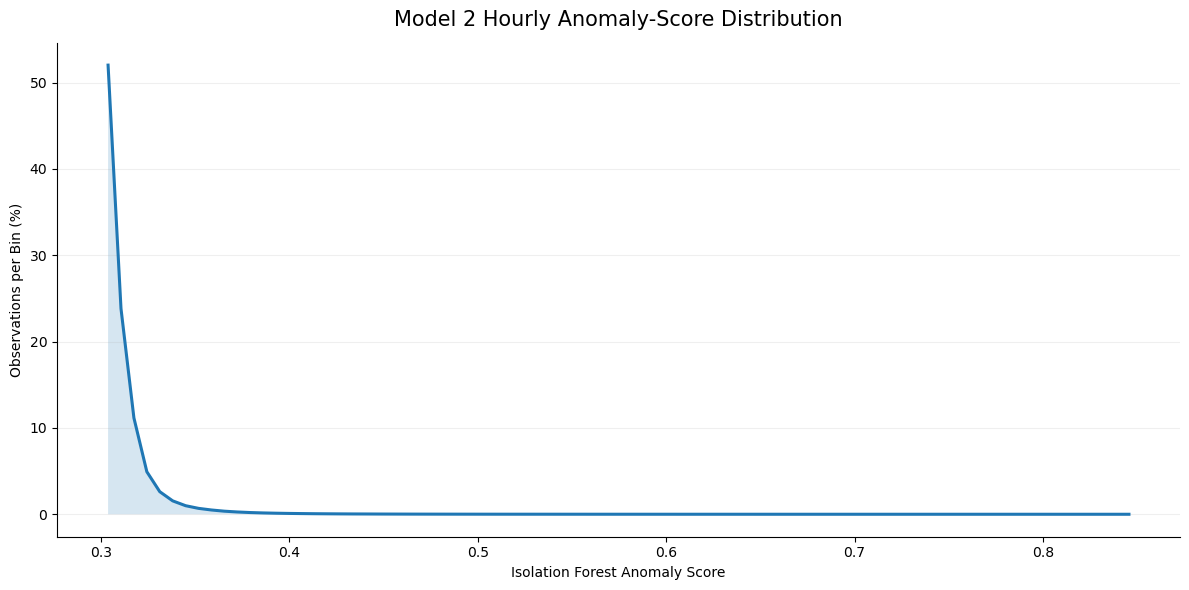

CELL 52 - PLOT THE COMPLETE HOURLY ANOMALY-SCORE DISTRIBUTION

Observations represented : 19,128,803
Minimum anomaly score    : 0.300405
Maximum anomaly score    : 0.849005

Figure:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\figures\model_hourly_anomaly_score_distribution.png

The complete Model 2 anomaly-score distribution was plotted successfully.


In [53]:
# ================================================================
# CELL 52 - PLOT THE COMPLETE HOURLY ANOMALY-SCORE DISTRIBUTION
# ================================================================

MODEL_HOURLY_SCORE_DISTRIBUTION_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_anomaly_score_distribution.png"
)


MODEL_HOURLY_SCORE_HISTOGRAM_BINS = (
    80
)


score_bounds = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            MIN(
                {MODEL_HOURLY_SCORE_COLUMN}
            ) AS minimum_score,

            MAX(
                {MODEL_HOURLY_SCORE_COLUMN}
            ) AS maximum_score

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )
        """
    )
    .df()
)


MODEL_HOURLY_SCORE_MINIMUM = float(
    score_bounds.loc[
        0,
        "minimum_score"
    ]
)


MODEL_HOURLY_SCORE_MAXIMUM = float(
    score_bounds.loc[
        0,
        "maximum_score"
    ]
)


MODEL_HOURLY_SCORE_BIN_WIDTH = (
    (
        MODEL_HOURLY_SCORE_MAXIMUM
        -
        MODEL_HOURLY_SCORE_MINIMUM
    )
    /
    MODEL_HOURLY_SCORE_HISTOGRAM_BINS
)


model_hourly_score_distribution = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        WITH score_bins AS (
            SELECT
                LEAST(
                    {MODEL_HOURLY_SCORE_HISTOGRAM_BINS - 1},

                    GREATEST(
                        0,

                        CAST(
                            FLOOR(
                                (
                                    {MODEL_HOURLY_SCORE_COLUMN}
                                    -
                                    {MODEL_HOURLY_SCORE_MINIMUM}
                                )
                                /
                                {MODEL_HOURLY_SCORE_BIN_WIDTH}
                            )
                            AS INTEGER
                        )
                    )
                ) AS bin_number

            FROM read_parquet(
                [
                    {final_ranked_file_sql}
                ],
                union_by_name = true
            )
        )

        SELECT
            bin_number,

            COUNT(*) AS observations

        FROM score_bins

        GROUP BY
            bin_number

        ORDER BY
            bin_number
        """
    )
    .df()
)


model_hourly_score_distribution[
    "score"
] = (
    MODEL_HOURLY_SCORE_MINIMUM
    +
    (
        model_hourly_score_distribution[
            "bin_number"
        ]
        +
        0.5
    )
    *
    MODEL_HOURLY_SCORE_BIN_WIDTH
)


model_hourly_score_distribution[
    "percentage"
] = (
    model_hourly_score_distribution[
        "observations"
    ]
    /
    MODEL_HOURLY_TOTAL_ROWS
    *
    100.0
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


sns.lineplot(
    data=model_hourly_score_distribution,
    x="score",
    y="percentage",
    linewidth=2.2,
    ax=axis
)


axis.fill_between(
    model_hourly_score_distribution[
        "score"
    ],
    model_hourly_score_distribution[
        "percentage"
    ],
    alpha=0.18
)


axis.set_title(
    "Model 2 Hourly Anomaly-Score Distribution",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Isolation Forest Anomaly Score"
)


axis.set_ylabel(
    "Observations per Bin (%)"
)


axis.grid(
    axis="y",
    alpha=0.20
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_SCORE_DISTRIBUTION_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 52 - PLOT THE COMPLETE "
    "HOURLY ANOMALY-SCORE DISTRIBUTION"
)
print("=" * 80)


print(
    f"\nObservations represented : "
    f"{int(model_hourly_score_distribution['observations'].sum()):,}"
)


print(
    f"Minimum anomaly score    : "
    f"{MODEL_HOURLY_SCORE_MINIMUM:.6f}"
)


print(
    f"Maximum anomaly score    : "
    f"{MODEL_HOURLY_SCORE_MAXIMUM:.6f}"
)


print(
    f"\nFigure:\n"
    f"{MODEL_HOURLY_SCORE_DISTRIBUTION_FIGURE}"
)


assert int(
    model_hourly_score_distribution[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert MODEL_HOURLY_SCORE_DISTRIBUTION_FIGURE.exists()


print(
    "\nThe complete Model 2 anomaly-score "
    "distribution was plotted successfully."
)

## What Cell 52 Does

This cell visualises the anomaly-score distribution across the complete hourly Model 2 population.

All current hourly observations contribute to the distribution.

For efficiency, DuckDB aggregates the approximately 19 million anomaly scores into fixed score bins before the compact distribution is passed to the plotting layer.

Larger Isolation Forest anomaly scores represent observations considered more unusual relative to the established hourly model.

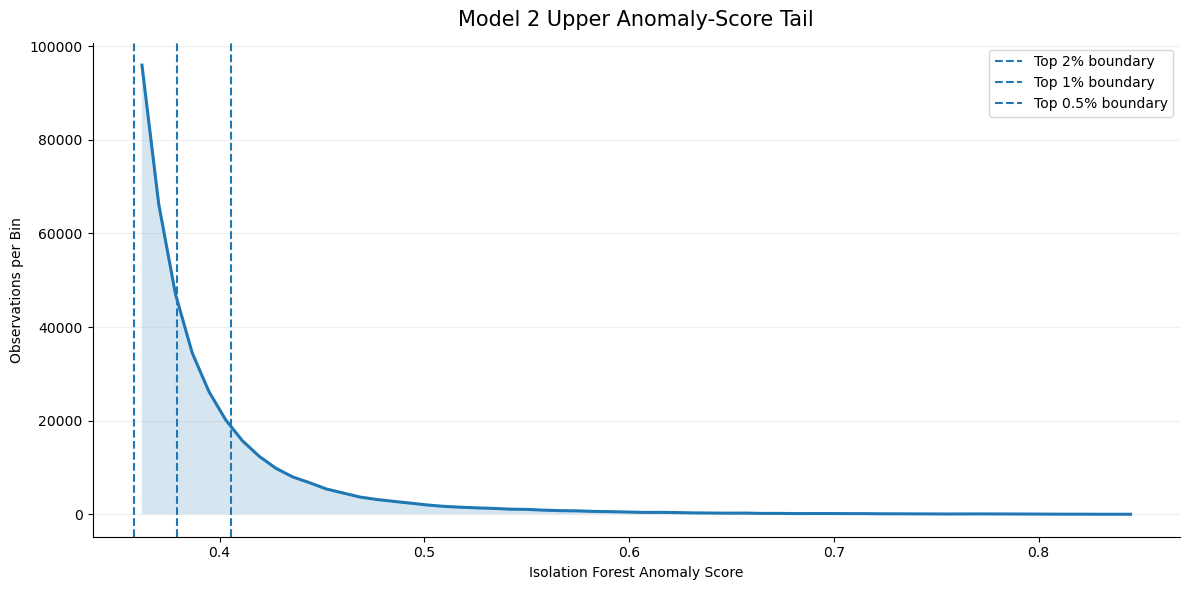

CELL 53 - PLOT THE UPPER ANOMALY-SCORE TAIL AND THRESHOLDS

Top 2% score boundary   : 0.358031
Top 1% score boundary   : 0.379143
Top 0.5% score boundary : 0.405695

The upper anomaly-score tail and exact global group boundaries were plotted successfully.


In [54]:
# ================================================================
# CELL 53 - PLOT THE UPPER ANOMALY-SCORE TAIL AND THRESHOLDS
# ================================================================

MODEL_HOURLY_UPPER_TAIL_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_upper_anomaly_score_tail.png"
)


hourly_threshold_scores = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            MAX(
                CASE
                    WHEN
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                        =
                        {MODEL_HOURLY_TOP_2_PERCENT_ROWS}

                    THEN
                        {MODEL_HOURLY_SCORE_COLUMN}
                END
            ) AS top_2_threshold,

            MAX(
                CASE
                    WHEN
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                        =
                        {MODEL_HOURLY_TOP_1_PERCENT_ROWS}

                    THEN
                        {MODEL_HOURLY_SCORE_COLUMN}
                END
            ) AS top_1_threshold,

            MAX(
                CASE
                    WHEN
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                        =
                        {MODEL_HOURLY_TOP_0_5_PERCENT_ROWS}

                    THEN
                        {MODEL_HOURLY_SCORE_COLUMN}
                END
            ) AS top_0_5_threshold

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
        """
    )
    .df()
)


MODEL_HOURLY_TOP_2_SCORE_THRESHOLD = float(
    hourly_threshold_scores.loc[
        0,
        "top_2_threshold"
    ]
)


MODEL_HOURLY_TOP_1_SCORE_THRESHOLD = float(
    hourly_threshold_scores.loc[
        0,
        "top_1_threshold"
    ]
)


MODEL_HOURLY_TOP_0_5_SCORE_THRESHOLD = float(
    hourly_threshold_scores.loc[
        0,
        "top_0_5_threshold"
    ]
)


MODEL_HOURLY_UPPER_TAIL_BINS = (
    60
)


MODEL_HOURLY_UPPER_TAIL_WIDTH = (
    (
        MODEL_HOURLY_SCORE_MAXIMUM
        -
        MODEL_HOURLY_TOP_2_SCORE_THRESHOLD
    )
    /
    MODEL_HOURLY_UPPER_TAIL_BINS
)


model_hourly_upper_tail = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        WITH tail_bins AS (
            SELECT
                LEAST(
                    {MODEL_HOURLY_UPPER_TAIL_BINS - 1},

                    GREATEST(
                        0,

                        CAST(
                            FLOOR(
                                (
                                    {MODEL_HOURLY_SCORE_COLUMN}
                                    -
                                    {MODEL_HOURLY_TOP_2_SCORE_THRESHOLD}
                                )
                                /
                                {MODEL_HOURLY_UPPER_TAIL_WIDTH}
                            )
                            AS INTEGER
                        )
                    )
                ) AS bin_number

            FROM
                {MODEL_HOURLY_GLOBAL_RANKING_TABLE}

            WHERE
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_HOURLY_TOP_2_PERCENT_ROWS}
        )

        SELECT
            bin_number,

            COUNT(*) AS observations

        FROM tail_bins

        GROUP BY
            bin_number

        ORDER BY
            bin_number
        """
    )
    .df()
)


model_hourly_upper_tail[
    "score"
] = (
    MODEL_HOURLY_TOP_2_SCORE_THRESHOLD
    +
    (
        model_hourly_upper_tail[
            "bin_number"
        ]
        +
        0.5
    )
    *
    MODEL_HOURLY_UPPER_TAIL_WIDTH
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


sns.lineplot(
    data=model_hourly_upper_tail,
    x="score",
    y="observations",
    linewidth=2.2,
    ax=axis
)


axis.fill_between(
    model_hourly_upper_tail[
        "score"
    ],
    model_hourly_upper_tail[
        "observations"
    ],
    alpha=0.18
)


axis.axvline(
    MODEL_HOURLY_TOP_2_SCORE_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label="Top 2% boundary"
)


axis.axvline(
    MODEL_HOURLY_TOP_1_SCORE_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label="Top 1% boundary"
)


axis.axvline(
    MODEL_HOURLY_TOP_0_5_SCORE_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label="Top 0.5% boundary"
)


axis.set_title(
    "Model 2 Upper Anomaly-Score Tail",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Isolation Forest Anomaly Score"
)


axis.set_ylabel(
    "Observations per Bin"
)


axis.grid(
    axis="y",
    alpha=0.20
)


axis.legend()


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_UPPER_TAIL_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 53 - PLOT THE UPPER "
    "ANOMALY-SCORE TAIL AND THRESHOLDS"
)
print("=" * 80)


print(
    f"\nTop 2% score boundary   : "
    f"{MODEL_HOURLY_TOP_2_SCORE_THRESHOLD:.6f}"
)


print(
    f"Top 1% score boundary   : "
    f"{MODEL_HOURLY_TOP_1_SCORE_THRESHOLD:.6f}"
)


print(
    f"Top 0.5% score boundary : "
    f"{MODEL_HOURLY_TOP_0_5_SCORE_THRESHOLD:.6f}"
)


assert (
    MODEL_HOURLY_TOP_0_5_SCORE_THRESHOLD
    >=
    MODEL_HOURLY_TOP_1_SCORE_THRESHOLD
    >=
    MODEL_HOURLY_TOP_2_SCORE_THRESHOLD
)


assert MODEL_HOURLY_UPPER_TAIL_FIGURE.exists()


print(
    "\nThe upper anomaly-score tail and exact "
    "global group boundaries were plotted successfully."
)

## What Cell 53 Does

This cell focuses on the upper anomaly-score tail containing the strongest 2% of Model 2 observations.

The exact anomaly scores at the global Top 2%, Top 1% and Top 0.5% rank boundaries are recovered from the global ranking table.

These boundaries are shown directly on the upper-tail distribution.

This illustrates how the strongest globally ranked anomaly groups relate to the continuous Isolation Forest score rather than treating the groups as separate fitted-model classifications.

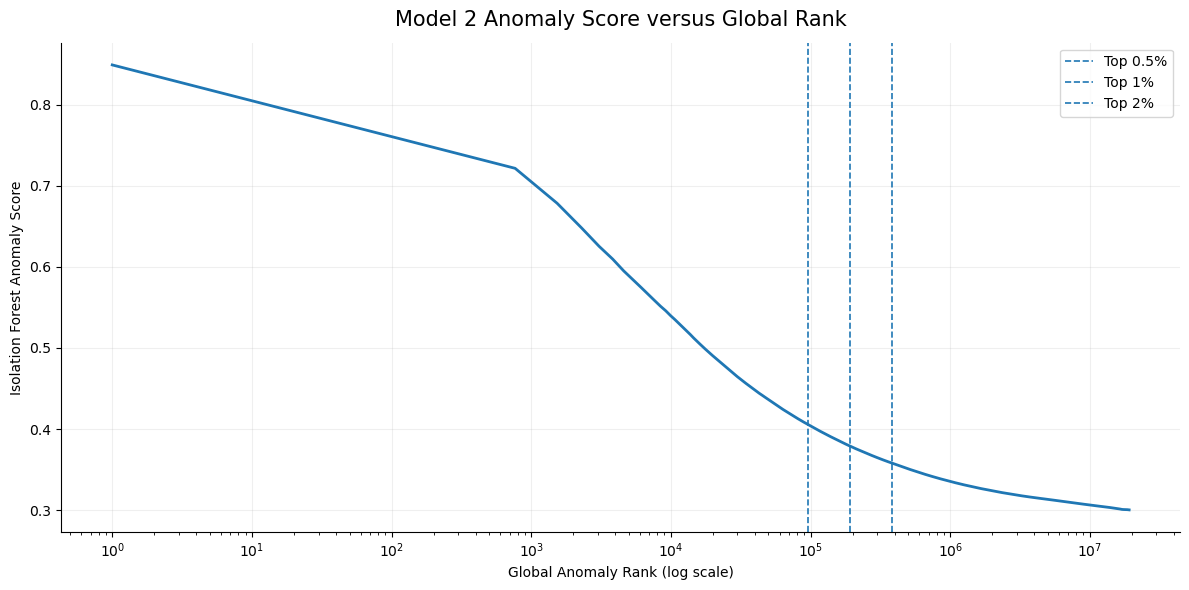

CELL 54 - PLOT ANOMALY SCORE AGAINST GLOBAL RANK

Plot observations : 24,977
Rank sampling step: 766

The relationship between anomaly score and exact global rank was plotted successfully.


In [55]:
# ================================================================
# CELL 54 - PLOT ANOMALY SCORE AGAINST GLOBAL RANK
# ================================================================

MODEL_HOURLY_SCORE_RANK_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_score_vs_global_rank.png"
)


MODEL_HOURLY_RANK_PLOT_TARGET_POINTS = (
    25_000
)


MODEL_HOURLY_RANK_PLOT_STEP = max(
    1,
    int(
        np.ceil(
            MODEL_HOURLY_TOTAL_ROWS
            /
            MODEL_HOURLY_RANK_PLOT_TARGET_POINTS
        )
    )
)


model_hourly_score_rank_plot = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            AS global_rank,

            {MODEL_HOURLY_SCORE_COLUMN}
            AS anomaly_score

        FROM
            {MODEL_HOURLY_GLOBAL_RANKING_TABLE}

        WHERE
            (
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                -
                1
            )
            %
            {MODEL_HOURLY_RANK_PLOT_STEP}
            =
            0

            OR
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            IN (
                1,
                {MODEL_HOURLY_TOP_0_5_PERCENT_ROWS},
                {MODEL_HOURLY_TOP_1_PERCENT_ROWS},
                {MODEL_HOURLY_TOP_2_PERCENT_ROWS},
                {MODEL_HOURLY_TOTAL_ROWS}
            )

        ORDER BY
            {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
        """
    )
    .df()
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


sns.lineplot(
    data=model_hourly_score_rank_plot,
    x="global_rank",
    y="anomaly_score",
    linewidth=2.0,
    ax=axis
)


axis.axvline(
    MODEL_HOURLY_TOP_0_5_PERCENT_ROWS,
    linestyle="--",
    linewidth=1.2,
    label="Top 0.5%"
)


axis.axvline(
    MODEL_HOURLY_TOP_1_PERCENT_ROWS,
    linestyle="--",
    linewidth=1.2,
    label="Top 1%"
)


axis.axvline(
    MODEL_HOURLY_TOP_2_PERCENT_ROWS,
    linestyle="--",
    linewidth=1.2,
    label="Top 2%"
)


axis.set_xscale(
    "log"
)


axis.set_title(
    "Model 2 Anomaly Score versus Global Rank",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Global Anomaly Rank (log scale)"
)


axis.set_ylabel(
    "Isolation Forest Anomaly Score"
)


axis.grid(
    alpha=0.20
)


axis.legend()


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_SCORE_RANK_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 54 - PLOT ANOMALY SCORE "
    "AGAINST GLOBAL RANK"
)
print("=" * 80)


print(
    f"\nPlot observations : "
    f"{len(model_hourly_score_rank_plot):,}"
)


print(
    f"Rank sampling step: "
    f"{MODEL_HOURLY_RANK_PLOT_STEP:,}"
)


assert len(
    model_hourly_score_rank_plot
) > 0


assert MODEL_HOURLY_SCORE_RANK_FIGURE.exists()


print(
    "\nThe relationship between anomaly "
    "score and exact global rank was plotted successfully."
)

## What Cell 54 Does

This cell visualises the relationship between Isolation Forest anomaly score and exact global anomaly rank.

The ranking itself remains based on every hourly observation.

Only the plotted representation is thinned to a large systematic set of points so that approximately 19 million ranked observations do not need to be transferred into Python for one figure.

A logarithmic rank axis gives greater visual detail to the strongest anomalies while retaining the complete ranking range.

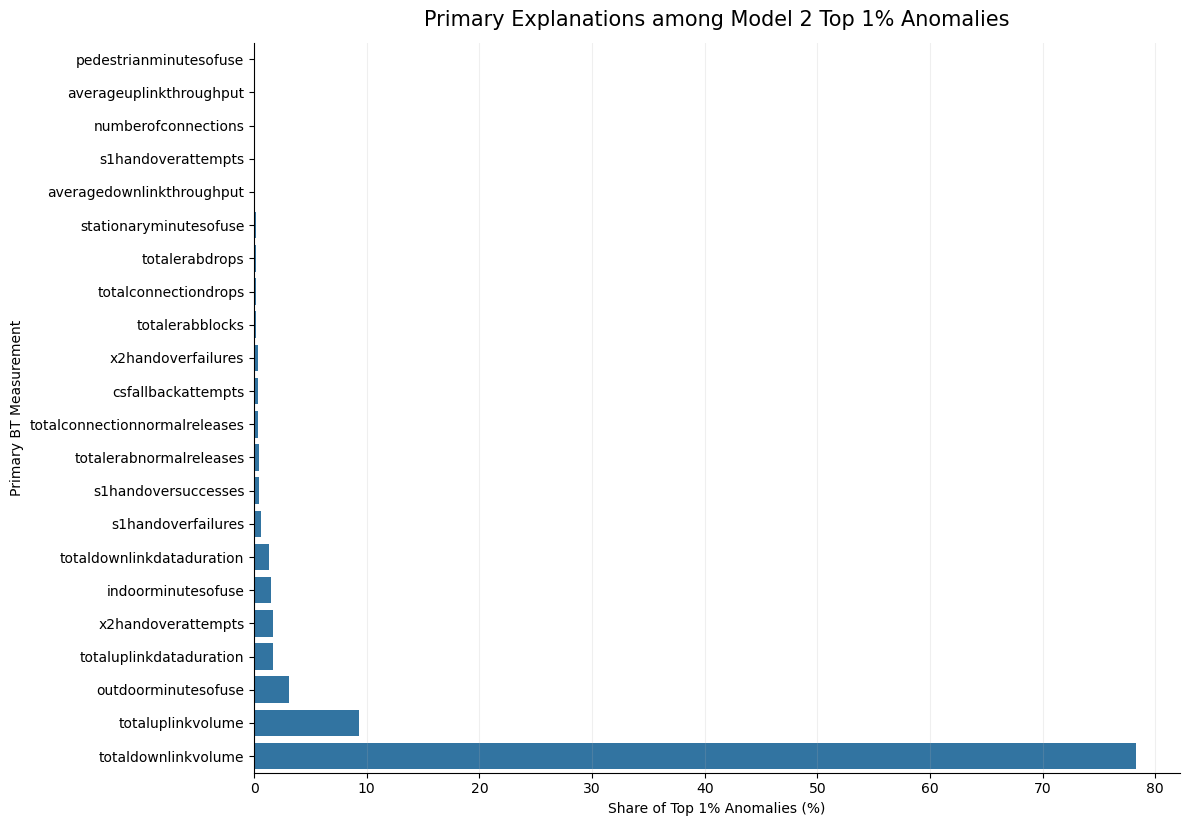

CELL 55 - ANALYSE PRIMARY EXPLANATIONS WITHIN THE TOP 1%


,primary_reason,observations,percentage
0,totaldownlinkvolume,149738,78.278416
1,totaluplinkvolume,17756,9.282290
2,outdoorminutesofuse,5840,3.052972
3,totaluplinkdataduration,3181,1.662929
4,x2handoverattempts,3122,1.632085
5,indoorminutesofuse,2790,1.458526
6,totaldownlinkdataduration,2438,1.274511
7,s1handoverfailures,1247,0.651893
8,s1handoversuccesses,906,0.473629
9,totalerabnormalreleases,788,0.411942



Primary descriptive explanations for the Top 1% were analysed successfully.


In [56]:
# ================================================================
# CELL 55 - ANALYSE PRIMARY EXPLANATIONS WITHIN THE TOP 1%
# ================================================================

MODEL_HOURLY_PRIMARY_EXPLANATION_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_top_1_primary_explanations.png"
)


MODEL_HOURLY_PRIMARY_EXPLANATION_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_top_1_primary_explanations.csv"
)


model_hourly_primary_explanations = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_HOURLY_PRIMARY_REASON_COLUMN}
            AS primary_reason,

            COUNT(*) AS observations,

            COUNT(*)
            /
            CAST(
                {MODEL_HOURLY_TOP_1_PERCENT_ROWS}
                AS DOUBLE
            )
            *
            100.0
            AS percentage

        FROM read_parquet(
            '{safe_top_1_percent_file}'
        )

        GROUP BY
            {MODEL_HOURLY_PRIMARY_REASON_COLUMN}

        ORDER BY
            observations DESC,
            primary_reason
        """
    )
    .df()
)


model_hourly_primary_explanations.to_csv(
    MODEL_HOURLY_PRIMARY_EXPLANATION_TABLE,
    index=False
)


figure_height = max(
    6,
    0.38
    *
    len(
        model_hourly_primary_explanations
    )
)


figure, axis = plt.subplots(
    figsize=(
        12,
        figure_height
    )
)


sns.barplot(
    data=(
        model_hourly_primary_explanations
        .sort_values(
            "percentage",
            ascending=True
        )
    ),
    x="percentage",
    y="primary_reason",
    ax=axis
)


axis.set_title(
    "Primary Explanations among Model 2 Top 1% Anomalies",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Share of Top 1% Anomalies (%)"
)


axis.set_ylabel(
    "Primary BT Measurement"
)


axis.grid(
    axis="x",
    alpha=0.20
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_PRIMARY_EXPLANATION_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 55 - ANALYSE PRIMARY "
    "EXPLANATIONS WITHIN THE TOP 1%"
)
print("=" * 80)


display(
    model_hourly_primary_explanations
)


assert int(
    model_hourly_primary_explanations[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert MODEL_HOURLY_PRIMARY_EXPLANATION_TABLE.exists()


assert MODEL_HOURLY_PRIMARY_EXPLANATION_FIGURE.exists()


print(
    "\nPrimary descriptive explanations "
    "for the Top 1% were analysed successfully."
)

## What Cell 55 Does

This cell examines which retained BT measurements most frequently provide the strongest robust descriptive deviation among globally Top 1% hourly anomalies.

The explanation is not a formal feature-importance measure for the Isolation Forest.

Instead, it compares each anomalous observation with the robust normal-reference medians and scales created earlier and records which measurement deviates most strongly.

The resulting table and figure show which BT measurements most commonly characterise the strongest hourly anomalies.

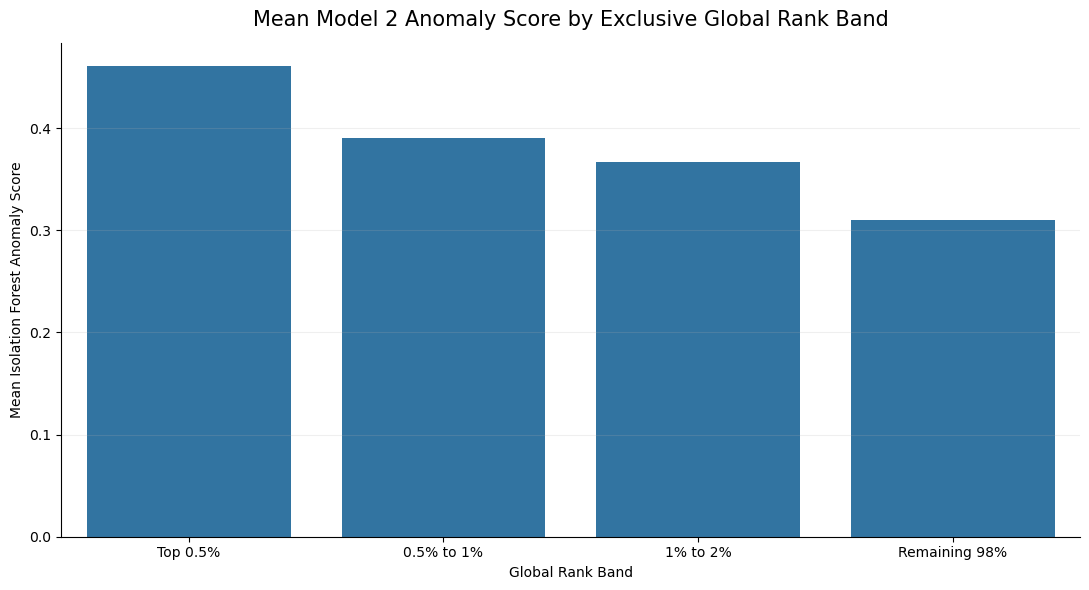

CELL 56 - SUMMARISE AND VISUALISE HOURLY ANOMALY GROUP BEHAVIOUR


,anomaly_band,observations,mean_score,median_score,minimum_score,maximum_score
0,Top 0.5%,95645,0.460780,0.438675,0.405695,0.849005
1,0.5% to 1%,95644,0.390456,0.389504,0.379143,0.405694
2,1% to 2%,191288,0.366956,0.366184,0.358031,0.379143
3,Remaining 98%,18746226,0.309756,0.306685,0.300405,0.358031



Section 12 is complete. The global Model 2 anomaly bands were summarised successfully.


In [57]:
# ================================================================
# CELL 56 - SUMMARISE AND VISUALISE HOURLY ANOMALY GROUP BEHAVIOUR
# ================================================================

MODEL_HOURLY_GROUP_BEHAVIOUR_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_anomaly_group_behaviour.png"
)


MODEL_HOURLY_GROUP_BEHAVIOUR_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_anomaly_group_behaviour.csv"
)


model_hourly_group_behaviour = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        WITH anomaly_bands AS (
            SELECT
                CASE
                    WHEN
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                        <=
                        {MODEL_HOURLY_TOP_0_5_PERCENT_ROWS}

                    THEN
                        'Top 0.5%'

                    WHEN
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                        <=
                        {MODEL_HOURLY_TOP_1_PERCENT_ROWS}

                    THEN
                        '0.5% to 1%'

                    WHEN
                        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
                        <=
                        {MODEL_HOURLY_TOP_2_PERCENT_ROWS}

                    THEN
                        '1% to 2%'

                    ELSE
                        'Remaining 98%'

                END AS anomaly_band,

                {MODEL_HOURLY_SCORE_COLUMN}
                AS anomaly_score

            FROM
                {MODEL_HOURLY_GLOBAL_RANKING_TABLE}
        )

        SELECT
            anomaly_band,

            COUNT(*) AS observations,

            AVG(
                anomaly_score
            ) AS mean_score,

            MEDIAN(
                anomaly_score
            ) AS median_score,

            MIN(
                anomaly_score
            ) AS minimum_score,

            MAX(
                anomaly_score
            ) AS maximum_score

        FROM anomaly_bands

        GROUP BY
            anomaly_band
        """
    )
    .df()
)


MODEL_HOURLY_ANOMALY_BAND_ORDER = [
    "Top 0.5%",
    "0.5% to 1%",
    "1% to 2%",
    "Remaining 98%"
]


model_hourly_group_behaviour[
    "anomaly_band"
] = pd.Categorical(
    model_hourly_group_behaviour[
        "anomaly_band"
    ],
    categories=(
        MODEL_HOURLY_ANOMALY_BAND_ORDER
    ),
    ordered=True
)


model_hourly_group_behaviour = (
    model_hourly_group_behaviour
    .sort_values(
        "anomaly_band"
    )
    .reset_index(
        drop=True
    )
)


model_hourly_group_behaviour.to_csv(
    MODEL_HOURLY_GROUP_BEHAVIOUR_TABLE,
    index=False
)


figure, axis = plt.subplots(
    figsize=(
        11,
        6
    )
)


sns.barplot(
    data=model_hourly_group_behaviour,
    x="anomaly_band",
    y="mean_score",
    order=MODEL_HOURLY_ANOMALY_BAND_ORDER,
    ax=axis
)


axis.set_title(
    "Mean Model 2 Anomaly Score by Exclusive Global Rank Band",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Global Rank Band"
)


axis.set_ylabel(
    "Mean Isolation Forest Anomaly Score"
)


axis.grid(
    axis="y",
    alpha=0.20
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_GROUP_BEHAVIOUR_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 56 - SUMMARISE AND VISUALISE "
    "HOURLY ANOMALY GROUP BEHAVIOUR"
)
print("=" * 80)


display(
    model_hourly_group_behaviour
)


assert int(
    model_hourly_group_behaviour[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert MODEL_HOURLY_GROUP_BEHAVIOUR_TABLE.exists()


assert MODEL_HOURLY_GROUP_BEHAVIOUR_FIGURE.exists()


print(
    "\nSection 12 is complete. The global "
    "Model 2 anomaly bands were summarised successfully."
)

## What Cell 56 Does

This cell compares mutually exclusive parts of the exact global anomaly ranking.

The Top 0.5%, the following 0.5% to 1%, the following 1% to 2%, and the remaining 98% are treated as separate bands so that no observation is counted in more than one group.

For each band, the cell calculates the number of observations and several anomaly-score summaries.

The figure compares mean Isolation Forest score across these exclusive ranking bands.

Section 12 is complete.

# 13. Hour-of-Day Analysis

This section uses the hourly resolution of Model 2 to investigate when strong anomalies occur.

Unlike the daily Model 1 workflow, the hourly data allow anomaly behaviour to be separated by hour of day as well as by observation date.

A lightweight DuckDB temporal view is created from the final ranked partitions so that later temporal analyses can use the complete Model 2 population without creating another large permanent copy of the data.

The section examines hour-of-day anomaly rates, variation between available dates, date × hour patterns and the available weekday/weekend structure.

In [58]:
# ================================================================
# CELL 57 - PREPARE THE HOURLY TEMPORAL ANALYSIS DATASET
# ================================================================

MODEL_HOURLY_TEMPORAL_VIEW = (
    "model_hourly_temporal_analysis"
)


MODEL_HOURLY_CONNECTION.execute(
    f"""
    CREATE OR REPLACE VIEW
        {MODEL_HOURLY_TEMPORAL_VIEW}
    AS

    SELECT
        TRY_CAST(
            {model_hourly_quote_identifier(
                MODEL_HOURLY_DATE_COLUMN
            )}
            AS DATE
        )
        AS observation_date,

        CAST(
            {MODEL_HOURLY_HOUR_COLUMN}
            AS INTEGER
        )
        AS hour_of_day,

        {MODEL_HOURLY_SCORE_COLUMN}
        AS anomaly_score,

        {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
        AS global_rank,

        {MODEL_HOURLY_TOP_2_COLUMN}
        AS top_2_percent,

        {MODEL_HOURLY_TOP_1_COLUMN}
        AS top_1_percent,

        {MODEL_HOURLY_TOP_0_5_COLUMN}
        AS top_0_5_percent,

        {MODEL_HOURLY_LOCATION_COLUMN}
        AS location_id,

        DAYNAME(
            TRY_CAST(
                {model_hourly_quote_identifier(
                    MODEL_HOURLY_DATE_COLUMN
                )}
                AS DATE
            )
        )
        AS day_of_week,

        CASE
            WHEN
                DAYOFWEEK(
                    TRY_CAST(
                        {model_hourly_quote_identifier(
                            MODEL_HOURLY_DATE_COLUMN
                        )}
                        AS DATE
                    )
                )
                IN (
                    0,
                    6
                )

            THEN
                'Weekend'

            ELSE
                'Weekday'

        END
        AS day_type

    FROM read_parquet(
        [
            {final_ranked_file_sql}
        ],
        union_by_name = true
    )
    """
)


model_hourly_temporal_validation = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                DISTINCT observation_date
            ) AS dates,

            COUNT(
                DISTINCT hour_of_day
            ) AS hours,

            MIN(
                observation_date
            ) AS first_date,

            MAX(
                observation_date
            ) AS last_date,

            MIN(
                hour_of_day
            ) AS first_hour,

            MAX(
                hour_of_day
            ) AS last_hour,

            COUNT(*) FILTER (
                WHERE
                    observation_date
                    IS NULL
                    OR
                    hour_of_day
                    IS NULL
            ) AS missing_temporal_rows

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}
        """
    )
    .df()
)


print("=" * 80)
print(
    "CELL 57 - PREPARE THE "
    "HOURLY TEMPORAL ANALYSIS DATASET"
)
print("=" * 80)


display(
    model_hourly_temporal_validation
)


assert int(
    model_hourly_temporal_validation.loc[
        0,
        "observations"
    ]
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_temporal_validation.loc[
        0,
        "missing_temporal_rows"
    ]
) == 0


assert int(
    model_hourly_temporal_validation.loc[
        0,
        "hours"
    ]
) > 0


print(
    "\nThe complete Model 2 temporal-analysis "
    "view was prepared successfully."
)

CELL 57 - PREPARE THE HOURLY TEMPORAL ANALYSIS DATASET


,observations,dates,hours,first_date,last_date,first_hour,last_hour,missing_temporal_rows
0,19128803,4,24,2026-07-14,2026-07-17,0,23,0



The complete Model 2 temporal-analysis view was prepared successfully.


## What Cell 57 Does

This cell creates the reusable temporal-analysis view used by the remaining hour-based analyses.

The view references the final ranked Parquet partitions directly, so it does not create another permanent copy of the approximately 19 million hourly observations.

For each observation it retains the date, hour of day, anomaly score, global rank, anomaly-group indicators and location identifier.

Calendar fields for day of week and weekday/weekend status are also derived dynamically from the available dates.

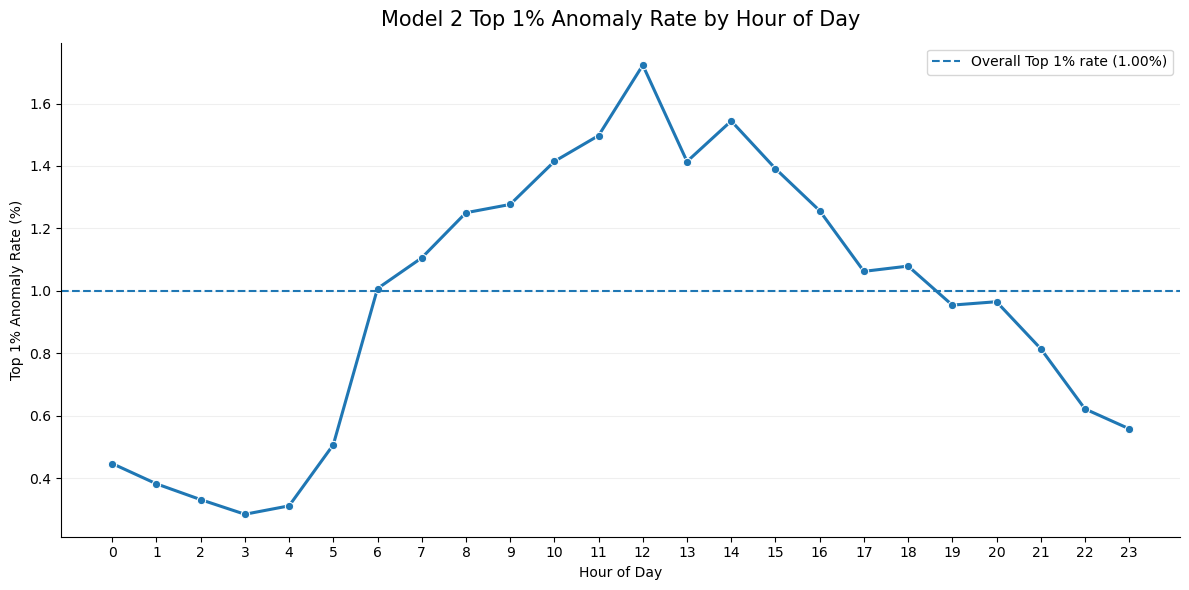

CELL 58 - ANALYSE TOP 1% ANOMALY RATE BY HOUR OF DAY


,hour_of_day,observations,top_1_percent_count,top_0_5_percent_count,mean_anomaly_score,top_1_percent_rate,top_0_5_percent_rate
0,0,673130,3006,1524,0.308435,0.446570,0.226405
1,1,667024,2546,1289,0.308196,0.381695,0.193246
2,2,671614,2224,1159,0.308122,0.331143,0.172569
3,3,676551,1923,943,0.308016,0.284236,0.139383
4,4,729728,2271,1068,0.308624,0.311212,0.146356
5,5,806018,4087,1731,0.309946,0.507061,0.214759
6,6,883412,8899,4278,0.311974,1.007344,0.484259
7,7,877068,9697,4567,0.312717,1.105616,0.520712
8,8,892173,11154,5547,0.312798,1.250206,0.621740
9,9,908118,11594,5775,0.312872,1.276706,0.635931



Highest Top 1% anomaly-rate hour: 12:00
Highest hourly rate: 1.723%

Top 1% anomaly behaviour by hour of day was analysed successfully.


In [59]:
# ================================================================
# CELL 58 - ANALYSE TOP 1% ANOMALY RATE BY HOUR OF DAY
# ================================================================

MODEL_HOURLY_HOUR_RATE_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_top_1_rate_by_hour.png"
)


MODEL_HOURLY_HOUR_RATE_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_top_1_rate_by_hour.csv"
)


model_hourly_hour_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            hour_of_day,

            COUNT(*) AS observations,

            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            ) AS top_1_percent_count,

            COUNT(*) FILTER (
                WHERE
                    top_0_5_percent
            ) AS top_0_5_percent_count,

            AVG(
                anomaly_score
            ) AS mean_anomaly_score

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}

        GROUP BY
            hour_of_day

        ORDER BY
            hour_of_day
        """
    )
    .df()
)


model_hourly_hour_summary[
    "top_1_percent_rate"
] = (
    model_hourly_hour_summary[
        "top_1_percent_count"
    ]
    /
    model_hourly_hour_summary[
        "observations"
    ]
    *
    100.0
)


model_hourly_hour_summary[
    "top_0_5_percent_rate"
] = (
    model_hourly_hour_summary[
        "top_0_5_percent_count"
    ]
    /
    model_hourly_hour_summary[
        "observations"
    ]
    *
    100.0
)


MODEL_HOURLY_GLOBAL_TOP_1_RATE = (
    MODEL_HOURLY_TOP_1_PERCENT_ROWS
    /
    MODEL_HOURLY_TOTAL_ROWS
    *
    100.0
)


model_hourly_hour_summary.to_csv(
    MODEL_HOURLY_HOUR_RATE_TABLE,
    index=False
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


sns.lineplot(
    data=model_hourly_hour_summary,
    x="hour_of_day",
    y="top_1_percent_rate",
    marker="o",
    linewidth=2.2,
    ax=axis
)


axis.axhline(
    MODEL_HOURLY_GLOBAL_TOP_1_RATE,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall Top 1% rate "
        f"({MODEL_HOURLY_GLOBAL_TOP_1_RATE:.2f}%)"
    )
)


axis.set_title(
    "Model 2 Top 1% Anomaly Rate by Hour of Day",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Hour of Day"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.set_xticks(
    model_hourly_hour_summary[
        "hour_of_day"
    ].tolist()
)


axis.grid(
    axis="y",
    alpha=0.20
)


axis.legend()


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_HOUR_RATE_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 58 - ANALYSE TOP 1% "
    "ANOMALY RATE BY HOUR OF DAY"
)
print("=" * 80)


display(
    model_hourly_hour_summary
)


highest_hour_row = (
    model_hourly_hour_summary
    .sort_values(
        "top_1_percent_rate",
        ascending=False
    )
    .iloc[
        0
    ]
)


print(
    f"\nHighest Top 1% anomaly-rate hour: "
    f"{int(highest_hour_row['hour_of_day']):02d}:00"
)


print(
    f"Highest hourly rate: "
    f"{highest_hour_row['top_1_percent_rate']:.3f}%"
)


assert int(
    model_hourly_hour_summary[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_hour_summary[
        "top_1_percent_count"
    ].sum()
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert MODEL_HOURLY_HOUR_RATE_TABLE.exists()


assert MODEL_HOURLY_HOUR_RATE_FIGURE.exists()


print(
    "\nTop 1% anomaly behaviour by "
    "hour of day was analysed successfully."
)

## What Cell 58 Does

This cell measures how the globally strongest Top 1% anomalies are distributed across the available hours of the day.

For each hour, the anomaly rate is calculated as the number of Top 1% observations divided by the total number of Model 2 observations recorded at that hour.

This is preferable to comparing raw anomaly counts because different hours may contain different numbers of observations.

The overall global Top 1% rate is shown as a reference line, making it easy to identify hours with unusually high or low concentrations of strong anomalies.

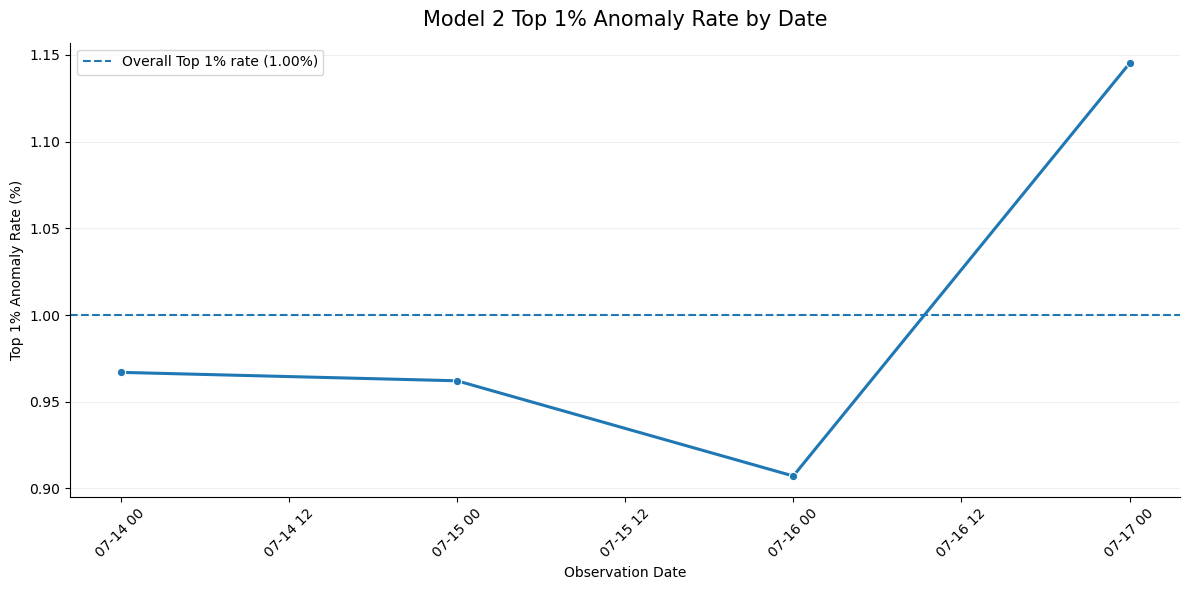

CELL 59 - ANALYSE HOURLY ANOMALY BEHAVIOUR BY DATE


,observation_date,observations,top_1_percent_count,top_0_5_percent_count,mean_anomaly_score,maximum_anomaly_score,top_1_percent_rate,top_0_5_percent_rate
0,2026-07-14,4896986,47351,22733,0.311499,0.807078,0.966942,0.464224
1,2026-07-15,4771010,45901,22728,0.311417,0.832349,0.962081,0.476377
2,2026-07-16,4329552,39277,19782,0.311073,0.838048,0.907184,0.456906
3,2026-07-17,5131255,58760,30402,0.311890,0.849005,1.145139,0.592487



Highest-rate date: 2026-07-17 00:00:00
Highest Top 1% rate: 1.145%

Anomaly behaviour by observation date was analysed successfully.


In [60]:
# ================================================================
# CELL 59 - ANALYSE HOURLY ANOMALY BEHAVIOUR BY DATE
# ================================================================

MODEL_HOURLY_DATE_RATE_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_top_1_rate_by_date.png"
)


MODEL_HOURLY_DATE_RATE_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_top_1_rate_by_date.csv"
)


model_hourly_date_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            observation_date,

            COUNT(*) AS observations,

            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            ) AS top_1_percent_count,

            COUNT(*) FILTER (
                WHERE
                    top_0_5_percent
            ) AS top_0_5_percent_count,

            AVG(
                anomaly_score
            ) AS mean_anomaly_score,

            MAX(
                anomaly_score
            ) AS maximum_anomaly_score

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}

        GROUP BY
            observation_date

        ORDER BY
            observation_date
        """
    )
    .df()
)


model_hourly_date_summary[
    "top_1_percent_rate"
] = (
    model_hourly_date_summary[
        "top_1_percent_count"
    ]
    /
    model_hourly_date_summary[
        "observations"
    ]
    *
    100.0
)


model_hourly_date_summary[
    "top_0_5_percent_rate"
] = (
    model_hourly_date_summary[
        "top_0_5_percent_count"
    ]
    /
    model_hourly_date_summary[
        "observations"
    ]
    *
    100.0
)


model_hourly_date_summary.to_csv(
    MODEL_HOURLY_DATE_RATE_TABLE,
    index=False
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


sns.lineplot(
    data=model_hourly_date_summary,
    x="observation_date",
    y="top_1_percent_rate",
    marker="o",
    linewidth=2.2,
    ax=axis
)


axis.axhline(
    MODEL_HOURLY_GLOBAL_TOP_1_RATE,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall Top 1% rate "
        f"({MODEL_HOURLY_GLOBAL_TOP_1_RATE:.2f}%)"
    )
)


axis.set_title(
    "Model 2 Top 1% Anomaly Rate by Date",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Observation Date"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.tick_params(
    axis="x",
    rotation=45
)


axis.grid(
    axis="y",
    alpha=0.20
)


axis.legend()


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_DATE_RATE_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 59 - ANALYSE HOURLY "
    "ANOMALY BEHAVIOUR BY DATE"
)
print("=" * 80)


display(
    model_hourly_date_summary
)


highest_date_row = (
    model_hourly_date_summary
    .sort_values(
        "top_1_percent_rate",
        ascending=False
    )
    .iloc[
        0
    ]
)


print(
    f"\nHighest-rate date: "
    f"{highest_date_row['observation_date']}"
)


print(
    f"Highest Top 1% rate: "
    f"{highest_date_row['top_1_percent_rate']:.3f}%"
)


assert int(
    model_hourly_date_summary[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert int(
    model_hourly_date_summary[
        "top_1_percent_count"
    ].sum()
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert MODEL_HOURLY_DATE_RATE_TABLE.exists()


assert MODEL_HOURLY_DATE_RATE_FIGURE.exists()


print(
    "\nAnomaly behaviour by observation "
    "date was analysed successfully."
)

## What Cell 59 Does

This cell compares Model 2 anomaly behaviour across the available observation dates.

For each date, the Top 1% anomaly rate is calculated relative to the complete number of hourly observations recorded on that date.

The overall global Top 1% rate is shown as a reference.

With the current dataset containing only four dates, these results should be interpreted as a short temporal case study rather than evidence of longer-term daily seasonality.

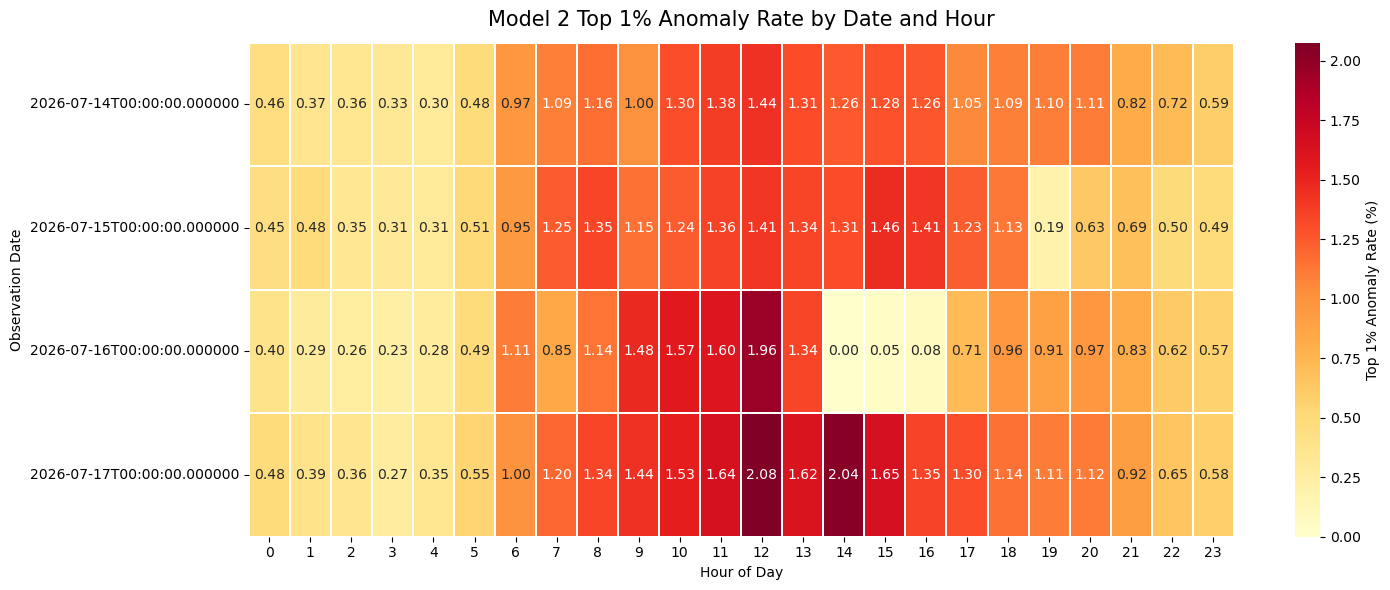

CELL 60 - CREATE THE DATE × HOUR TOP 1% ANOMALY HEATMAP

Dates represented : 4
Hours represented : 24

The date × hour anomaly heatmap was created successfully.


In [61]:
# ================================================================
# CELL 60 - CREATE THE DATE × HOUR TOP 1% ANOMALY HEATMAP
# ================================================================

MODEL_HOURLY_DATE_HOUR_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_date_hour_top_1_heatmap.png"
)


MODEL_HOURLY_DATE_HOUR_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_date_hour_top_1_rates.csv"
)


model_hourly_date_hour_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            observation_date,

            hour_of_day,

            COUNT(*) AS observations,

            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            ) AS top_1_percent_count

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}

        GROUP BY
            observation_date,
            hour_of_day

        ORDER BY
            observation_date,
            hour_of_day
        """
    )
    .df()
)


model_hourly_date_hour_summary[
    "top_1_percent_rate"
] = (
    model_hourly_date_hour_summary[
        "top_1_percent_count"
    ]
    /
    model_hourly_date_hour_summary[
        "observations"
    ]
    *
    100.0
)


model_hourly_date_hour_summary.to_csv(
    MODEL_HOURLY_DATE_HOUR_TABLE,
    index=False
)


model_hourly_date_hour_matrix = (
    model_hourly_date_hour_summary
    .pivot(
        index="observation_date",
        columns="hour_of_day",
        values="top_1_percent_rate"
    )
    .sort_index()
)


figure, axis = plt.subplots(
    figsize=(
        15,
        6
    )
)


sns.heatmap(
    model_hourly_date_hour_matrix,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=True,
    fmt=".2f",
    cbar_kws={
        "label": "Top 1% Anomaly Rate (%)"
    },
    ax=axis
)


axis.set_title(
    "Model 2 Top 1% Anomaly Rate by Date and Hour",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Hour of Day"
)


axis.set_ylabel(
    "Observation Date"
)


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_DATE_HOUR_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 60 - CREATE THE DATE × HOUR "
    "TOP 1% ANOMALY HEATMAP"
)
print("=" * 80)


print(
    f"\nDates represented : "
    f"{model_hourly_date_hour_matrix.shape[0]:,}"
)


print(
    f"Hours represented : "
    f"{model_hourly_date_hour_matrix.shape[1]:,}"
)


assert int(
    model_hourly_date_hour_summary[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert MODEL_HOURLY_DATE_HOUR_FIGURE.exists()


assert MODEL_HOURLY_DATE_HOUR_TABLE.exists()


print(
    "\nThe date × hour anomaly heatmap "
    "was created successfully."
)

## What Cell 60 Does

This cell creates a date × hour heatmap of the global Top 1% anomaly rate.

Each cell represents one observation date and one hour of day.

The rate is calculated relative to the number of observations available in that particular date-hour combination, allowing periods with different observation counts to be compared fairly.

This is one of the principal additions provided by the hourly Model 2 analysis because it exposes within-day patterns that are unavailable from daily aggregation alone.

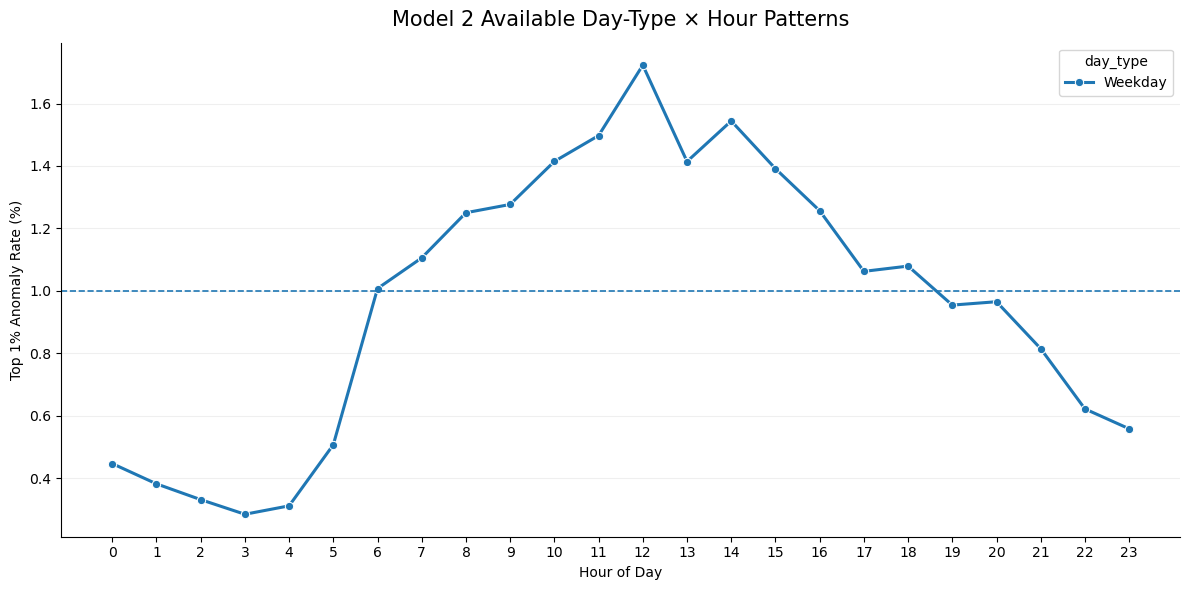

CELL 61 - ANALYSE AVAILABLE DAY-TYPE × HOUR PATTERNS


,day_type,hour_of_day,observations,top_1_percent_count,mean_anomaly_score,top_1_percent_rate
0,Weekday,0,673130,3006,0.308435,0.446570
1,Weekday,1,667024,2546,0.308196,0.381695
2,Weekday,2,671614,2224,0.308122,0.331143
3,Weekday,3,676551,1923,0.308016,0.284236
4,Weekday,4,729728,2271,0.308624,0.311212
5,Weekday,5,806018,4087,0.309946,0.507061
6,Weekday,6,883412,8899,0.311974,1.007344
7,Weekday,7,877068,9697,0.312717,1.105616
8,Weekday,8,892173,11154,0.312798,1.250206
9,Weekday,9,908118,11594,0.312872,1.276706



Available day types: ['Weekday']

A weekday/weekend comparison cannot yet be estimated because the current hourly data contain only one day type.

Section 13 is complete.


In [62]:
# ================================================================
# CELL 61 - ANALYSE AVAILABLE DAY-TYPE × HOUR PATTERNS
# ================================================================

MODEL_HOURLY_DAY_TYPE_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_day_type_hour_patterns.png"
)


MODEL_HOURLY_DAY_TYPE_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_day_type_hour_patterns.csv"
)


model_hourly_day_type_summary = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            day_type,

            hour_of_day,

            COUNT(*) AS observations,

            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            ) AS top_1_percent_count,

            AVG(
                anomaly_score
            ) AS mean_anomaly_score

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}

        GROUP BY
            day_type,
            hour_of_day

        ORDER BY
            day_type,
            hour_of_day
        """
    )
    .df()
)


model_hourly_day_type_summary[
    "top_1_percent_rate"
] = (
    model_hourly_day_type_summary[
        "top_1_percent_count"
    ]
    /
    model_hourly_day_type_summary[
        "observations"
    ]
    *
    100.0
)


model_hourly_day_type_summary.to_csv(
    MODEL_HOURLY_DAY_TYPE_TABLE,
    index=False
)


MODEL_HOURLY_AVAILABLE_DAY_TYPES = sorted(
    model_hourly_day_type_summary[
        "day_type"
    ]
    .dropna()
    .unique()
    .tolist()
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


sns.lineplot(
    data=model_hourly_day_type_summary,
    x="hour_of_day",
    y="top_1_percent_rate",
    hue="day_type",
    marker="o",
    linewidth=2.2,
    ax=axis
)


axis.axhline(
    MODEL_HOURLY_GLOBAL_TOP_1_RATE,
    linestyle="--",
    linewidth=1.2,
    label="Overall Top 1% rate"
)


axis.set_title(
    "Model 2 Available Day-Type × Hour Patterns",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Hour of Day"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.set_xticks(
    sorted(
        model_hourly_day_type_summary[
            "hour_of_day"
        ]
        .unique()
    )
)


axis.grid(
    axis="y",
    alpha=0.20
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_DAY_TYPE_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 61 - ANALYSE AVAILABLE "
    "DAY-TYPE × HOUR PATTERNS"
)
print("=" * 80)


display(
    model_hourly_day_type_summary
)


print(
    f"\nAvailable day types: "
    f"{MODEL_HOURLY_AVAILABLE_DAY_TYPES}"
)


if len(
    MODEL_HOURLY_AVAILABLE_DAY_TYPES
) < 2:

    print(
        "\nA weekday/weekend comparison cannot "
        "yet be estimated because the current "
        "hourly data contain only one day type."
    )


assert int(
    model_hourly_day_type_summary[
        "observations"
    ].sum()
) == MODEL_HOURLY_TOTAL_ROWS


assert MODEL_HOURLY_DAY_TYPE_TABLE.exists()


assert MODEL_HOURLY_DAY_TYPE_FIGURE.exists()


print(
    "\nSection 13 is complete."
)

## What Cell 61 Does

This cell investigates the available calendar structure of the hourly anomaly data.

The code is designed dynamically so that weekday and weekend patterns will both be shown once both types are present in the source data.

The current four-date dataset contains only weekdays, so a genuine weekday-versus-weekend comparison is not yet possible.

Rather than manufacturing a comparison from unavailable data, the current figure therefore shows the available weekday hourly pattern.

Future weekend files will automatically extend this analysis.

Section 13 is complete.

# 14. Hourly Location Analysis

This section investigates where the strongest Model 2 anomalies occur and whether the same grid locations recur through time.

The analysis distinguishes isolated extreme observations from locations that repeatedly appear in the global Top 1% anomaly population.

It also examines how many dates and hours contribute to each location and identifies consecutive anomalous-hour streaks.

These measures help separate one-off hourly anomalies from locations showing more persistent unusual network behaviour.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

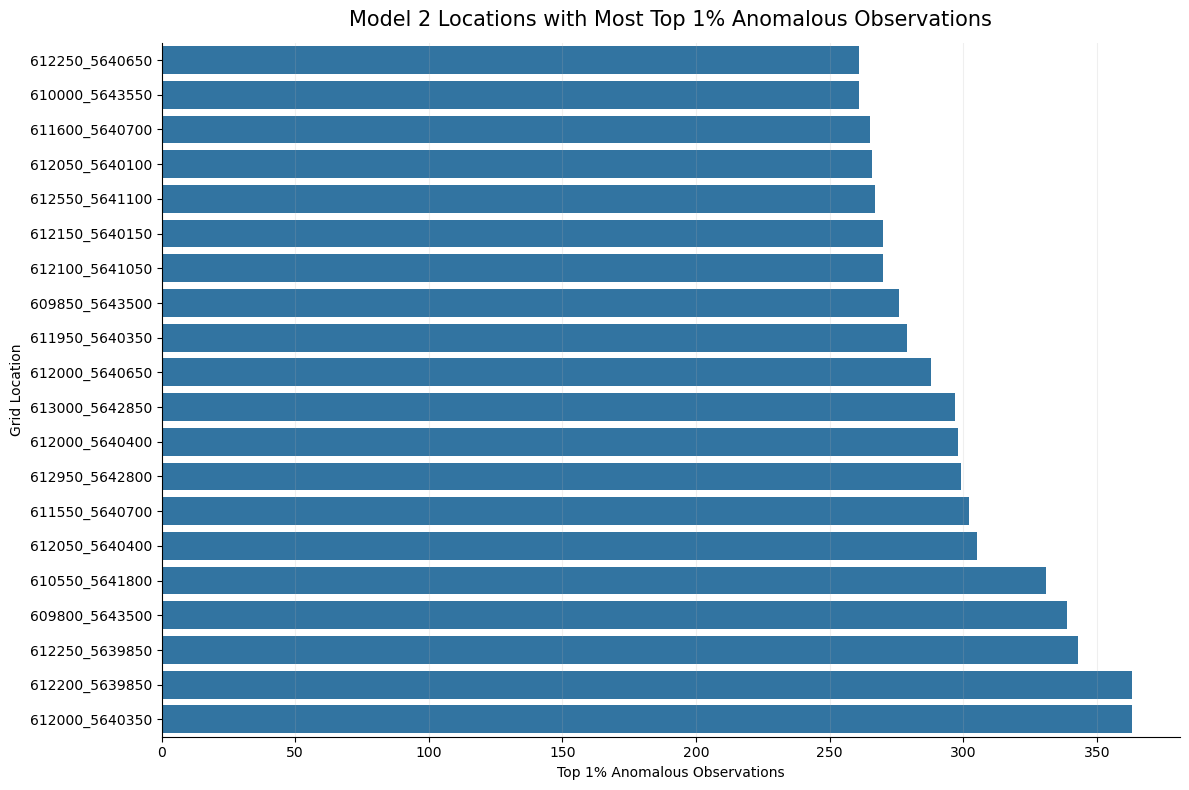

CELL 62 - IDENTIFY THE STRONGEST ANOMALOUS HOURLY LOCATIONS


,location_id,xbin,ybin,observations,top_1_percent_count,anomalous_dates,anomalous_date_hours,mean_top_1_score,maximum_anomaly_score,best_global_rank
0,612200_5639850,612200.0,5639850.0,370,363,4,93,0.617347,0.820762,18
1,612000_5640350,612000.0,5640350.0,369,363,4,95,0.556534,0.813734,33
2,612250_5639850,612250.0,5639850.0,370,343,4,93,0.534413,0.787594,151
3,609800_5643500,609800.0,5643500.0,370,339,4,90,0.552033,0.790665,134
4,610550_5641800,610550.0,5641800.0,370,331,4,90,0.468531,0.681316,1475
5,612050_5640400,612050.0,5640400.0,369,305,4,88,0.457824,0.649547,2254
6,611550_5640700,611550.0,5640700.0,371,302,4,86,0.657008,0.849005,1
7,612950_5642800,612950.0,5642800.0,370,299,4,83,0.508173,0.735057,606
8,612000_5640400,612000.0,5640400.0,369,298,4,86,0.514566,0.767168,325
9,613000_5642850,613000.0,5642850.0,370,297,4,87,0.485991,0.694813,1220



The locations containing the greatest numbers of Top 1% anomalous observations were identified successfully.


In [63]:
# ================================================================
# CELL 62 - IDENTIFY THE STRONGEST ANOMALOUS HOURLY LOCATIONS
# ================================================================

MODEL_HOURLY_STRONG_LOCATION_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_strongest_locations.csv"
)


MODEL_HOURLY_STRONG_LOCATION_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_strongest_locations.png"
)


model_hourly_strong_locations = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_HOURLY_LOCATION_COLUMN}
            AS location_id,

            {MODEL_HOURLY_X_COLUMN}
            AS xbin,

            {MODEL_HOURLY_Y_COLUMN}
            AS ybin,

            COUNT(*) AS observations,

            COUNT(*) FILTER (
                WHERE
                    {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS top_1_percent_count,

            COUNT(
                DISTINCT
                TRY_CAST(
                    {
                        model_hourly_quote_identifier(
                            MODEL_HOURLY_DATE_COLUMN
                        )
                    }
                    AS DATE
                )
            ) FILTER (
                WHERE
                    {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS anomalous_dates,

            COUNT(
                DISTINCT
                (
                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_HOURLY_DATE_COLUMN
                            )
                        }
                        AS DATE
                    ),
                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_HOURLY_HOUR_COLUMN
                            )
                        }
                        AS INTEGER
                    )
                )
            ) FILTER (
                WHERE
                    {MODEL_HOURLY_TOP_1_COLUMN}
            ) AS anomalous_date_hours,

            AVG(
                CASE
                    WHEN
                        {MODEL_HOURLY_TOP_1_COLUMN}

                    THEN
                        {MODEL_HOURLY_SCORE_COLUMN}
                END
            ) AS mean_top_1_score,

            MAX(
                {MODEL_HOURLY_SCORE_COLUMN}
            ) AS maximum_anomaly_score,

            MIN(
                {MODEL_HOURLY_GLOBAL_RANK_COLUMN}
            ) AS best_global_rank

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )

        GROUP BY
            {MODEL_HOURLY_LOCATION_COLUMN},
            {MODEL_HOURLY_X_COLUMN},
            {MODEL_HOURLY_Y_COLUMN}

        HAVING
            COUNT(*) FILTER (
                WHERE
                    {MODEL_HOURLY_TOP_1_COLUMN}
            )
            >
            0

        ORDER BY
            top_1_percent_count DESC,
            best_global_rank ASC

        LIMIT
            100
        """
    )
    .df()
)


model_hourly_strong_locations.to_csv(
    MODEL_HOURLY_STRONG_LOCATION_TABLE,
    index=False
)


model_hourly_strong_locations_plot = (
    model_hourly_strong_locations
    .head(
        20
    )
    .sort_values(
        "top_1_percent_count",
        ascending=True
    )
)


figure, axis = plt.subplots(
    figsize=(
        12,
        8
    )
)


sns.barplot(
    data=model_hourly_strong_locations_plot,
    x="top_1_percent_count",
    y="location_id",
    ax=axis
)


axis.set_title(
    "Model 2 Locations with Most Top 1% Anomalous Observations",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Top 1% Anomalous Observations"
)


axis.set_ylabel(
    "Grid Location"
)


axis.grid(
    axis="x",
    alpha=0.20
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_STRONG_LOCATION_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 62 - IDENTIFY THE STRONGEST "
    "ANOMALOUS HOURLY LOCATIONS"
)
print("=" * 80)


display(
    model_hourly_strong_locations.head(
        20
    )
)


assert len(
    model_hourly_strong_locations
) > 0


assert (
    model_hourly_strong_locations[
        "top_1_percent_count"
    ]
    >
    0
).all()


assert (
    model_hourly_strong_locations[
        "anomalous_date_hours"
    ]
    >
    0
).all()


assert MODEL_HOURLY_STRONG_LOCATION_TABLE.exists()


assert MODEL_HOURLY_STRONG_LOCATION_FIGURE.exists()


print(
    "\nThe locations containing the greatest "
    "numbers of Top 1% anomalous observations "
    "were identified successfully."
)

## What Cell 62 Does

This cell identifies the grid locations containing the greatest numbers of globally Top 1% Model 2 observations.

For each anomalous location, it reports the total observation count, number of Top 1% observations, number of dates on which a Top 1% observation occurred, number of distinct anomalous date × hour combinations, mean Top 1% anomaly score, maximum anomaly score and best global rank.

The accompanying figure ranks the twenty locations with the largest numbers of Top 1% anomalous observations.

The counts in this figure represent individual hourly-model observations rather than distinct hours. Distinct anomalous date × hour combinations are retained separately for later recurrence analysis.

In [64]:
# ================================================================
# CELL 63 - ANALYSE TOP 1% ANOMALY RECURRENCE BY LOCATION
# ================================================================

MODEL_HOURLY_RECURRENCE_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_location_recurrence.csv"
)


model_hourly_location_recurrence = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            location_id,

            COUNT(*) AS total_observations,

            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            ) AS top_1_percent_count,

            COUNT(
                DISTINCT observation_date
            ) FILTER (
                WHERE
                    top_1_percent
            ) AS anomalous_dates,

            COUNT(
                DISTINCT hour_of_day
            ) FILTER (
                WHERE
                    top_1_percent
            ) AS anomalous_hours_of_day,

            COUNT(
                DISTINCT
                (
                    observation_date,
                    hour_of_day
                )
            ) FILTER (
                WHERE
                    top_1_percent
            ) AS anomalous_date_hours,

            MAX(
                anomaly_score
            ) AS maximum_anomaly_score,

            MIN(
                global_rank
            ) AS best_global_rank

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}

        GROUP BY
            location_id

        HAVING
            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            )
            >
            0

        ORDER BY
            top_1_percent_count DESC,
            anomalous_dates DESC,
            best_global_rank ASC
        """
    )
    .df()
)


model_hourly_location_recurrence[
    "top_1_percent_rate"
] = (
    model_hourly_location_recurrence[
        "top_1_percent_count"
    ]
    /
    model_hourly_location_recurrence[
        "total_observations"
    ]
    *
    100.0
)


model_hourly_location_recurrence.to_csv(
    MODEL_HOURLY_RECURRENCE_TABLE,
    index=False
)


print("=" * 80)
print(
    "CELL 63 - ANALYSE TOP 1% "
    "ANOMALY RECURRENCE BY LOCATION"
)
print("=" * 80)


print(
    f"\nLocations appearing in Top 1%: "
    f"{len(model_hourly_location_recurrence):,}"
)


display(
    model_hourly_location_recurrence.head(
        30
    )
)


assert int(
    model_hourly_location_recurrence[
        "top_1_percent_count"
    ].sum()
) == MODEL_HOURLY_TOP_1_PERCENT_ROWS


assert MODEL_HOURLY_RECURRENCE_TABLE.exists()


print(
    "\nLocation-level Top 1% recurrence "
    "was analysed successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 63 - ANALYSE TOP 1% ANOMALY RECURRENCE BY LOCATION

Locations appearing in Top 1%: 21,788


,location_id,total_observations,top_1_percent_count,anomalous_dates,anomalous_hours_of_day,anomalous_date_hours,maximum_anomaly_score,best_global_rank,top_1_percent_rate
0,612200_5639850,370,363,4,24,93,0.820762,18,98.108108
1,612000_5640350,369,363,4,24,95,0.813734,33,98.373984
2,612250_5639850,370,343,4,24,93,0.787594,151,92.702703
3,609800_5643500,370,339,4,24,90,0.790665,134,91.621622
4,610550_5641800,370,331,4,24,90,0.681316,1475,89.459459
5,612050_5640400,369,305,4,24,88,0.649547,2254,82.655827
6,611550_5640700,371,302,4,23,86,0.849005,1,81.401617
7,612950_5642800,370,299,4,24,83,0.735057,606,80.810811
8,612000_5640400,369,298,4,24,86,0.767168,325,80.758808
9,613000_5642850,370,297,4,23,87,0.694813,1220,80.270270



Location-level Top 1% recurrence was analysed successfully.


## What Cell 63 Does

This cell measures how frequently each anomalous grid location recurs.

For every location that appears at least once in the global Top 1%, the analysis records the number of anomalous observations, anomalous dates, distinct anomalous hours of day and distinct date-hour combinations.

The location-specific Top 1% rate is also calculated relative to the complete number of observations available at that location.

This separates locations that appear once because of a single extreme observation from locations showing repeated unusual hourly behaviour.

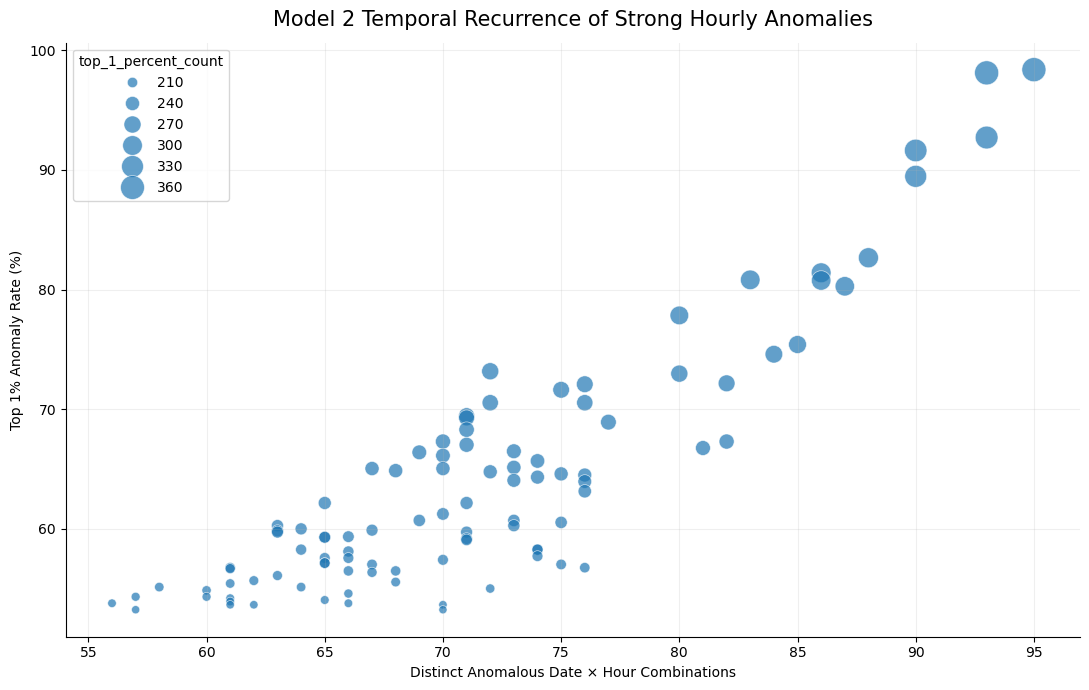

CELL 64 - VISUALISE TEMPORAL RECURRENCE BY LOCATION

Locations displayed: 100
X-axis range: 56 to 95 distinct date-hours
Top 1% anomaly-rate range: 53.2432% to 98.3740%

The temporal recurrence and concentration of strong anomalous locations were visualised successfully.


In [65]:
# ================================================================
# CELL 64 - VISUALISE TEMPORAL RECURRENCE BY LOCATION
# ================================================================

MODEL_HOURLY_LOCATION_RECURRENCE_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_location_recurrence_dates_hours.png"
)


MODEL_HOURLY_LOCATION_RECURRENCE_PLOT_ROWS = min(
    100,
    len(
        model_hourly_location_recurrence
    )
)


model_hourly_location_recurrence_plot = (
    model_hourly_location_recurrence
    .head(
        MODEL_HOURLY_LOCATION_RECURRENCE_PLOT_ROWS
    )
    .copy()
)


figure, axis = plt.subplots(
    figsize=(
        11,
        7
    )
)


sns.scatterplot(
    data=model_hourly_location_recurrence_plot,
    x="anomalous_date_hours",
    y="top_1_percent_rate",
    size="top_1_percent_count",
    sizes=(
        35,
        300
    ),
    alpha=0.70,
    ax=axis
)


axis.set_title(
    "Model 2 Temporal Recurrence of Strong Hourly Anomalies",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Distinct Anomalous Date × Hour Combinations"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.grid(
    alpha=0.20
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_LOCATION_RECURRENCE_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 64 - VISUALISE TEMPORAL "
    "RECURRENCE BY LOCATION"
)
print("=" * 80)


print(
    f"\nLocations displayed: "
    f"{MODEL_HOURLY_LOCATION_RECURRENCE_PLOT_ROWS:,}"
)


print(
    "X-axis range: "
    f"{model_hourly_location_recurrence_plot['anomalous_date_hours'].min():,}"
    " to "
    f"{model_hourly_location_recurrence_plot['anomalous_date_hours'].max():,}"
    " distinct date-hours"
)


print(
    "Top 1% anomaly-rate range: "
    f"{model_hourly_location_recurrence_plot['top_1_percent_rate'].min():.4f}%"
    " to "
    f"{model_hourly_location_recurrence_plot['top_1_percent_rate'].max():.4f}%"
)


assert MODEL_HOURLY_LOCATION_RECURRENCE_PLOT_ROWS > 0


assert (
    model_hourly_location_recurrence_plot[
        "anomalous_date_hours"
    ]
    >
    0
).all()


assert MODEL_HOURLY_LOCATION_RECURRENCE_FIGURE.exists()


print(
    "\nThe temporal recurrence and concentration "
    "of strong anomalous locations were "
    "visualised successfully."
)

## What Cell 64 Does

This cell visualises recurrence among the strongest Top 1% anomalous locations.

The horizontal axis measures the number of distinct date × hour combinations in which each location appears in the global Top 1%. This directly measures how widely the anomaly recurs through the available hourly timeline.

The vertical axis gives the percentage of all observations at the location that fall within the global Top 1%, while marker size represents the absolute number of Top 1% observations.

This is more informative for the current four-date dataset than plotting anomalous-date count alone, because many of the strongest locations appear on all four available dates.

In [66]:
# ================================================================
# CELL 65 - DETECT CONSECUTIVE TOP 1% ANOMALOUS-HOUR STREAKS
# ================================================================

MODEL_HOURLY_STREAK_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_anomalous_hour_streaks.csv"
)


model_hourly_anomalous_streaks = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        WITH anomalous_hours AS (
            SELECT DISTINCT
                location_id,

                observation_date,

                hour_of_day,

                CAST(
                    observation_date
                    AS TIMESTAMP
                )
                +
                hour_of_day
                *
                INTERVAL '1 hour'
                AS observation_hour

            FROM
                {MODEL_HOURLY_TEMPORAL_VIEW}

            WHERE
                top_1_percent
        ),

        ordered_hours AS (
            SELECT
                *,

                ROW_NUMBER()
                OVER (
                    PARTITION BY
                        location_id

                    ORDER BY
                        observation_hour
                ) AS sequence_number

            FROM
                anomalous_hours
        ),

        streak_groups AS (
            SELECT
                *,

                (
                    CAST(
                        EPOCH(
                            observation_hour
                        )
                        /
                        3600
                        AS BIGINT
                    )
                    -
                    sequence_number
                ) AS streak_group

            FROM
                ordered_hours
        )

        SELECT
            location_id,

            MIN(
                observation_hour
            ) AS streak_start,

            MAX(
                observation_hour
            ) AS streak_end,

            COUNT(*) AS consecutive_hours

        FROM
            streak_groups

        GROUP BY
            location_id,
            streak_group

        ORDER BY
            consecutive_hours DESC,
            streak_start,
            location_id
        """
    )
    .df()
)


model_hourly_anomalous_streaks.to_csv(
    MODEL_HOURLY_STREAK_TABLE,
    index=False
)


MODEL_HOURLY_MAXIMUM_STREAK = int(
    model_hourly_anomalous_streaks[
        "consecutive_hours"
    ].max()
)


print("=" * 80)
print(
    "CELL 65 - DETECT CONSECUTIVE "
    "TOP 1% ANOMALOUS-HOUR STREAKS"
)
print("=" * 80)


print(
    f"\nDetected streaks      : "
    f"{len(model_hourly_anomalous_streaks):,}"
)


print(
    f"Longest streak        : "
    f"{MODEL_HOURLY_MAXIMUM_STREAK:,} hours"
)


display(
    model_hourly_anomalous_streaks.head(
        30
    )
)


assert len(
    model_hourly_anomalous_streaks
) > 0


assert (
    model_hourly_anomalous_streaks[
        "consecutive_hours"
    ]
    >=
    1
).all()


assert MODEL_HOURLY_STREAK_TABLE.exists()


print(
    "\nConsecutive Top 1% anomalous-hour "
    "streaks were detected successfully."
)

CELL 65 - DETECT CONSECUTIVE TOP 1% ANOMALOUS-HOUR STREAKS

Detected streaks      : 55,903
Longest streak        : 62 hours


,location_id,streak_start,streak_end,consecutive_hours
0,612000_5640350,2026-07-14 00:00:00,2026-07-16 13:00:00,62
1,612200_5639850,2026-07-14 00:00:00,2026-07-16 13:00:00,62
2,612250_5639850,2026-07-14 00:00:00,2026-07-16 13:00:00,62
3,612050_5640400,2026-07-14 00:00:00,2026-07-15 23:00:00,48
4,612050_5640450,2026-07-14 00:00:00,2026-07-15 20:00:00,45
5,610250_5642450,2026-07-14 00:00:00,2026-07-15 19:00:00,44
6,609800_5643500,2026-07-14 00:00:00,2026-07-15 18:00:00,43
7,610550_5641800,2026-07-14 00:00:00,2026-07-15 18:00:00,43
8,612000_5640400,2026-07-14 05:00:00,2026-07-15 23:00:00,43
9,609850_5643500,2026-07-14 03:00:00,2026-07-15 18:00:00,40



Consecutive Top 1% anomalous-hour streaks were detected successfully.


## What Cell 65 Does

This cell identifies consecutive hours during which the same grid location remains within the global Top 1% anomaly population.

The calculation uses complete hourly timestamps, so a streak can continue correctly across midnight when consecutive dates are available.

A one-hour result represents an isolated anomalous hour, whereas longer streaks indicate sustained unusual behaviour at the same location.

This adds an important persistence measure that cannot be obtained from the daily Model 1 analysis.

In [67]:
# ================================================================
# CELL 66 - RANK AND SUMMARISE PERSISTENT HOURLY LOCATIONS
# ================================================================

MODEL_HOURLY_PERSISTENT_LOCATION_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_persistent_locations.csv"
)


model_hourly_location_max_streak = (
    model_hourly_anomalous_streaks
    .groupby(
        "location_id",
        as_index=False
    )[
        "consecutive_hours"
    ]
    .max()
    .rename(
        columns={
            "consecutive_hours": (
                "maximum_consecutive_hours"
            )
        }
    )
)


model_hourly_persistent_locations = (
    model_hourly_location_recurrence
    .merge(
        model_hourly_location_max_streak,
        on="location_id",
        how="left"
    )
)


model_hourly_persistent_locations[
    "maximum_consecutive_hours"
] = (
    model_hourly_persistent_locations[
        "maximum_consecutive_hours"
    ]
    .fillna(
        0
    )
    .astype(
        int
    )
)


model_hourly_persistent_locations = (
    model_hourly_persistent_locations
    .sort_values(
        [
            "anomalous_dates",
            "top_1_percent_count",
            "maximum_consecutive_hours",
            "best_global_rank"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


model_hourly_persistent_locations.insert(
    0,
    "persistence_rank",
    np.arange(
        1,
        len(
            model_hourly_persistent_locations
        )
        +
        1
    )
)


model_hourly_persistent_locations.to_csv(
    MODEL_HOURLY_PERSISTENT_LOCATION_TABLE,
    index=False
)


print("=" * 80)
print(
    "CELL 66 - RANK AND SUMMARISE "
    "PERSISTENT HOURLY LOCATIONS"
)
print("=" * 80)


display(
    model_hourly_persistent_locations.head(
        30
    )
)


assert len(
    model_hourly_persistent_locations
) == len(
    model_hourly_location_recurrence
)


assert MODEL_HOURLY_PERSISTENT_LOCATION_TABLE.exists()


print(
    "\nSection 14 is complete. Persistent "
    "hourly anomaly locations were ranked successfully."
)

CELL 66 - RANK AND SUMMARISE PERSISTENT HOURLY LOCATIONS


,persistence_rank,location_id,total_observations,top_1_percent_count,anomalous_dates,anomalous_hours_of_day,anomalous_date_hours,maximum_anomaly_score,best_global_rank,top_1_percent_rate,maximum_consecutive_hours
0,1,612200_5639850,370,363,4,24,93,0.820762,18,98.108108,62
1,2,612000_5640350,369,363,4,24,95,0.813734,33,98.373984,62
2,3,612250_5639850,370,343,4,24,93,0.787594,151,92.702703,62
3,4,609800_5643500,370,339,4,24,90,0.790665,134,91.621622,43
4,5,610550_5641800,370,331,4,24,90,0.681316,1475,89.459459,43
5,6,612050_5640400,369,305,4,24,88,0.649547,2254,82.655827,48
6,7,611550_5640700,371,302,4,23,86,0.849005,1,81.401617,22
7,8,612950_5642800,370,299,4,24,83,0.735057,606,80.810811,22
8,9,612000_5640400,369,298,4,24,86,0.767168,325,80.758808,43
9,10,613000_5642850,370,297,4,23,87,0.694813,1220,80.270270,23



Section 14 is complete. Persistent hourly anomaly locations were ranked successfully.


## What Cell 66 Does

This cell combines the principal recurrence measures into one persistent-location table.

Locations are ordered first by the number of anomalous dates, then by their total Top 1% frequency, longest consecutive anomalous-hour streak and strongest global anomaly rank.

The resulting persistence rank is descriptive rather than a second machine-learning score.

Its purpose is to identify useful locations for subsequent POI investigation and detailed hourly case studies.

Section 14 is complete.

# 15. Hourly POI Context and Case Study

This section uses the contextual POI variables added after anomaly detection to investigate the environments associated with strong hourly anomalies.

POI information remains entirely separate from Isolation Forest training.

The section compares POI characteristics between strong anomalies and the wider population, summarises POI context across the Top 100, Top 1,000 and Top 10,000 outputs, constructs hourly profiles for selected persistent locations and attempts a direct comparison with the corresponding daily Model 1 results.

All POI and daily-model analyses remain descriptive and are used to interpret rather than redefine the Model 2 anomaly ranking.

In [68]:
# ================================================================
# CELL 67 - COMPARE TOP 1% AND NON-TOP-1% POI CONTEXT
# ================================================================

MODEL_HOURLY_POI_CONTEXT_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_top_1_poi_context.csv"
)


final_ranked_schema = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        DESCRIBE
        SELECT
            *

        FROM read_parquet(
            [
                {final_ranked_file_sql}
            ],
            union_by_name = true
        )
        """
    )
    .df()
)


model_hourly_final_type_map = dict(
    zip(
        final_ranked_schema[
            "column_name"
        ],
        final_ranked_schema[
            "column_type"
        ]
    )
)


MODEL_HOURLY_NUMERIC_POI_COLUMNS = [
    column_name
    for column_name
    in MODEL_HOURLY_POI_OUTPUT_COLUMNS
    if any(
        numeric_type
        in
        str(
            model_hourly_final_type_map.get(
                column_name,
                ""
            )
        ).upper()
        for numeric_type
        in [
            "INT",
            "DOUBLE",
            "FLOAT",
            "DECIMAL",
            "REAL",
            "HUGEINT"
        ]
    )
]


poi_context_records = []


for poi_column in (
    MODEL_HOURLY_NUMERIC_POI_COLUMNS
):

    quoted_poi_column = (
        model_hourly_quote_identifier(
            poi_column
        )
    )


    poi_result = (
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            SELECT
                AVG(
                    CASE
                        WHEN
                            {MODEL_HOURLY_TOP_1_COLUMN}

                        THEN
                            TRY_CAST(
                                {quoted_poi_column}
                                AS DOUBLE
                            )
                    END
                ) AS top_1_mean,

                AVG(
                    CASE
                        WHEN
                            NOT
                            {MODEL_HOURLY_TOP_1_COLUMN}

                        THEN
                            TRY_CAST(
                                {quoted_poi_column}
                                AS DOUBLE
                            )
                    END
                ) AS remaining_mean,

                COUNT(*) FILTER (
                    WHERE
                        {MODEL_HOURLY_TOP_1_COLUMN}
                        AND
                        TRY_CAST(
                            {quoted_poi_column}
                            AS DOUBLE
                        )
                        !=
                        0
                ) AS top_1_nonzero,

                COUNT(*) FILTER (
                    WHERE
                        NOT
                        {MODEL_HOURLY_TOP_1_COLUMN}
                        AND
                        TRY_CAST(
                            {quoted_poi_column}
                            AS DOUBLE
                        )
                        !=
                        0
                ) AS remaining_nonzero

            FROM read_parquet(
                [
                    {final_ranked_file_sql}
                ],
                union_by_name = true
            )
            """
        )
        .fetchone()
    )


    top_1_mean = (
        np.nan
        if poi_result[
            0
        ] is None
        else float(
            poi_result[
                0
            ]
        )
    )


    remaining_mean = (
        np.nan
        if poi_result[
            1
        ] is None
        else float(
            poi_result[
                1
            ]
        )
    )


    top_1_nonzero_rate = (
        float(
            poi_result[
                2
            ]
        )
        /
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
        *
        100.0
    )


    remaining_rows = (
        MODEL_HOURLY_TOTAL_ROWS
        -
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
    )


    remaining_nonzero_rate = (
        float(
            poi_result[
                3
            ]
        )
        /
        remaining_rows
        *
        100.0
    )


    poi_context_records.append(
        {
            "POI Field": (
                poi_column
            ),
            "Top 1% Mean": (
                top_1_mean
            ),
            "Remaining Mean": (
                remaining_mean
            ),
            "Top 1% Non-Zero Rate (%)": (
                top_1_nonzero_rate
            ),
            "Remaining Non-Zero Rate (%)": (
                remaining_nonzero_rate
            ),
            "Non-Zero Rate Difference": (
                top_1_nonzero_rate
                -
                remaining_nonzero_rate
            )
        }
    )


model_hourly_poi_context = pd.DataFrame(
    poi_context_records
)


if len(
    model_hourly_poi_context
) > 0:

    model_hourly_poi_context[
        "Absolute Non-Zero Difference"
    ] = (
        model_hourly_poi_context[
            "Non-Zero Rate Difference"
        ]
        .abs()
    )


    model_hourly_poi_context = (
        model_hourly_poi_context
        .sort_values(
            "Absolute Non-Zero Difference",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


model_hourly_poi_context.to_csv(
    MODEL_HOURLY_POI_CONTEXT_TABLE,
    index=False
)


print("=" * 80)
print(
    "CELL 67 - COMPARE TOP 1% AND "
    "NON-TOP-1% POI CONTEXT"
)
print("=" * 80)


print(
    f"\nNumeric POI fields analysed: "
    f"{len(MODEL_HOURLY_NUMERIC_POI_COLUMNS):,}"
)


display(
    model_hourly_poi_context.head(
        30
    )
)


assert MODEL_HOURLY_POI_CONTEXT_TABLE.exists()


print(
    "\nTop 1% and wider-population POI "
    "context were compared successfully."
)

CELL 67 - COMPARE TOP 1% AND NON-TOP-1% POI CONTEXT

Numeric POI fields analysed: 26


,POI Field,Top 1% Mean,Remaining Mean,Top 1% Non-Zero Rate (%),Remaining Non-Zero Rate (%),Non-Zero Rate Difference,Absolute Non-Zero Difference
0,nearest_airports_distance,7092.679328,8392.658983,100.0,100.0,0.0,0.0
1,nearest_attractions_distance,1846.904876,2507.841841,100.0,100.0,0.0,0.0
2,nearest_beaches_distance,2107.314548,2351.779840,100.0,100.0,0.0,0.0
3,nearest_bus_stations_distance,3294.065165,5440.518874,100.0,100.0,0.0,0.0
4,nearest_bus_stops_distance,182.689002,333.274618,100.0,100.0,0.0,0.0
5,nearest_cafes_distance,464.545903,900.205759,100.0,100.0,0.0,0.0
6,nearest_fast_foods_distance,534.563798,1053.901335,100.0,100.0,0.0,0.0
7,nearest_gyms_distance,1306.027015,2401.703353,100.0,100.0,0.0,0.0
8,nearest_holiday_parks_distance,3802.268498,3131.707784,100.0,100.0,0.0,0.0
9,nearest_hospitals_distance,1751.393552,2517.113889,100.0,100.0,0.0,0.0



Top 1% and wider-population POI context were compared successfully.


## What Cell 67 Does

This cell compares numeric POI context between the globally strongest Top 1% hourly anomalies and all remaining observations.

The POI fields are detected dynamically from the final enriched schema, so additional numeric Notebook 2 POI features can be incorporated without manually rewriting this analysis.

For each numeric POI variable, the cell compares its mean value and the proportion of observations with a non-zero value.

These differences are descriptive associations only. They do not imply that a POI caused an anomaly and they do not affect the Isolation Forest ranking.

In [69]:
# ================================================================
# CELL 68 - SUMMARISE POI CONTEXT ACROSS SELECTED ANOMALY OUTPUTS
# ================================================================

MODEL_HOURLY_SELECTED_POI_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_selected_output_poi_summary.csv"
)


selected_poi_datasets = {
    "Top 100": (
        model_hourly_top_100
    ),
    "Top 1,000": (
        model_hourly_top_1000
    ),
    "Top 10,000": (
        model_hourly_top_10000
    )
}


selected_poi_summary_records = []


for output_name, output_data in (
    selected_poi_datasets.items()
):

    for poi_column in (
        MODEL_HOURLY_NUMERIC_POI_COLUMNS
    ):

        numeric_values = pd.to_numeric(
            output_data[
                poi_column
            ],
            errors="coerce"
        )


        valid_values = (
            numeric_values
            .notna()
        )


        nonzero_values = (
            numeric_values
            .fillna(
                0
            )
            !=
            0
        )


        selected_poi_summary_records.append(
            {
                "Output": (
                    output_name
                ),
                "POI Field": (
                    poi_column
                ),
                "Observations": (
                    len(
                        output_data
                    )
                ),
                "Valid Values": int(
                    valid_values.sum()
                ),
                "Mean": (
                    numeric_values.mean()
                ),
                "Non-Zero Count": int(
                    nonzero_values.sum()
                ),
                "Non-Zero Rate (%)": (
                    nonzero_values.mean()
                    *
                    100.0
                )
            }
        )


model_hourly_selected_poi_summary = pd.DataFrame(
    selected_poi_summary_records
)


model_hourly_selected_poi_summary.to_csv(
    MODEL_HOURLY_SELECTED_POI_TABLE,
    index=False
)


print("=" * 80)
print(
    "CELL 68 - SUMMARISE POI CONTEXT "
    "ACROSS SELECTED ANOMALY OUTPUTS"
)
print("=" * 80)


display(
    model_hourly_selected_poi_summary
    .sort_values(
        [
            "Output",
            "Non-Zero Rate (%)"
        ],
        ascending=[
            True,
            False
        ]
    )
    .head(
        60
    )
)


assert set(
    model_hourly_selected_poi_summary[
        "Output"
    ]
) == set(
    selected_poi_datasets.keys()
)


assert MODEL_HOURLY_SELECTED_POI_TABLE.exists()


print(
    "\nPOI context across the Top 100, "
    "Top 1,000 and Top 10,000 was summarised successfully."
)

CELL 68 - SUMMARISE POI CONTEXT ACROSS SELECTED ANOMALY OUTPUTS


,Output,POI Field,Observations,Valid Values,Mean,Non-Zero Count,Non-Zero Rate (%)
26,"Top 1,000",nearest_airports_distance,1000,1000,6477.810091,1000,100.0
27,"Top 1,000",nearest_attractions_distance,1000,1000,622.529829,1000,100.0
28,"Top 1,000",nearest_beaches_distance,1000,1000,1852.598861,1000,100.0
29,"Top 1,000",nearest_bus_stations_distance,1000,1000,865.567944,1000,100.0
30,"Top 1,000",nearest_bus_stops_distance,1000,1000,75.410708,1000,100.0
31,"Top 1,000",nearest_cafes_distance,1000,1000,118.313751,1000,100.0
32,"Top 1,000",nearest_fast_foods_distance,1000,1000,118.786044,1000,100.0
33,"Top 1,000",nearest_gyms_distance,1000,1000,294.675455,1000,100.0
34,"Top 1,000",nearest_holiday_parks_distance,1000,1000,4395.345462,1000,100.0
35,"Top 1,000",nearest_hospitals_distance,1000,1000,1211.073478,1000,100.0



POI context across the Top 100, Top 1,000 and Top 10,000 was summarised successfully.


## What Cell 68 Does

This cell compares the contextual POI fields across the Top 100, Top 1,000 and Top 10,000 Model 2 anomaly outputs.

The same dynamically identified numeric POI variables are evaluated at each anomaly-strength level.

This makes it possible to determine whether particular contextual characteristics are concentrated only among the most extreme anomalies or remain visible across a broader anomaly population.

The original selected anomaly files remain unchanged.

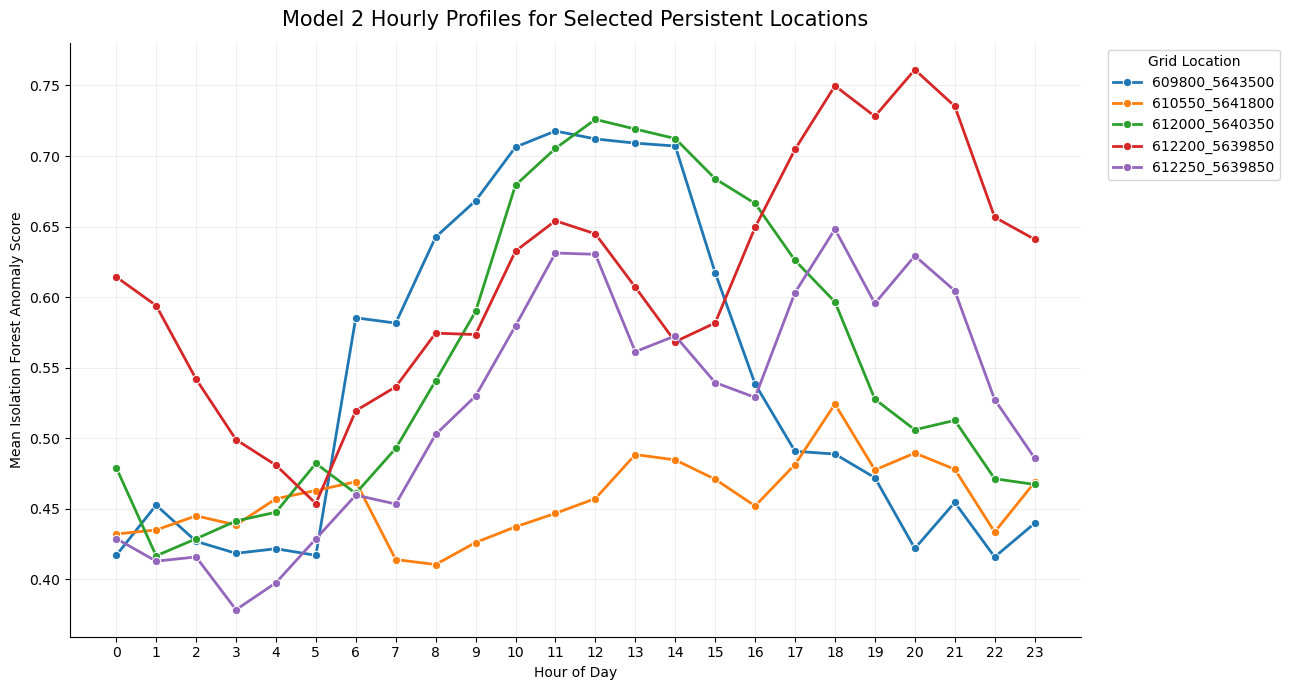

CELL 69 - BUILD SELECTED ANOMALOUS-LOCATION HOURLY PROFILES

Selected locations: 5


,location_id,hour_of_day,observations,mean_anomaly_score,maximum_anomaly_score,top_1_percent_rate
0,609800_5643500,0,16,0.416961,0.531096,81.250000
1,609800_5643500,1,16,0.452585,0.675901,81.250000
2,609800_5643500,2,16,0.426935,0.548207,75.000000
3,609800_5643500,3,16,0.418437,0.525239,75.000000
4,609800_5643500,4,16,0.421701,0.509213,93.750000
5,609800_5643500,5,16,0.417012,0.489870,87.500000
6,609800_5643500,6,16,0.585362,0.652566,100.000000
7,609800_5643500,7,16,0.581599,0.657958,93.750000
8,609800_5643500,8,16,0.642561,0.712543,93.750000
9,609800_5643500,9,16,0.668280,0.728760,100.000000



Selected persistent-location hourly profiles were created successfully.


In [70]:
# ================================================================
# CELL 69 - BUILD SELECTED ANOMALOUS-LOCATION HOURLY PROFILES
# ================================================================

MODEL_HOURLY_PROFILE_LOCATION_COUNT = min(
    5,
    len(
        model_hourly_persistent_locations
    )
)


MODEL_HOURLY_PROFILE_LOCATIONS = (
    model_hourly_persistent_locations[
        "location_id"
    ]
    .head(
        MODEL_HOURLY_PROFILE_LOCATION_COUNT
    )
    .tolist()
)


MODEL_HOURLY_LOCATION_PROFILE_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_selected_location_profiles.csv"
)


MODEL_HOURLY_LOCATION_PROFILE_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_selected_location_profiles.png"
)


profile_location_sql = ", ".join(
    [
        "'"
        +
        str(
            location_id
        )
        .replace(
            "'",
            "''"
        )
        +
        "'"
        for location_id
        in MODEL_HOURLY_PROFILE_LOCATIONS
    ]
)


model_hourly_selected_profiles = (
    MODEL_HOURLY_CONNECTION.execute(
        f"""
        SELECT
            location_id,

            hour_of_day,

            COUNT(*) AS observations,

            AVG(
                anomaly_score
            ) AS mean_anomaly_score,

            MAX(
                anomaly_score
            ) AS maximum_anomaly_score,

            COUNT(*) FILTER (
                WHERE
                    top_1_percent
            )
            /
            CAST(
                COUNT(*)
                AS DOUBLE
            )
            *
            100.0
            AS top_1_percent_rate

        FROM
            {MODEL_HOURLY_TEMPORAL_VIEW}

        WHERE
            location_id
            IN (
                {profile_location_sql}
            )

        GROUP BY
            location_id,
            hour_of_day

        ORDER BY
            location_id,
            hour_of_day
        """
    )
    .df()
)


model_hourly_selected_profiles.to_csv(
    MODEL_HOURLY_LOCATION_PROFILE_TABLE,
    index=False
)


figure, axis = plt.subplots(
    figsize=(
        13,
        7
    )
)


sns.lineplot(
    data=model_hourly_selected_profiles,
    x="hour_of_day",
    y="mean_anomaly_score",
    hue="location_id",
    marker="o",
    linewidth=2.0,
    ax=axis
)


axis.set_title(
    "Model 2 Hourly Profiles for Selected Persistent Locations",
    fontsize=15,
    pad=12
)


axis.set_xlabel(
    "Hour of Day"
)


axis.set_ylabel(
    "Mean Isolation Forest Anomaly Score"
)


axis.set_xticks(
    sorted(
        model_hourly_selected_profiles[
            "hour_of_day"
        ]
        .unique()
    )
)


axis.grid(
    alpha=0.20
)


axis.legend(
    title="Grid Location",
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)


sns.despine()


figure.tight_layout()


figure.savefig(
    MODEL_HOURLY_LOCATION_PROFILE_FIGURE,
    dpi=MODEL_HOURLY_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print(
    "CELL 69 - BUILD SELECTED "
    "ANOMALOUS-LOCATION HOURLY PROFILES"
)
print("=" * 80)


print(
    f"\nSelected locations: "
    f"{MODEL_HOURLY_PROFILE_LOCATION_COUNT:,}"
)


display(
    model_hourly_selected_profiles.head(
        30
    )
)


assert (
    model_hourly_selected_profiles[
        "location_id"
    ]
    .nunique()
) == MODEL_HOURLY_PROFILE_LOCATION_COUNT


assert MODEL_HOURLY_LOCATION_PROFILE_TABLE.exists()


assert MODEL_HOURLY_LOCATION_PROFILE_FIGURE.exists()


print(
    "\nSelected persistent-location hourly "
    "profiles were created successfully."
)

## What Cell 69 Does

This cell constructs representative hourly profiles for the highest-ranked persistent anomaly locations.

The selected locations come directly from the recurrence and streak analysis rather than being chosen manually.

For each location and hour of day, the profile records observation count, mean anomaly score, maximum anomaly score and Top 1% anomaly rate.

These profiles provide suitable starting points for dissertation case studies because they show how unusual behaviour changes within the day at repeatedly anomalous locations.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

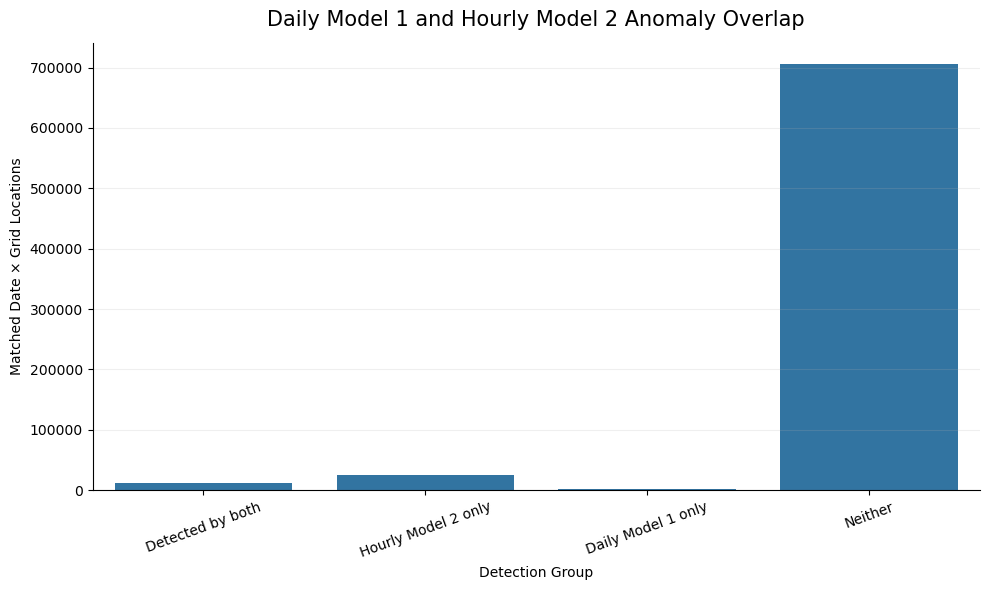

CELL 70 - COMPARE HOURLY MODEL 2 WITH CORRESPONDING DAILY MODEL 1

Model 1 Top 1% definition : Global anomaly rank
Model 1 ranked observations: 119,267,039
Model 1 Top 1% rank limit : 1,192,671

Matched date × grid locations: 743,801
Matched Model 1 Top 1% locations: 13,326
Matched Model 2 Top 1% locations: 36,750


,comparison_group,observations
0,Detected by both,12235
1,Hourly Model 2 only,24515
2,Daily Model 1 only,1091
3,Neither,705960



Daily Model 1 and hourly Model 2 were compared successfully on their common dates and grid locations.

Section 15 is complete.


In [71]:
# ================================================================
# CELL 70 - COMPARE HOURLY MODEL 2 WITH CORRESPONDING DAILY MODEL 1
# ================================================================

MODEL_1_FOLDER = (
    MODEL_2_PROJECT_FOLDER
    /
    "model_1"
)


MODEL_1_RANKED_FOLDER = (
    MODEL_1_FOLDER
    /
    "daily_ranked_partitions"
)


MODEL_HOURLY_MODEL_1_COMPARISON_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_vs_model_1_comparison.csv"
)


MODEL_HOURLY_MODEL_1_OVERLAP_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_vs_model_1_overlap_summary.csv"
)


MODEL_HOURLY_MODEL_1_FIGURE = (
    MODEL_HOURLY_FIGURES_FOLDER
    /
    "model_hourly_vs_model_1_overlap.png"
)


model_1_ranked_files = sorted(
    MODEL_1_RANKED_FOLDER.glob(
        "*.parquet"
    )
)


MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE = (
    len(
        model_1_ranked_files
    )
    >
    0
)


model_hourly_vs_model_1 = pd.DataFrame()


model_hourly_model_1_overlap = pd.DataFrame()


MODEL_1_DATE_COLUMN = None
MODEL_1_X_COLUMN = None
MODEL_1_Y_COLUMN = None
MODEL_1_SCORE_COLUMN = None
MODEL_1_GLOBAL_RANK_COLUMN = None
MODEL_1_TOP_1_COLUMN = None

MODEL_1_TOTAL_RANKED_ROWS = 0
MODEL_1_TOP_1_ROWS = 0
MODEL_1_TOP_1_DEFINITION = None


def model_hourly_find_column(
    columns,
    preferred_names,
    required_terms=None
):

    normalized_map = {
        str(
            column_name
        )
        .lower()
        .replace(
            "_",
            ""
        )
        .replace(
            " ",
            ""
        ): (
            column_name
        )
        for column_name
        in columns
    }


    for preferred_name in preferred_names:

        normalized_preferred = (
            preferred_name
            .lower()
            .replace(
                "_",
                ""
            )
            .replace(
                " ",
                ""
            )
        )


        if (
            normalized_preferred
            in
            normalized_map
        ):

            return normalized_map[
                normalized_preferred
            ]


    if required_terms is not None:

        for column_name in columns:

            normalized_name = (
                str(
                    column_name
                )
                .lower()
                .replace(
                    "_",
                    ""
                )
                .replace(
                    " ",
                    ""
                )
            )


            if all(
                str(
                    term
                )
                .lower()
                .replace(
                    "_",
                    ""
                )
                .replace(
                    " ",
                    ""
                )
                in
                normalized_name
                for term
                in required_terms
            ):

                return column_name


    return None


if MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE:

    model_1_schema_columns = (
        pq.ParquetFile(
            model_1_ranked_files[
                0
            ]
        )
        .schema
        .names
    )


    MODEL_1_DATE_COLUMN = (
        model_hourly_find_column(
            model_1_schema_columns,
            [
                "en_dt",
                "observation_date",
                "date"
            ]
        )
    )


    MODEL_1_X_COLUMN = (
        model_hourly_find_column(
            model_1_schema_columns,
            [
                "xbin"
            ]
        )
    )


    MODEL_1_Y_COLUMN = (
        model_hourly_find_column(
            model_1_schema_columns,
            [
                "ybin"
            ]
        )
    )


    MODEL_1_SCORE_COLUMN = (
        model_hourly_find_column(
            model_1_schema_columns,
            [
                "model_1_anomaly_score",
                "anomaly_score"
            ],
            required_terms=[
                "anomaly",
                "score"
            ]
        )
    )


    MODEL_1_GLOBAL_RANK_COLUMN = (
        model_hourly_find_column(
            model_1_schema_columns,
            [
                "model_1_global_anomaly_rank",
                "global_anomaly_rank",
                "global_rank"
            ],
            required_terms=[
                "global",
                "rank"
            ]
        )
    )


    MODEL_1_TOP_1_COLUMN = (
        model_hourly_find_column(
            model_1_schema_columns,
            [
                "model_1_top_1_percent",
                "top_1_percent",
                "top_1"
            ],
            required_terms=[
                "top",
                "1"
            ]
        )
    )


    required_model_1_columns = [
        MODEL_1_DATE_COLUMN,
        MODEL_1_X_COLUMN,
        MODEL_1_Y_COLUMN,
        MODEL_1_SCORE_COLUMN
    ]


    model_1_top_definition_available = (
        MODEL_1_GLOBAL_RANK_COLUMN
        is not None
        or
        MODEL_1_TOP_1_COLUMN
        is not None
    )


    MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE = (
        all(
            column_name
            is not None
            for column_name
            in required_model_1_columns
        )
        and
        model_1_top_definition_available
    )


if MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE:

    model_1_file_sql = ",\n".join(
        [
            (
                "'"
                +
                file_path
                .resolve()
                .as_posix()
                .replace(
                    "'",
                    "''"
                )
                +
                "'"
            )
            for file_path
            in model_1_ranked_files
        ]
    )


    if MODEL_1_GLOBAL_RANK_COLUMN is not None:

        MODEL_1_TOTAL_RANKED_ROWS = int(
            MODEL_HOURLY_CONNECTION.execute(
                f"""
                SELECT
                    MAX(
                        TRY_CAST(
                            {
                                model_hourly_quote_identifier(
                                    MODEL_1_GLOBAL_RANK_COLUMN
                                )
                            }
                            AS BIGINT
                        )
                    )

                FROM read_parquet(
                    [
                        {model_1_file_sql}
                    ],
                    union_by_name = true
                )
                """
            )
            .fetchone()[0]
        )


        MODEL_1_TOP_1_ROWS = max(
            1,
            (
                MODEL_1_TOTAL_RANKED_ROWS
                +
                99
            )
            //
            100
        )


        model_1_top_expression = (
            f"TRY_CAST("
            f"{model_hourly_quote_identifier(MODEL_1_GLOBAL_RANK_COLUMN)} "
            f"AS BIGINT) "
            f"<= "
            f"{MODEL_1_TOP_1_ROWS}"
        )


        MODEL_1_TOP_1_DEFINITION = (
            "Global anomaly rank"
        )


    else:

        model_1_top_expression = (
            f"COALESCE("
            f"TRY_CAST("
            f"{model_hourly_quote_identifier(MODEL_1_TOP_1_COLUMN)} "
            f"AS BOOLEAN"
            f"), "
            f"FALSE"
            f")"
        )


        MODEL_1_TOP_1_DEFINITION = (
            "Existing Top 1% boolean field"
        )


    model_hourly_vs_model_1 = (
        MODEL_HOURLY_CONNECTION.execute(
            f"""
            WITH hourly_daily AS (
                SELECT
                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_HOURLY_DATE_COLUMN
                            )
                        }
                        AS DATE
                    ) AS observation_date,

                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_HOURLY_X_COLUMN
                            )
                        }
                        AS DOUBLE
                    ) AS xbin,

                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_HOURLY_Y_COLUMN
                            )
                        }
                        AS DOUBLE
                    ) AS ybin,

                    MAX(
                        {MODEL_HOURLY_SCORE_COLUMN}
                    ) AS maximum_hourly_score,

                    BOOL_OR(
                        {MODEL_HOURLY_TOP_1_COLUMN}
                    ) AS any_hourly_top_1,

                    COUNT(*) FILTER (
                        WHERE
                            {MODEL_HOURLY_TOP_1_COLUMN}
                    ) AS hourly_top_1_count

                FROM read_parquet(
                    [
                        {final_ranked_file_sql}
                    ],
                    union_by_name = true
                )

                GROUP BY
                    observation_date,
                    xbin,
                    ybin
            ),

            daily_model_1 AS (
                SELECT
                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_1_DATE_COLUMN
                            )
                        }
                        AS DATE
                    ) AS observation_date,

                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_1_X_COLUMN
                            )
                        }
                        AS DOUBLE
                    ) AS xbin,

                    TRY_CAST(
                        {
                            model_hourly_quote_identifier(
                                MODEL_1_Y_COLUMN
                            )
                        }
                        AS DOUBLE
                    ) AS ybin,

                    MAX(
                        TRY_CAST(
                            {
                                model_hourly_quote_identifier(
                                    MODEL_1_SCORE_COLUMN
                                )
                            }
                            AS DOUBLE
                        )
                    ) AS model_1_score,

                    BOOL_OR(
                        {model_1_top_expression}
                    ) AS model_1_top_1

                FROM read_parquet(
                    [
                        {model_1_file_sql}
                    ],
                    union_by_name = true
                )

                GROUP BY
                    observation_date,
                    xbin,
                    ybin
            )

            SELECT
                h.observation_date,

                h.xbin,

                h.ybin,

                h.maximum_hourly_score,

                h.any_hourly_top_1,

                h.hourly_top_1_count,

                d.model_1_score,

                d.model_1_top_1

            FROM
                hourly_daily
                AS h

            INNER JOIN
                daily_model_1
                AS d

                ON
                    h.observation_date
                    =
                    d.observation_date

                AND
                    h.xbin
                    =
                    d.xbin

                AND
                    h.ybin
                    =
                    d.ybin
            """
        )
        .df()
    )


    if len(
        model_hourly_vs_model_1
    ) > 0:

        model_hourly_vs_model_1[
            "any_hourly_top_1"
        ] = (
            model_hourly_vs_model_1[
                "any_hourly_top_1"
            ]
            .astype(
                bool
            )
        )


        model_hourly_vs_model_1[
            "model_1_top_1"
        ] = (
            model_hourly_vs_model_1[
                "model_1_top_1"
            ]
            .astype(
                bool
            )
        )


        model_hourly_vs_model_1[
            "comparison_group"
        ] = np.select(
            [
                (
                    model_hourly_vs_model_1[
                        "any_hourly_top_1"
                    ]
                    &
                    model_hourly_vs_model_1[
                        "model_1_top_1"
                    ]
                ),
                (
                    model_hourly_vs_model_1[
                        "any_hourly_top_1"
                    ]
                    &
                    ~model_hourly_vs_model_1[
                        "model_1_top_1"
                    ]
                ),
                (
                    ~model_hourly_vs_model_1[
                        "any_hourly_top_1"
                    ]
                    &
                    model_hourly_vs_model_1[
                        "model_1_top_1"
                    ]
                )
            ],
            [
                "Detected by both",
                "Hourly Model 2 only",
                "Daily Model 1 only"
            ],
            default="Neither"
        )


        comparison_group_order = [
            "Detected by both",
            "Hourly Model 2 only",
            "Daily Model 1 only",
            "Neither"
        ]


        model_hourly_model_1_overlap = (
            model_hourly_vs_model_1[
                "comparison_group"
            ]
            .value_counts()
            .reindex(
                comparison_group_order,
                fill_value=0
            )
            .rename_axis(
                "comparison_group"
            )
            .reset_index(
                name="observations"
            )
        )


        model_hourly_vs_model_1.to_csv(
            MODEL_HOURLY_MODEL_1_COMPARISON_TABLE,
            index=False
        )


        model_hourly_model_1_overlap.to_csv(
            MODEL_HOURLY_MODEL_1_OVERLAP_TABLE,
            index=False
        )


        figure, axis = plt.subplots(
            figsize=(
                10,
                6
            )
        )


        sns.barplot(
            data=model_hourly_model_1_overlap,
            x="comparison_group",
            y="observations",
            ax=axis
        )


        axis.set_title(
            "Daily Model 1 and Hourly Model 2 Anomaly Overlap",
            fontsize=15,
            pad=12
        )


        axis.set_xlabel(
            "Detection Group"
        )


        axis.set_ylabel(
            "Matched Date × Grid Locations"
        )


        axis.tick_params(
            axis="x",
            rotation=20
        )


        axis.grid(
            axis="y",
            alpha=0.20
        )


        sns.despine()


        figure.tight_layout()


        figure.savefig(
            MODEL_HOURLY_MODEL_1_FIGURE,
            dpi=MODEL_HOURLY_FIGURE_DPI,
            bbox_inches="tight"
        )


        plt.show()


    else:

        MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE = (
            False
        )


print("=" * 80)
print(
    "CELL 70 - COMPARE HOURLY MODEL 2 "
    "WITH CORRESPONDING DAILY MODEL 1"
)
print("=" * 80)


if MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE:

    print(
        f"\nModel 1 Top 1% definition : "
        f"{MODEL_1_TOP_1_DEFINITION}"
    )


    if MODEL_1_GLOBAL_RANK_COLUMN is not None:

        print(
            f"Model 1 ranked observations: "
            f"{MODEL_1_TOTAL_RANKED_ROWS:,}"
        )


        print(
            f"Model 1 Top 1% rank limit : "
            f"{MODEL_1_TOP_1_ROWS:,}"
        )


    print(
        f"\nMatched date × grid locations: "
        f"{len(model_hourly_vs_model_1):,}"
    )


    print(
        f"Matched Model 1 Top 1% locations: "
        f"{int(model_hourly_vs_model_1['model_1_top_1'].sum()):,}"
    )


    print(
        f"Matched Model 2 Top 1% locations: "
        f"{int(model_hourly_vs_model_1['any_hourly_top_1'].sum()):,}"
    )


    display(
        model_hourly_model_1_overlap
    )


    assert len(
        model_hourly_vs_model_1
    ) > 0


    assert (
        int(
            model_hourly_model_1_overlap[
                "observations"
            ].sum()
        )
        ==
        len(
            model_hourly_vs_model_1
        )
    )


    assert (
        int(
            model_hourly_vs_model_1[
                "model_1_top_1"
            ].sum()
        )
        >
        0
    )


    assert (
        int(
            model_hourly_vs_model_1[
                "any_hourly_top_1"
            ].sum()
        )
        >
        0
    )


    assert MODEL_HOURLY_MODEL_1_COMPARISON_TABLE.exists()


    assert MODEL_HOURLY_MODEL_1_OVERLAP_TABLE.exists()


    assert MODEL_HOURLY_MODEL_1_FIGURE.exists()


    print(
        "\nDaily Model 1 and hourly Model 2 "
        "were compared successfully on their "
        "common dates and grid locations."
    )


else:

    print(
        "\nA valid direct Model 1 comparison could "
        "not currently be constructed from the "
        "available common dates, grid coordinates "
        "and Model 1 anomaly-ranking fields."
    )


    print(
        "This does not invalidate Model 2. The "
        "comparison can be rerun automatically once "
        "compatible daily Model 1 results are available."
    )


print(
    "\nSection 15 is complete."
)

## What Cell 70 Does

This cell performs a direct comparison between hourly Model 2 and the corresponding daily Model 1 results wherever common dates and grid locations are available.

Hourly Model 2 observations are first reduced to date × grid level. A location is treated as hourly anomalous on a date when at least one of its hourly observations belongs to the global Model 2 Top 1%.

For Model 1, the cell preferentially reconstructs the exact Top 1% definition from `model_1_global_anomaly_rank`. The Top 1% rank boundary is calculated from the complete Model 1 ranked population. An existing Model 1 Top 1% boolean field is used only as a fallback if a global-rank field is unavailable.

The comparison requires a valid Model 1 Top 1% definition. If this cannot be reconstructed from the global ranking or an existing valid Top 1% field, the direct comparison is not produced.

Matched date × grid locations are classified as detected by both models, detected only by hourly Model 2, detected only by daily Model 1, or detected by neither.

The `Hourly Model 2 only` group is especially useful because it can identify short-lived within-day anomalies that may be diluted when activity is represented only at daily resolution.

If the required Model 1 ranking information or common observations are unavailable, the cell reports that no valid direct comparison can currently be constructed rather than producing a misleading result.

Section 15 is complete.

# 16. Final Saving and Verification

This final section saves information about the completed Model 2 analysis and performs a final check of the notebook outputs.

It checks that the hourly data has been successfully scored and ranked and that the main anomaly datasets, POI information, tables and figures have been created.

The final cells also save information about the trained Isolation Forest and the completed analysis so that the Model 2 workflow can be checked and reused in future runs.

In [72]:
# ================================================================
# CELL 71 - SAVE FINAL MODEL 2 METADATA AND CACHE STATE
# ================================================================

MODEL_HOURLY_FINAL_METADATA_FILE = (
    MODEL_HOURLY_MODEL_FOLDER
    /
    "model_hourly_final_metadata.json"
)


MODEL_HOURLY_MODEL_1_MATCHED_ROWS = (
    len(
        model_hourly_vs_model_1
    )
    if
    MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
    else
    0
)


MODEL_HOURLY_MODEL_1_MATCHED_DAILY_TOP_1 = (
    int(
        model_hourly_vs_model_1[
            "model_1_top_1"
        ].sum()
    )
    if
    MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
    else
    0
)


MODEL_HOURLY_MODEL_1_MATCHED_HOURLY_TOP_1 = (
    int(
        model_hourly_vs_model_1[
            "any_hourly_top_1"
        ].sum()
    )
    if
    MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
    else
    0
)


MODEL_HOURLY_FINAL_METADATA = {
    "model_name": (
        "model_hourly"
    ),
    "analysis_name": (
        "Model 2"
    ),
    "source_file_count": (
        HOURLY_SOURCE_FILE_COUNT
    ),
    "total_observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "retained_feature_count": (
        MODEL_HOURLY_FEATURE_COUNT
    ),
    "retained_features": (
        MODEL_HOURLY_FEATURES
    ),
    "training_sample_rows": (
        MODEL_HOURLY_TRAINING_SAMPLE_ROWS
    ),
    "top_2_percent_rows": (
        MODEL_HOURLY_TOP_2_PERCENT_ROWS
    ),
    "top_1_percent_rows": (
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
    ),
    "top_0_5_percent_rows": (
        MODEL_HOURLY_TOP_0_5_PERCENT_ROWS
    ),
    "top_2_score_threshold": (
        MODEL_HOURLY_TOP_2_SCORE_THRESHOLD
    ),
    "top_1_score_threshold": (
        MODEL_HOURLY_TOP_1_SCORE_THRESHOLD
    ),
    "top_0_5_score_threshold": (
        MODEL_HOURLY_TOP_0_5_SCORE_THRESHOLD
    ),
    "poi_feature_count": (
        MODEL_HOURLY_POI_FEATURE_COUNT
    ),
    "poi_output_columns": (
        MODEL_HOURLY_POI_OUTPUT_COLUMNS
    ),
    "final_ranked_partitions": (
        len(
            model_hourly_final_ranked_files
        )
    ),
    "final_ranked_columns": (
        MODEL_HOURLY_FINAL_RANKED_COLUMN_COUNT
    ),
    "normal_reference_rows": (
        MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS
    ),
    "maximum_anomalous_hour_streak": (
        MODEL_HOURLY_MAXIMUM_STREAK
    ),
    "selected_profile_locations": (
        MODEL_HOURLY_PROFILE_LOCATIONS
    ),
    "available_dates": (
        model_hourly_date_summary[
            "observation_date"
        ]
        .astype(
            str
        )
        .tolist()
    ),
    "available_day_types": (
        MODEL_HOURLY_AVAILABLE_DAY_TYPES
    ),
    "model_1_comparison_available": (
        bool(
            MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
        )
    ),
    "model_1_top_1_definition": (
        MODEL_1_TOP_1_DEFINITION
        if
        MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
        else
        None
    ),
    "model_1_rank_column": (
        MODEL_1_GLOBAL_RANK_COLUMN
        if
        MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
        else
        None
    ),
    "model_1_ranked_rows": (
        MODEL_1_TOTAL_RANKED_ROWS
        if
        MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
        else
        0
    ),
    "model_1_top_1_rank_limit": (
        MODEL_1_TOP_1_ROWS
        if
        MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
        else
        0
    ),
    "model_1_matched_date_grid_rows": (
        MODEL_HOURLY_MODEL_1_MATCHED_ROWS
    ),
    "model_1_matched_top_1_locations": (
        MODEL_HOURLY_MODEL_1_MATCHED_DAILY_TOP_1
    ),
    "model_2_matched_top_1_locations": (
        MODEL_HOURLY_MODEL_1_MATCHED_HOURLY_TOP_1
    ),
    "final_ranked_fingerprint": (
        MODEL_HOURLY_FINAL_RANKED_FINGERPRINT
    ),
    "completed_at": (
        pd.Timestamp.now()
        .isoformat()
    )
}


with open(
    MODEL_HOURLY_FINAL_METADATA_FILE,
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        MODEL_HOURLY_FINAL_METADATA,
        metadata_file,
        indent=4,
        default=str
    )


MODEL_HOURLY_CACHE_STATE[
    "final_analysis"
] = {
    "completed": (
        True
    ),
    "completed_at": (
        MODEL_HOURLY_FINAL_METADATA[
            "completed_at"
        ]
    ),
    "metadata_file": str(
        MODEL_HOURLY_FINAL_METADATA_FILE
    ),
    "final_ranked_fingerprint": (
        MODEL_HOURLY_FINAL_RANKED_FINGERPRINT
    ),
    "total_observations": (
        MODEL_HOURLY_TOTAL_ROWS
    ),
    "model_1_comparison_available": (
        bool(
            MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE
        )
    )
}


model_hourly_save_cache_state()


print("=" * 80)
print(
    "CELL 71 - SAVE FINAL MODEL 2 "
    "METADATA AND CACHE STATE"
)
print("=" * 80)


print(
    f"\nFinal metadata file:\n"
    f"{MODEL_HOURLY_FINAL_METADATA_FILE}"
)


print(
    f"\nCache state file:\n"
    f"{MODEL_HOURLY_CACHE_STATE_FILE}"
)


print(
    f"\nTotal observations : "
    f"{MODEL_HOURLY_TOTAL_ROWS:,}"
)


print(
    f"Model features      : "
    f"{MODEL_HOURLY_FEATURE_COUNT:,}"
)


print(
    f"POI fields          : "
    f"{MODEL_HOURLY_POI_FEATURE_COUNT:,}"
)


print(
    f"Model 1 comparison  : "
    f"{MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE}"
)


if MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE:

    print(
        f"Matched date-grids  : "
        f"{MODEL_HOURLY_MODEL_1_MATCHED_ROWS:,}"
    )


    print(
        f"Model 1 Top 1%      : "
        f"{MODEL_HOURLY_MODEL_1_MATCHED_DAILY_TOP_1:,}"
    )


    print(
        f"Model 2 Top 1%      : "
        f"{MODEL_HOURLY_MODEL_1_MATCHED_HOURLY_TOP_1:,}"
    )


assert MODEL_HOURLY_FINAL_METADATA_FILE.exists()


assert MODEL_HOURLY_CACHE_STATE_FILE.exists()


print(
    "\nFinal Model 2 metadata and cache "
    "state were saved successfully."
)

CELL 71 - SAVE FINAL MODEL 2 METADATA AND CACHE STATE

Final metadata file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\model\model_hourly_final_metadata.json

Cache state file:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\model_hourly_cache_state.json

Total observations : 19,128,803
Model features      : 28
POI fields          : 28
Model 1 comparison  : True
Matched date-grids  : 743,801
Model 1 Top 1%      : 13,326
Model 2 Top 1%      : 36,750

Final Model 2 metadata and cache state were saved successfully.


## What Cell 71 Does

This cell saves the final Model 2 analysis metadata and updates the persistent cache state.

The metadata records the complete hourly observation population, retained Isolation Forest features, training sample, anomaly-group sizes and score boundaries, POI structure, ranked outputs, normal-reference population, longest detected anomalous-hour streak, selected profile locations and available temporal coverage.

Where the direct Model 1 comparison is available, it additionally records the method used to define the Model 1 Top 1%, the detected global-rank field, Model 1 ranking population, Top 1% rank boundary and numbers of matched Model 1 and Model 2 anomalous date × grid locations.

This makes the final comparison auditable rather than recording only whether a comparison was available.

The completed-analysis state is also written to the central persistent cache.

In [73]:
# ================================================================
# CELL 72 - VERIFY AND SUMMARISE THE COMPLETE MODEL 2 WORKFLOW
# ================================================================

model_hourly_final_verification_records = []


def add_model_hourly_verification(
    resource,
    value,
    expected,
    valid
):

    model_hourly_final_verification_records.append(
        {
            "Resource": (
                resource
            ),
            "Value": (
                value
            ),
            "Expected": (
                expected
            ),
            "Valid": (
                bool(
                    valid
                )
            )
        }
    )


add_model_hourly_verification(
    "Hourly source files",
    HOURLY_SOURCE_FILE_COUNT,
    "At least 1",
    HOURLY_SOURCE_FILE_COUNT > 0
)


add_model_hourly_verification(
    "Complete scored observations",
    MODEL_HOURLY_TOTAL_ROWS,
    MODEL_HOURLY_FINAL_RANKED_TOTAL_ROWS,
    (
        MODEL_HOURLY_TOTAL_ROWS
        ==
        MODEL_HOURLY_FINAL_RANKED_TOTAL_ROWS
    )
)


add_model_hourly_verification(
    "Final ranked partitions",
    len(
        model_hourly_final_ranked_files
    ),
    HOURLY_SOURCE_FILE_COUNT,
    (
        len(
            model_hourly_final_ranked_files
        )
        ==
        HOURLY_SOURCE_FILE_COUNT
    )
)


add_model_hourly_verification(
    "Top 100 output",
    TOP_100_HOURLY_FILE.exists(),
    True,
    TOP_100_HOURLY_FILE.exists()
)


add_model_hourly_verification(
    "Top 1,000 output",
    TOP_1000_HOURLY_FILE.exists(),
    True,
    TOP_1000_HOURLY_FILE.exists()
)


add_model_hourly_verification(
    "Top 10,000 output",
    TOP_10000_HOURLY_FILE.exists(),
    True,
    TOP_10000_HOURLY_FILE.exists()
)


add_model_hourly_verification(
    "Top 1% output",
    TOP_1_PERCENT_HOURLY_FILE.exists(),
    True,
    TOP_1_PERCENT_HOURLY_FILE.exists()
)


add_model_hourly_verification(
    "POI feature count",
    MODEL_HOURLY_POI_FEATURE_COUNT,
    "At least 1",
    MODEL_HOURLY_POI_FEATURE_COUNT > 0
)


add_model_hourly_verification(
    "Top 1% observations",
    MODEL_HOURLY_TOP_1_OUTPUT_ROWS,
    MODEL_HOURLY_TOP_1_PERCENT_ROWS,
    (
        MODEL_HOURLY_TOP_1_OUTPUT_ROWS
        ==
        MODEL_HOURLY_TOP_1_PERCENT_ROWS
    )
)


add_model_hourly_verification(
    "Normal-reference rows",
    MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS,
    MODEL_HOURLY_NORMAL_REFERENCE_ROWS,
    (
        MODEL_HOURLY_NORMAL_REFERENCE_ACTUAL_ROWS
        ==
        MODEL_HOURLY_NORMAL_REFERENCE_ROWS
    )
)


add_model_hourly_verification(
    "Score-distribution figure",
    MODEL_HOURLY_SCORE_DISTRIBUTION_FIGURE.exists(),
    True,
    MODEL_HOURLY_SCORE_DISTRIBUTION_FIGURE.exists()
)


add_model_hourly_verification(
    "Date-hour heatmap",
    MODEL_HOURLY_DATE_HOUR_FIGURE.exists(),
    True,
    MODEL_HOURLY_DATE_HOUR_FIGURE.exists()
)


add_model_hourly_verification(
    "Strong-location table",
    MODEL_HOURLY_STRONG_LOCATION_TABLE.exists(),
    True,
    MODEL_HOURLY_STRONG_LOCATION_TABLE.exists()
)


add_model_hourly_verification(
    "Location-recurrence figure",
    MODEL_HOURLY_LOCATION_RECURRENCE_FIGURE.exists(),
    True,
    MODEL_HOURLY_LOCATION_RECURRENCE_FIGURE.exists()
)


add_model_hourly_verification(
    "Persistent-location table",
    MODEL_HOURLY_PERSISTENT_LOCATION_TABLE.exists(),
    True,
    MODEL_HOURLY_PERSISTENT_LOCATION_TABLE.exists()
)


add_model_hourly_verification(
    "POI-context table",
    MODEL_HOURLY_POI_CONTEXT_TABLE.exists(),
    True,
    MODEL_HOURLY_POI_CONTEXT_TABLE.exists()
)


add_model_hourly_verification(
    "Location-profile figure",
    MODEL_HOURLY_LOCATION_PROFILE_FIGURE.exists(),
    True,
    MODEL_HOURLY_LOCATION_PROFILE_FIGURE.exists()
)


add_model_hourly_verification(
    "Final metadata",
    MODEL_HOURLY_FINAL_METADATA_FILE.exists(),
    True,
    MODEL_HOURLY_FINAL_METADATA_FILE.exists()
)


if MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE:

    model_1_matched_positive_count = int(
        model_hourly_vs_model_1[
            "model_1_top_1"
        ].sum()
    )


    model_2_matched_positive_count = int(
        model_hourly_vs_model_1[
            "any_hourly_top_1"
        ].sum()
    )


    model_1_overlap_total = int(
        model_hourly_model_1_overlap[
            "observations"
        ].sum()
    )


    add_model_hourly_verification(
        "Model 1 comparison rows",
        len(
            model_hourly_vs_model_1
        ),
        "At least 1",
        len(
            model_hourly_vs_model_1
        ) > 0
    )


    add_model_hourly_verification(
        "Matched Model 1 Top 1% locations",
        model_1_matched_positive_count,
        "At least 1",
        model_1_matched_positive_count > 0
    )


    add_model_hourly_verification(
        "Matched Model 2 Top 1% locations",
        model_2_matched_positive_count,
        "At least 1",
        model_2_matched_positive_count > 0
    )


    add_model_hourly_verification(
        "Model 1 overlap total",
        model_1_overlap_total,
        len(
            model_hourly_vs_model_1
        ),
        (
            model_1_overlap_total
            ==
            len(
                model_hourly_vs_model_1
            )
        )
    )


    add_model_hourly_verification(
        "Model 1 comparison table",
        MODEL_HOURLY_MODEL_1_COMPARISON_TABLE.exists(),
        True,
        MODEL_HOURLY_MODEL_1_COMPARISON_TABLE.exists()
    )


    add_model_hourly_verification(
        "Model 1 overlap figure",
        MODEL_HOURLY_MODEL_1_FIGURE.exists(),
        True,
        MODEL_HOURLY_MODEL_1_FIGURE.exists()
    )


model_hourly_final_verification = pd.DataFrame(
    model_hourly_final_verification_records
)


MODEL_HOURLY_FINAL_VERIFICATION_TABLE = (
    MODEL_HOURLY_TABLES_FOLDER
    /
    "model_hourly_final_verification.csv"
)


model_hourly_final_verification.to_csv(
    MODEL_HOURLY_FINAL_VERIFICATION_TABLE,
    index=False
)


MODEL_HOURLY_WORKFLOW_VALID = bool(
    model_hourly_final_verification[
        "Valid"
    ].all()
)


print("=" * 80)
print(
    "CELL 72 - VERIFY AND SUMMARISE "
    "THE COMPLETE MODEL 2 WORKFLOW"
)
print("=" * 80)


display(
    model_hourly_final_verification
)


print(
    f"\nComplete hourly observations : "
    f"{MODEL_HOURLY_TOTAL_ROWS:,}"
)


print(
    f"Retained model features      : "
    f"{MODEL_HOURLY_FEATURE_COUNT:,}"
)


print(
    f"Final ranked partitions      : "
    f"{len(model_hourly_final_ranked_files):,}"
)


print(
    f"Top 1% observations          : "
    f"{MODEL_HOURLY_TOP_1_PERCENT_ROWS:,}"
)


print(
    f"POI contextual fields        : "
    f"{MODEL_HOURLY_POI_FEATURE_COUNT:,}"
)


print(
    f"Longest anomalous-hour streak: "
    f"{MODEL_HOURLY_MAXIMUM_STREAK:,}"
)


print(
    f"Model 1 comparison available : "
    f"{MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE}"
)


if MODEL_HOURLY_MODEL_1_COMPARISON_AVAILABLE:

    print(
        f"Model 1 Top 1% definition    : "
        f"{MODEL_1_TOP_1_DEFINITION}"
    )


    print(
        f"Matched date-grid locations  : "
        f"{len(model_hourly_vs_model_1):,}"
    )


    print(
        f"Matched Model 1 Top 1%       : "
        f"{int(model_hourly_vs_model_1['model_1_top_1'].sum()):,}"
    )


    print(
        f"Matched Model 2 Top 1%       : "
        f"{int(model_hourly_vs_model_1['any_hourly_top_1'].sum()):,}"
    )


print(
    f"\nFinal verification table:\n"
    f"{MODEL_HOURLY_FINAL_VERIFICATION_TABLE}"
)


assert MODEL_HOURLY_WORKFLOW_VALID


print(
    "\n"
    +
    "=" * 80
)


print(
    "MODEL 2 COMPLETE"
)


print(
    "=" * 80
)


print(
    "\nAll required Model 2 resources passed "
    "final validation. The 72-cell hourly "
    "Isolation Forest workflow is complete."
)

CELL 72 - VERIFY AND SUMMARISE THE COMPLETE MODEL 2 WORKFLOW


,Resource,Value,Expected,Valid
0,Hourly source files,4,At least 1,True
1,Complete scored observations,19128803,19128803,True
2,Final ranked partitions,4,4,True
3,Top 100 output,True,True,True
4,"Top 1,000 output",True,True,True
5,"Top 10,000 output",True,True,True
6,Top 1% output,True,True,True
7,POI feature count,28,At least 1,True
8,Top 1% observations,191289,191289,True
9,Normal-reference rows,2000000,2000000,True



Complete hourly observations : 19,128,803
Retained model features      : 28
Final ranked partitions      : 4
Top 1% observations          : 191,289
POI contextual fields        : 28
Longest anomalous-hour streak: 62
Model 1 comparison available : True
Model 1 Top 1% definition    : Global anomaly rank
Matched date-grid locations  : 743,801
Matched Model 1 Top 1%       : 13,326
Matched Model 2 Top 1%       : 36,750

Final verification table:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_hourly\tables\model_hourly_final_verification.csv

MODEL 2 COMPLETE

All required Model 2 resources passed final validation. The 72-cell hourly Isolation Forest workflow is complete.


## What Cell 72 Does

This cell performs the final verification of Notebook 4.

It confirms that the complete hourly population has been scored and globally ranked, the expected number of final ranked partitions exists, the Top 100, Top 1,000, Top 10,000 and complete Top 1% outputs exist, the normal-reference population is correct and the principal analytical tables and figures have been produced.

It also confirms that the dynamically attached POI context remains available in the completed workflow.

Where a direct Model 1 comparison is available, the verification now checks more than file existence. It confirms that matched observations exist, that both Model 1 and Model 2 contain genuine Top 1% detections within the matched population, that the overlap categories account for every matched date × grid location and that the comparison outputs were saved successfully.

This prevents a technically completed but semantically invalid Model 1 comparison from passing final validation.


# Model 2 Complete

The hourly Model 2 workflow is complete.

All available prepared hourly BT data has been checked and analysed using the hourly Isolation Forest.

Every hourly observation has been given an anomaly score and ranked against the complete hourly dataset. The strongest Top 2%, Top 1% and Top 0.5% anomalies have been identified, together with the Top 100, Top 1,000 and Top 10,000 observations.

The analysis has investigated:

- how anomalies change throughout the day and across different dates;
- which BT grid locations repeatedly contain anomalies;
- how long consecutive periods of unusual hourly activity last;
- which POIs are located near anomalous observations;
- selected locations in greater detail;
- and how the hourly Model 2 results compare with the daily results from `3_Model_1` (Notebook 3).

The hourly analysis provides more detailed timing information than the daily model. This means Model 2 can identify short periods of unusual network activity that may be less visible when the same activity is viewed only at daily level.

The trained model and completed results are saved so that unchanged work can be reused when the notebook is run again.